In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels as sm
from scipy import stats
from sklearn.cluster import KMeans

In [3]:
# Helper functions
def stoint(col):
    return pd.to_numeric(df_op[col].str.replace(',', ''))

def montoint(col):
    return pd.to_numeric(df_op[col].str.replace(',', '').str.replace('$', '', regex = False))

def pertoint(col): # converts to float, keeping as int for now because it's similar name structure
    return pd.to_numeric(df_op[col].str.replace('%', '')) / 100

In [4]:
df = pd.read_csv(r"C:\Users\mlmug\502\final_project\Medicare_Part_D_Prescribers_by_Provider_2023.csv", low_memory = False)

In [5]:
df.columns

Index(['PRSCRBR_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_First_Name',
       'Prscrbr_MI', 'Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_St1',
       'Prscrbr_St2', 'Prscrbr_City', 'Prscrbr_State_Abrvtn',
       'Prscrbr_State_FIPS', 'Prscrbr_zip5', 'Prscrbr_RUCA',
       'Prscrbr_RUCA_Desc', 'Prscrbr_Cntry', 'Prscrbr_Type',
       'Prscrbr_Type_src', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst',
       'Tot_Day_Suply', 'Tot_Benes', 'GE65_Sprsn_Flag', 'GE65_Tot_Clms',
       'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply',
       'GE65_Bene_Sprsn_Flag', 'GE65_Tot_Benes', 'Brnd_Sprsn_Flag',
       'Brnd_Tot_Clms', 'Brnd_Tot_Drug_Cst', 'Gnrc_Sprsn_Flag',
       'Gnrc_Tot_Clms', 'Gnrc_Tot_Drug_Cst', 'Othr_Sprsn_Flag',
       'Othr_Tot_Clms', 'Othr_Tot_Drug_Cst', 'MAPD_Sprsn_Flag',
       'MAPD_Tot_Clms', 'MAPD_Tot_Drug_Cst', 'PDP_Sprsn_Flag', 'PDP_Tot_Clms',
       'PDP_Tot_Drug_Cst', 'LIS_Sprsn_Flag', 'LIS_Tot_Clms', 'LIS_Drug_Cst',
       'NonLIS_Sprsn_Flag', 'NonLIS_T

In [6]:
pd.set_option('display.max_rows', None)
df.isnull().sum()

PRSCRBR_NPI                             0
Prscrbr_Last_Org_Name                   0
Prscrbr_First_Name                      2
Prscrbr_MI                         368073
Prscrbr_Crdntls                    101908
Prscrbr_Ent_Cd                          0
Prscrbr_St1                             1
Prscrbr_St2                        835734
Prscrbr_City                            1
Prscrbr_State_Abrvtn                    0
Prscrbr_State_FIPS                   1171
Prscrbr_zip5                           34
Prscrbr_RUCA                         1171
Prscrbr_RUCA_Desc                    1171
Prscrbr_Cntry                           0
Prscrbr_Type                            3
Prscrbr_Type_src                        0
Tot_Clms                                0
Tot_30day_Fills                         0
Tot_Drug_Cst                            0
Tot_Day_Suply                           0
Tot_Benes                          108864
GE65_Sprsn_Flag                    799383
GE65_Tot_Clms                     

In [7]:
threshold = 0.5
count = 0
for col in df.columns:
    percnull = df[col].isnull().sum() / len(df)
    if percnull > threshold:
        print(f"{col} Null percentage: {100 * percnull}%")
        count += 1
print(f"\nTotal columns above {100 * threshold}% nan: {count}")

Prscrbr_St2 Null percentage: 79.70188112438309%
GE65_Sprsn_Flag Null percentage: 76.23517631070739%
GE65_Bene_Sprsn_Flag Null percentage: 52.5264287246978%
Brnd_Sprsn_Flag Null percentage: 54.94523520015259%
Gnrc_Sprsn_Flag Null percentage: 97.21479150275374%
Othr_Sprsn_Flag Null percentage: 54.48108146770617%
MAPD_Sprsn_Flag Null percentage: 83.38278139379635%
PDP_Sprsn_Flag Null percentage: 83.38278139379635%
LIS_Sprsn_Flag Null percentage: 79.92885582814773%
NonLIS_Sprsn_Flag Null percentage: 79.92885582814773%
Opioid_LA_Prscrbr_Rate Null percentage: 73.67036215816704%
Antpsyct_GE65_Sprsn_Flag Null percentage: 62.193262284529006%
Antpsyct_GE65_Tot_Benes Null percentage: 64.06132131702549%
Bene_Age_LT_65_Cnt Null percentage: 55.94707102496245%
Bene_Age_65_74_Cnt Null percentage: 50.28052356769902%
Bene_Age_75_84_Cnt Null percentage: 61.38178003480914%
Bene_Age_GT_84_Cnt Null percentage: 68.90780344753594%
Bene_Race_Black_Cnt Null percentage: 57.50518560904084%
Bene_Race_Api_Cnt Null 

In [8]:
df_op = df.copy()

In [9]:
#I kept prescriber city and prescriber type source (ML).

droplist = ['Prscrbr_Last_Org_Name', 'Prscrbr_First_Name', 'Prscrbr_MI', 'Prscrbr_St1', 'Prscrbr_St2',
            'Prscrbr_State_FIPS', 'Prscrbr_RUCA_Desc', 'Othr_Sprsn_Flag',
            'Othr_Tot_Clms', 'Othr_Tot_Drug_Cst', 'Bene_Dual_Cnt', 'Bene_Ndual_Cnt', 'Bene_Avg_Risk_Scre']
df_op = df_op.drop(columns = droplist)

In [10]:
#note: items() was previously iteritems() in Jacob's data cleaned code.
missing = df_op.isnull().sum()
for key,value in missing.items():
    print(key,",",value)

PRSCRBR_NPI , 0
Prscrbr_Crdntls , 101908
Prscrbr_Ent_Cd , 0
Prscrbr_City , 1
Prscrbr_State_Abrvtn , 0
Prscrbr_zip5 , 34
Prscrbr_RUCA , 1171
Prscrbr_Cntry , 0
Prscrbr_Type , 3
Prscrbr_Type_src , 0
Tot_Clms , 0
Tot_30day_Fills , 0
Tot_Drug_Cst , 0
Tot_Day_Suply , 0
Tot_Benes , 108864
GE65_Sprsn_Flag , 799383
GE65_Tot_Clms , 249192
GE65_Tot_30day_Fills , 249192
GE65_Tot_Drug_Cst , 249192
GE65_Tot_Day_Suply , 249192
GE65_Bene_Sprsn_Flag , 550779
GE65_Tot_Benes , 497796
Brnd_Sprsn_Flag , 576142
Brnd_Tot_Clms , 472433
Brnd_Tot_Drug_Cst , 472433
Gnrc_Sprsn_Flag , 1019370
Gnrc_Tot_Clms , 29205
Gnrc_Tot_Drug_Cst , 29205
MAPD_Sprsn_Flag , 874331
MAPD_Tot_Clms , 174244
MAPD_Tot_Drug_Cst , 174244
PDP_Sprsn_Flag , 874331
PDP_Tot_Clms , 174244
PDP_Tot_Drug_Cst , 174244
LIS_Sprsn_Flag , 838114
LIS_Tot_Clms , 210461
LIS_Drug_Cst , 210461
NonLIS_Sprsn_Flag , 838114
NonLIS_Tot_Clms , 210461
NonLIS_Drug_Cst , 210461
Opioid_Tot_Clms , 263723
Opioid_Tot_Drug_Cst , 263723
Opioid_Tot_Suply , 263723
Opioid_To

In [11]:
#Prscbr
#changed df_op['Prscrbr_Crdntls'].fillna('Organization') to df_op['Prscrbr_Crdntls'].fillna('Unknown').

df_op['Prscrbr_Crdntls'] = df_op['Prscrbr_Crdntls'].fillna('Unknown')

df_op['Prscrbr_City'] = df_op['Prscrbr_City'].fillna('Unknown')

df_op['Prscrbr_zip5'] = df_op['Prscrbr_zip5'].fillna('Unknown')

df_op['Prscrbr_RUCA'] = df_op['Prscrbr_RUCA'].fillna('Unknown')

df_op['Prscrbr_Type'] = df_op['Prscrbr_Type'].fillna('Unknown')

In [12]:
#Totals

df_op['Tot_Clms'] = stoint('Tot_Clms')

df_op['Tot_30day_Fills'] = stoint('Tot_30day_Fills')

df_op['Tot_Drug_Cst'] = montoint('Tot_Drug_Cst')

df_op['Tot_Day_Suply'] = stoint('Tot_Day_Suply')

df_op['Tot_Benes'] = stoint('Tot_Benes').fillna(10)

In [13]:
#GE65
df_op['GE65_Sprsn_Flag'] = df_op['GE65_Sprsn_Flag'].notna().astype(int)

df_op['GE65_Tot_Clms'] = stoint('GE65_Tot_Clms').fillna(10)

df_op['GE65_Tot_30day_Fills'] = stoint('GE65_Tot_30day_Fills')
df_op['GE65_Tot_30day_Fills'] = df_op['GE65_Tot_30day_Fills'].fillna(df_op['GE65_Tot_30day_Fills'].min())

df_op['GE65_Tot_Drug_Cst'] = montoint('GE65_Tot_Drug_Cst')
df_op['GE65_Tot_Drug_Cst'] = df_op['GE65_Tot_Drug_Cst'].fillna(df_op['GE65_Tot_Drug_Cst'].min())

df_op['GE65_Tot_Day_Suply'] = stoint('GE65_Tot_Day_Suply')
df_op['GE65_Tot_Day_Suply'] = df_op['GE65_Tot_Day_Suply'].fillna(df_op['GE65_Tot_Day_Suply'].min())

df_op['GE65_Bene_Sprsn_Flag'] = df_op['GE65_Bene_Sprsn_Flag'].notna().astype(int)

df_op['GE65_Tot_Benes'] = stoint('GE65_Tot_Benes')
df_op['GE65_Tot_Benes'] = df_op['GE65_Tot_Benes'].fillna(10)


In [14]:
#BRND

df_op['Brnd_Sprsn_Flag'] = df_op['Brnd_Sprsn_Flag'].notna().astype(int)

df_op['Brnd_Tot_Clms'] = stoint('Brnd_Tot_Clms')
df_op['Brnd_Tot_Clms'] = df_op['Brnd_Tot_Clms'].fillna(10)

df_op['Brnd_Tot_Drug_Cst'] = montoint('Brnd_Tot_Drug_Cst')
df_op['Brnd_Tot_Drug_Cst'] = df_op['Brnd_Tot_Drug_Cst'].fillna(df_op['Brnd_Tot_Drug_Cst'].min())

In [15]:
#GNRC

df_op['Gnrc_Sprsn_Flag'] = df_op['Gnrc_Sprsn_Flag'].notna().astype(int)

df_op['Gnrc_Tot_Clms'] = stoint('Gnrc_Tot_Clms')
df_op['Gnrc_Tot_Clms'] = df_op['Gnrc_Tot_Clms'].fillna(10)

df_op['Gnrc_Tot_Drug_Cst'] = montoint('Gnrc_Tot_Drug_Cst')
df_op['Gnrc_Tot_Drug_Cst'] = df_op['Gnrc_Tot_Drug_Cst'].fillna(df_op['Gnrc_Tot_Drug_Cst'].min())

In [16]:
#MAPD

df_op['MAPD_Sprsn_Flag'] = df_op['MAPD_Sprsn_Flag'].notna().astype(int)

df_op['MAPD_Tot_Clms'] = stoint('MAPD_Tot_Clms')
df_op['MAPD_Tot_Clms'] = df_op['MAPD_Tot_Clms'].fillna(10)

df_op['MAPD_Tot_Drug_Cst'] = montoint('MAPD_Tot_Drug_Cst')
df_op['MAPD_Tot_Drug_Cst'] = df_op['MAPD_Tot_Drug_Cst'].fillna(df_op['MAPD_Tot_Drug_Cst'].min())

In [17]:
#PDP

df_op['PDP_Sprsn_Flag'] = df_op['PDP_Sprsn_Flag'].notna().astype(int)

df_op['PDP_Tot_Clms'] = stoint('PDP_Tot_Clms')
df_op['PDP_Tot_Clms'] = df_op['PDP_Tot_Clms'].fillna(10)

df_op['PDP_Tot_Drug_Cst'] = montoint('PDP_Tot_Drug_Cst')
df_op['PDP_Tot_Drug_Cst'] = df_op['PDP_Tot_Drug_Cst'].fillna(df_op['PDP_Tot_Drug_Cst'].min())

In [18]:
#LIS

df_op['LIS_Sprsn_Flag'] = df_op['LIS_Sprsn_Flag'].notna().astype(int)

df_op['LIS_Tot_Clms'] = stoint('LIS_Tot_Clms')
df_op['LIS_Tot_Clms'] = df_op['LIS_Tot_Clms'].fillna(10)

df_op['LIS_Drug_Cst'] = montoint('LIS_Drug_Cst')
df_op['LIS_Drug_Cst'] = df_op['LIS_Drug_Cst'].fillna(df_op['LIS_Drug_Cst'].min())

In [19]:
#NonLIS

df_op['NonLIS_Sprsn_Flag'] = df_op['NonLIS_Sprsn_Flag'].notna().astype(int)

df_op['NonLIS_Tot_Clms'] = stoint('NonLIS_Tot_Clms')
df_op['NonLIS_Tot_Clms'] = df_op['NonLIS_Tot_Clms'].fillna(10)

df_op['NonLIS_Drug_Cst'] = montoint('NonLIS_Drug_Cst')
df_op['NonLIS_Drug_Cst'] = df_op['NonLIS_Drug_Cst'].fillna(df_op['NonLIS_Drug_Cst'].min())

In [20]:
#Opioid

df_op['Opioid_Tot_Clms'] = stoint('Opioid_Tot_Clms')
df_op['Opioid_Tot_Clms'] = df_op['Opioid_Tot_Clms'].fillna(10)

df_op['Opioid_Tot_Drug_Cst'] = montoint('Opioid_Tot_Drug_Cst')
df_op['Opioid_Tot_Drug_Cst'] = df_op['Opioid_Tot_Drug_Cst'].fillna(df_op['Opioid_Tot_Drug_Cst'].min())

df_op['Opioid_Tot_Suply'] = stoint('Opioid_Tot_Suply')
df_op['Opioid_Tot_Suply'] = df_op['Opioid_Tot_Suply'].fillna(df_op['Opioid_Tot_Suply'].min())

df_op['Opioid_Tot_Benes'] = stoint('Opioid_Tot_Benes')
df_op['Opioid_Tot_Benes'] = df_op['Opioid_Tot_Benes'].fillna(10)

df_op['Opioid_Prscrbr_Rate'] = pertoint('Opioid_Prscrbr_Rate')
df_op['Opioid_Prscrbr_Rate'] = df_op['Opioid_Prscrbr_Rate'].fillna(df_op['Opioid_Prscrbr_Rate'].min())

df_op['Opioid_LA_Tot_Clms'] = stoint('Opioid_LA_Tot_Clms')
df_op['Opioid_LA_Tot_Clms'] = df_op['Opioid_LA_Tot_Clms'].fillna(10)

df_op['Opioid_LA_Tot_Drug_Cst'] = montoint('Opioid_LA_Tot_Drug_Cst')
df_op['Opioid_LA_Tot_Drug_Cst'] = df_op['Opioid_LA_Tot_Drug_Cst'].fillna(df_op['Opioid_LA_Tot_Drug_Cst'].min())

df_op['Opioid_LA_Tot_Suply'] = stoint('Opioid_LA_Tot_Suply')
df_op['Opioid_LA_Tot_Suply'] = df_op['Opioid_LA_Tot_Suply'].fillna(df_op['Opioid_LA_Tot_Suply'].min())

df_op['Opioid_LA_Tot_Benes'] = stoint('Opioid_LA_Tot_Benes')
df_op['Opioid_LA_Tot_Benes'] = df_op['Opioid_LA_Tot_Benes'].fillna(10)

df_op['Opioid_LA_Prscrbr_Rate'] = pertoint('Opioid_LA_Prscrbr_Rate')
df_op['Opioid_LA_Prscrbr_Rate'] = df_op['Opioid_LA_Prscrbr_Rate'].fillna(df_op['Opioid_LA_Prscrbr_Rate'].min())


In [21]:
#Antibiotic

df_op['Antbtc_Tot_Clms'] = stoint('Antbtc_Tot_Clms')
df_op['Antbtc_Tot_Clms'] = df_op['Antbtc_Tot_Clms'].fillna(10)

df_op['Antbtc_Tot_Drug_Cst'] = montoint('Antbtc_Tot_Drug_Cst')
df_op['Antbtc_Tot_Drug_Cst'] = df_op['Antbtc_Tot_Drug_Cst'].fillna(df_op['Antbtc_Tot_Drug_Cst'].min())

df_op['Antbtc_Tot_Benes'] = stoint('Antbtc_Tot_Benes')
df_op['Antbtc_Tot_Benes'] = df_op['Antbtc_Tot_Benes'].fillna(10)

In [22]:
#Antipsychotic

df_op['Antpsyct_GE65_Sprsn_Flag'] = df_op['Antpsyct_GE65_Sprsn_Flag'].notna().astype(int)

df_op['Antpsyct_GE65_Tot_Clms'] = stoint('Antpsyct_GE65_Tot_Clms')
df_op['Antpsyct_GE65_Tot_Clms'] = df_op['Antpsyct_GE65_Tot_Clms'].fillna(10)

df_op['Antpsyct_GE65_Tot_Drug_Cst'] = montoint('Antpsyct_GE65_Tot_Drug_Cst')
df_op['Antpsyct_GE65_Tot_Drug_Cst'] = df_op['Antpsyct_GE65_Tot_Drug_Cst'].fillna(df_op['Antpsyct_GE65_Tot_Drug_Cst'].min())

df_op['Antpsyct_GE65_Bene_Suprsn_Flag'] = df_op['Antpsyct_GE65_Bene_Suprsn_Flag'].notna().astype(int)

df_op['Antpsyct_GE65_Tot_Benes'] = stoint('Antpsyct_GE65_Tot_Benes')
df_op['Antpsyct_GE65_Tot_Benes'] = df_op['Antpsyct_GE65_Tot_Benes'].fillna(10)


In [23]:
#Bene Age

df_op['Bene_Avg_Age'] = df_op['Bene_Avg_Age'].fillna(df_op['Bene_Avg_Age'].mode()[0])

df_op['Bene_Age_LT_65_Cnt'] = stoint('Bene_Age_LT_65_Cnt').fillna(10)

df_op['Bene_Age_GT_84_Cnt'] = stoint('Bene_Age_GT_84_Cnt').fillna(10)

df_op['Bene_Age_65_74_Cnt'] = stoint('Bene_Age_65_74_Cnt')
df_op['Bene_Age_75_84_Cnt'] = stoint('Bene_Age_75_84_Cnt')
df_op['Bene_Age_65_74_Cnt'] = df_op['Bene_Age_65_74_Cnt'].fillna(0)
df_op['Bene_Age_75_84_Cnt'] = df_op['Bene_Age_75_84_Cnt'].fillna(0)
df_op['Bene_Age_65_84_Cnt'] = df_op['Bene_Age_65_74_Cnt'] + df_op['Bene_Age_75_84_Cnt']
df_op = df_op.drop(columns = ['Bene_Age_65_74_Cnt', 'Bene_Age_75_84_Cnt'])

In [24]:
#Bene Sex

df_op['Bene_Feml_Cnt'] = stoint('Bene_Feml_Cnt')
df_op['Bene_Feml_Cnt'] = df_op['Bene_Feml_Cnt'].fillna(10)

df_op['Bene_Male_Cnt'] = stoint('Bene_Male_Cnt')
df_op['Bene_Male_Cnt'] = df_op['Bene_Male_Cnt'].fillna(10)

In [25]:
#Bene Race

df_op['Bene_Race_Wht_Cnt'] = stoint('Bene_Race_Wht_Cnt')
df_op['Bene_Race_Wht_Cnt'] = df_op['Bene_Race_Wht_Cnt'].fillna(10)

df_op['Bene_Race_Black_Cnt'] = stoint('Bene_Race_Black_Cnt')
df_op['Bene_Race_Black_Cnt'] = df_op['Bene_Race_Black_Cnt'].fillna(10)

df_op['Bene_Race_Api_Cnt'] = stoint('Bene_Race_Api_Cnt')
df_op['Bene_Race_Api_Cnt'] = df_op['Bene_Race_Api_Cnt'].fillna(10)

df_op['Bene_Race_Hspnc_Cnt'] = stoint('Bene_Race_Hspnc_Cnt')
df_op['Bene_Race_Hspnc_Cnt'] = df_op['Bene_Race_Hspnc_Cnt'].fillna(10)

#df_op['Bene_Race_Natind_Cnt'] = stoint('Bene_Race_Natind_Cnt') Already float
df_op['Bene_Race_Natind_Cnt'] = df_op['Bene_Race_Natind_Cnt'].fillna(10)

df_op['Bene_Race_Othr_Cnt'] = stoint('Bene_Race_Othr_Cnt')
df_op['Bene_Race_Othr_Cnt'] = df_op['Bene_Race_Othr_Cnt'].fillna(10)

In [26]:
#note: items() was previously iteritems() in Jacob's cleaned data.
missing = df_op.isnull().sum()
for key,value in missing.items():
    print(key,",",value)

PRSCRBR_NPI , 0
Prscrbr_Crdntls , 0
Prscrbr_Ent_Cd , 0
Prscrbr_City , 0
Prscrbr_State_Abrvtn , 0
Prscrbr_zip5 , 0
Prscrbr_RUCA , 0
Prscrbr_Cntry , 0
Prscrbr_Type , 0
Prscrbr_Type_src , 0
Tot_Clms , 0
Tot_30day_Fills , 0
Tot_Drug_Cst , 0
Tot_Day_Suply , 0
Tot_Benes , 0
GE65_Sprsn_Flag , 0
GE65_Tot_Clms , 0
GE65_Tot_30day_Fills , 0
GE65_Tot_Drug_Cst , 0
GE65_Tot_Day_Suply , 0
GE65_Bene_Sprsn_Flag , 0
GE65_Tot_Benes , 0
Brnd_Sprsn_Flag , 0
Brnd_Tot_Clms , 0
Brnd_Tot_Drug_Cst , 0
Gnrc_Sprsn_Flag , 0
Gnrc_Tot_Clms , 0
Gnrc_Tot_Drug_Cst , 0
MAPD_Sprsn_Flag , 0
MAPD_Tot_Clms , 0
MAPD_Tot_Drug_Cst , 0
PDP_Sprsn_Flag , 0
PDP_Tot_Clms , 0
PDP_Tot_Drug_Cst , 0
LIS_Sprsn_Flag , 0
LIS_Tot_Clms , 0
LIS_Drug_Cst , 0
NonLIS_Sprsn_Flag , 0
NonLIS_Tot_Clms , 0
NonLIS_Drug_Cst , 0
Opioid_Tot_Clms , 0
Opioid_Tot_Drug_Cst , 0
Opioid_Tot_Suply , 0
Opioid_Tot_Benes , 0
Opioid_Prscrbr_Rate , 0
Opioid_LA_Tot_Clms , 0
Opioid_LA_Tot_Drug_Cst , 0
Opioid_LA_Tot_Suply , 0
Opioid_LA_Tot_Benes , 0
Opioid_LA_Prscrbr_R

In [27]:
df_op.isnull().sum().sum()

np.int64(0)

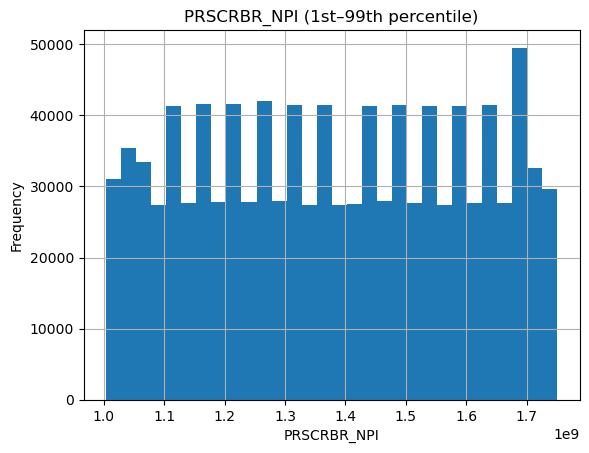

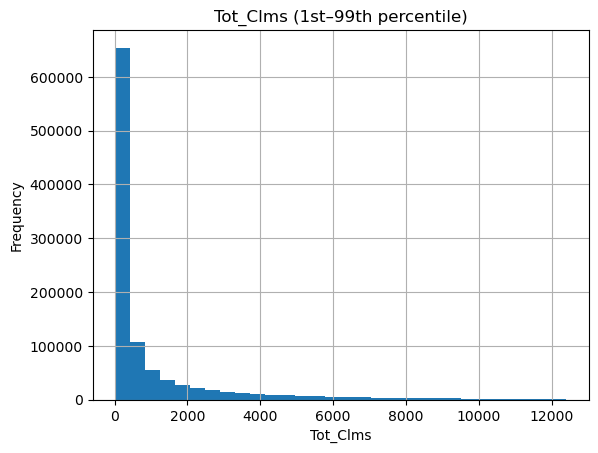

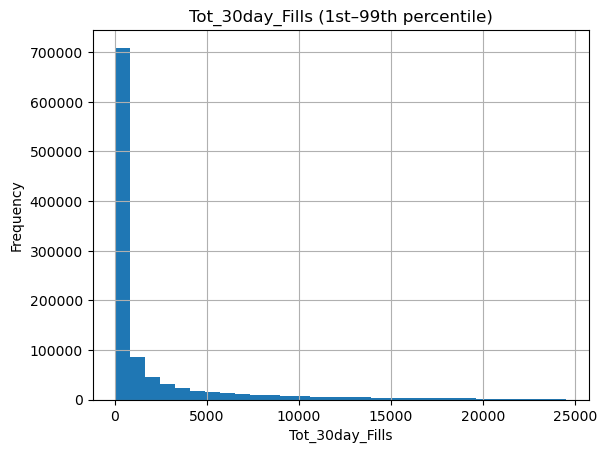

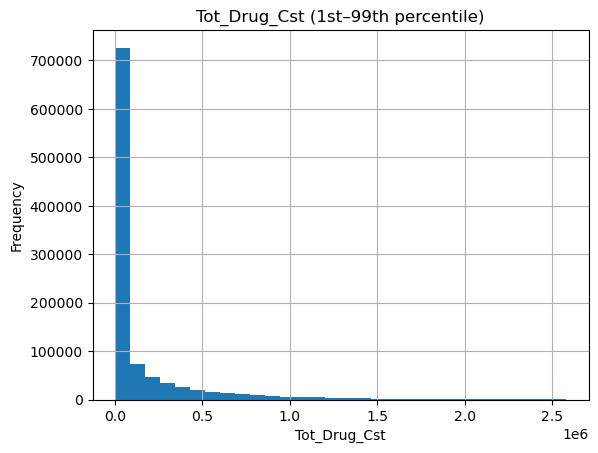

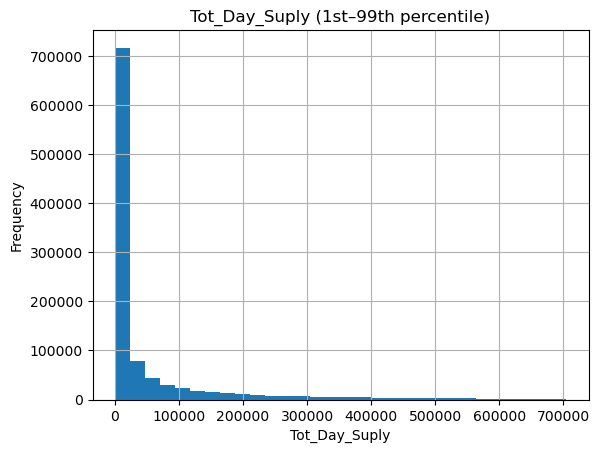

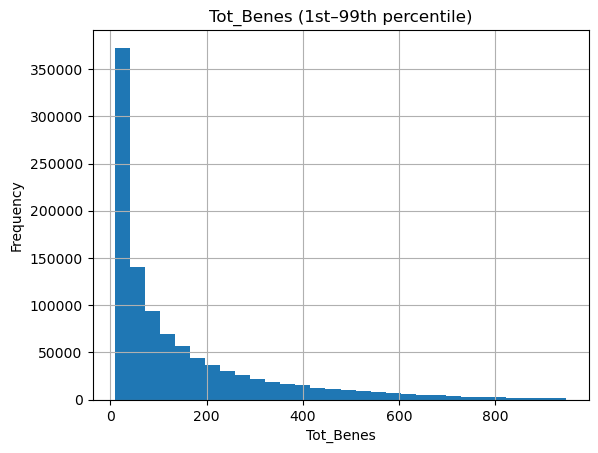

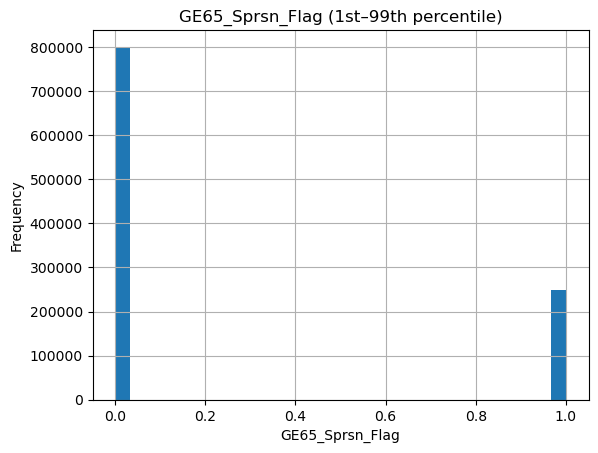

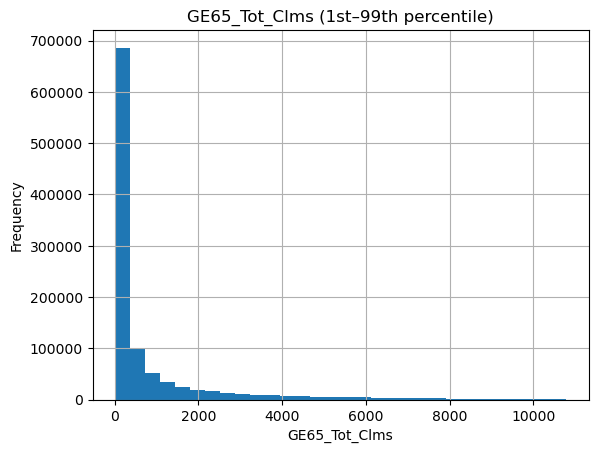

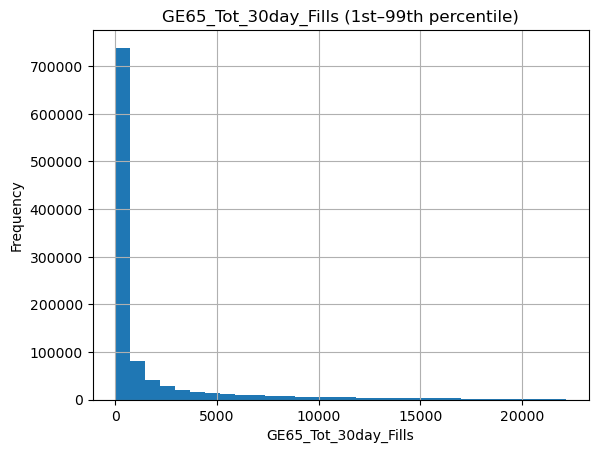

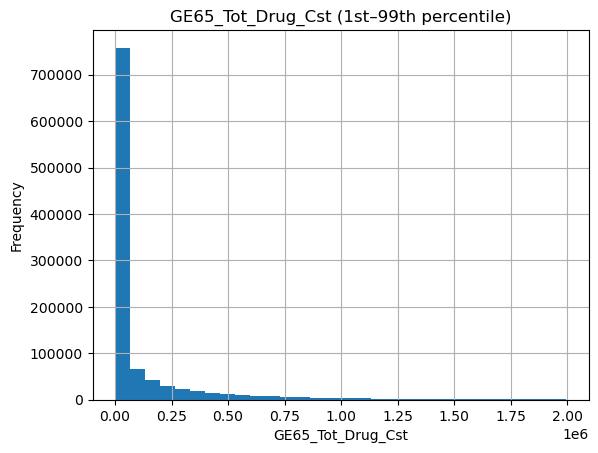

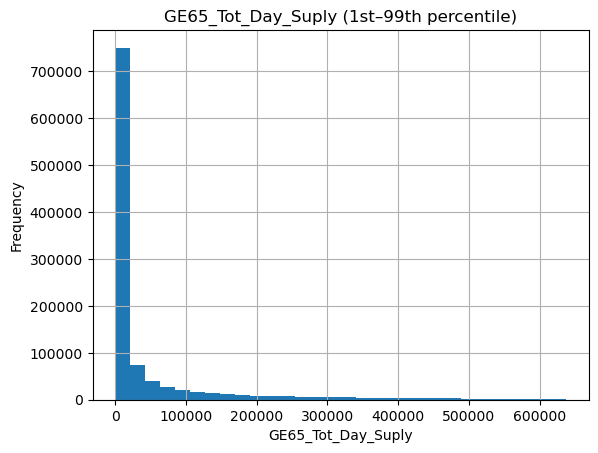

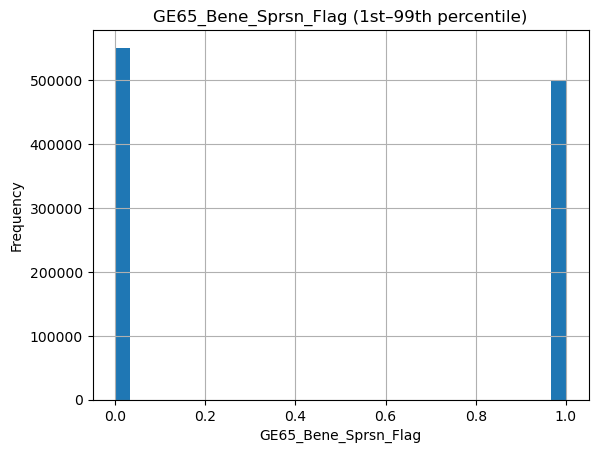

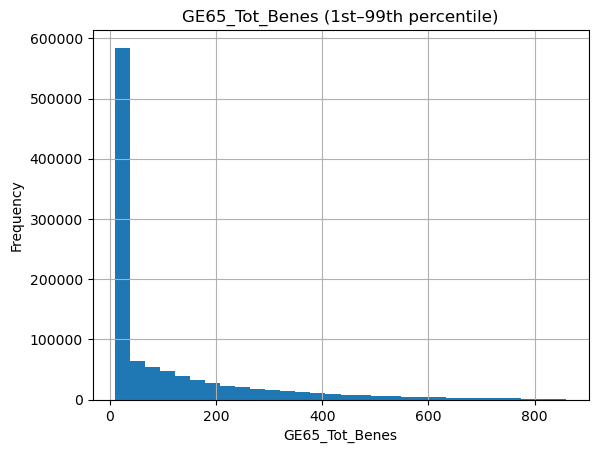

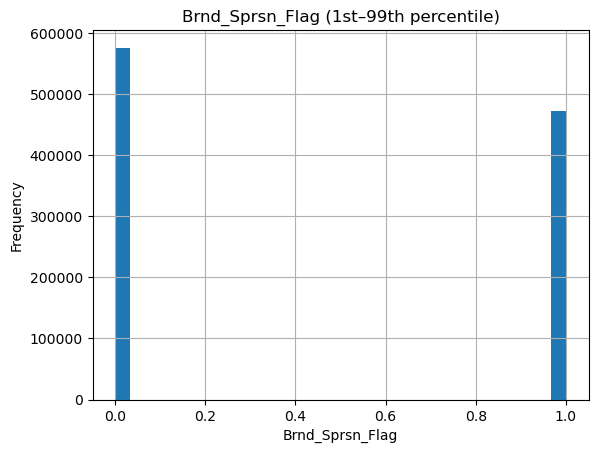

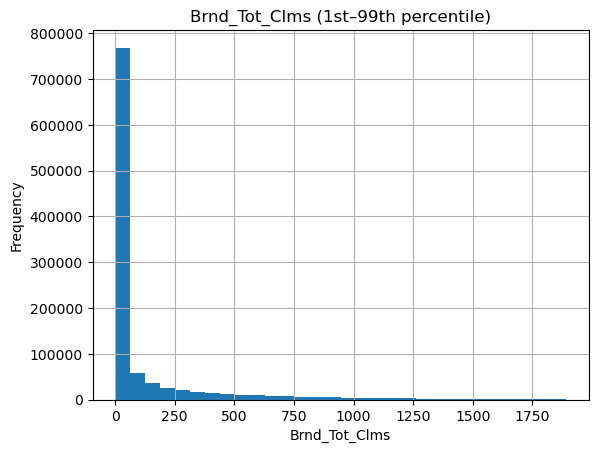

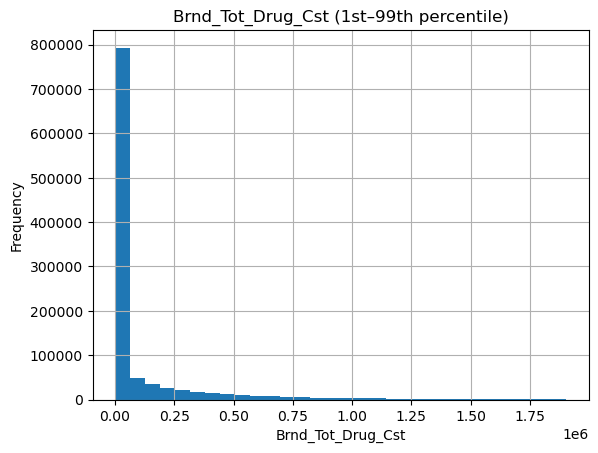

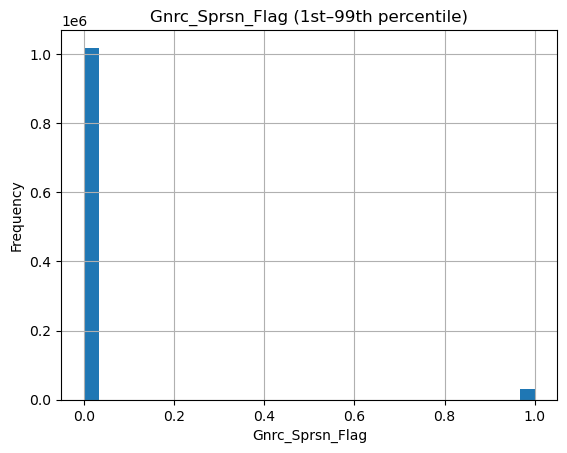

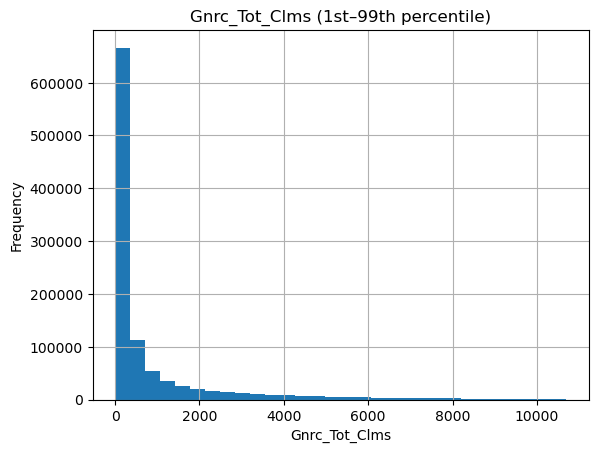

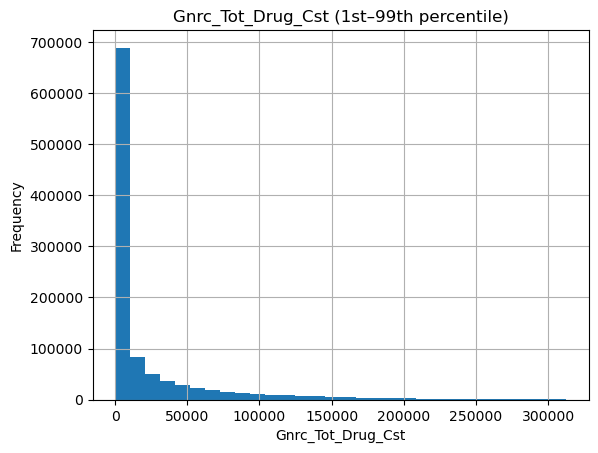

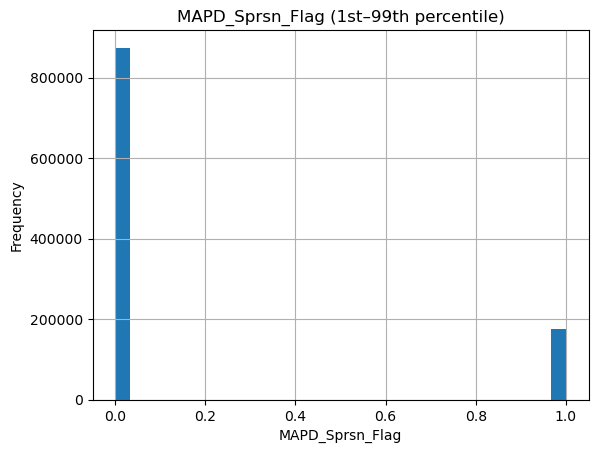

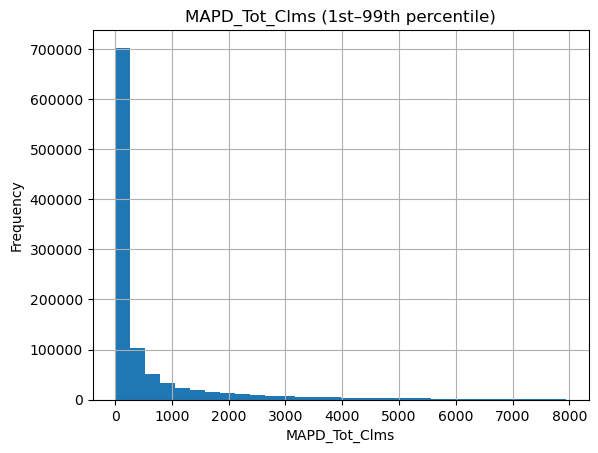

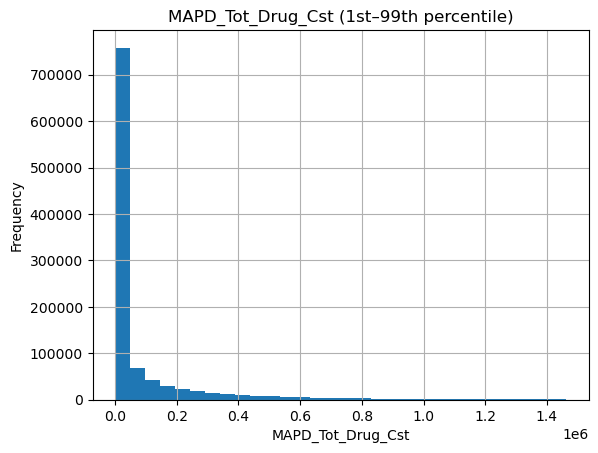

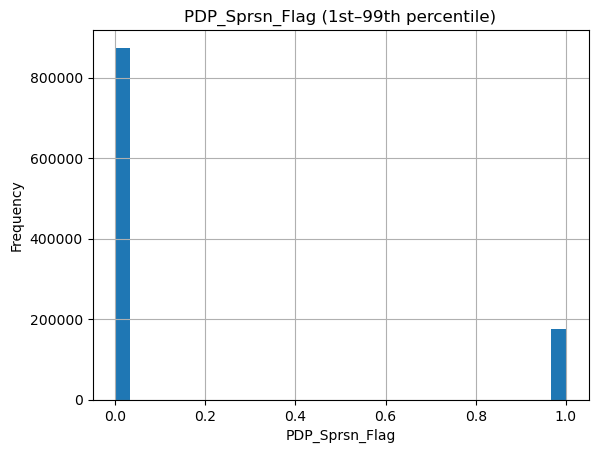

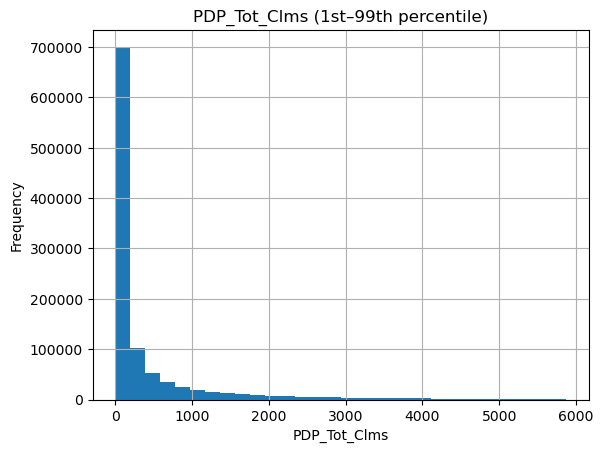

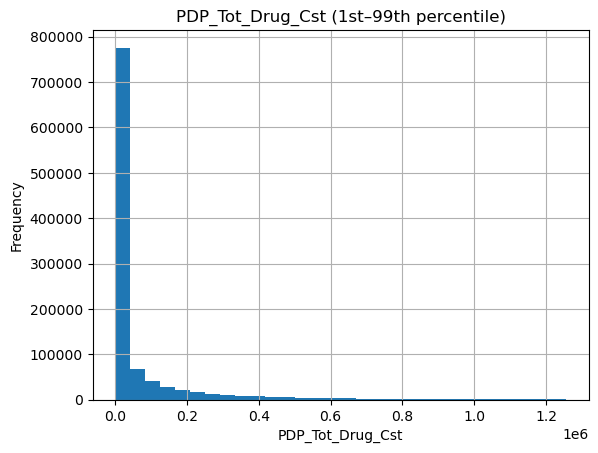

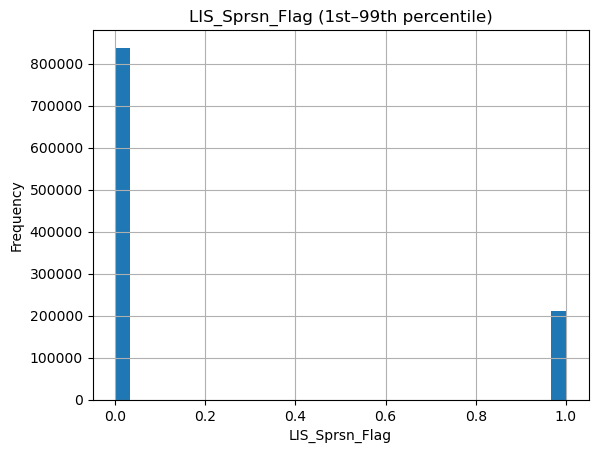

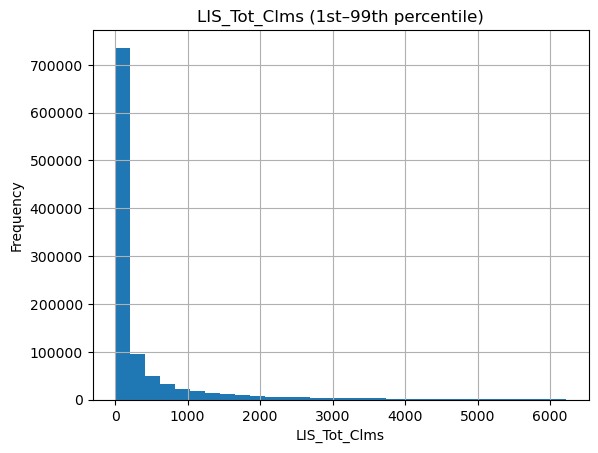

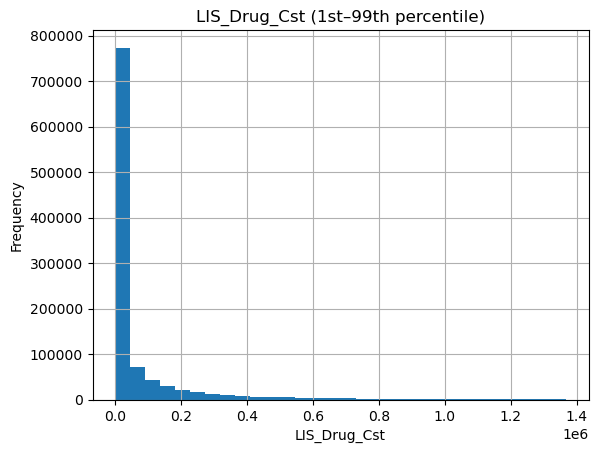

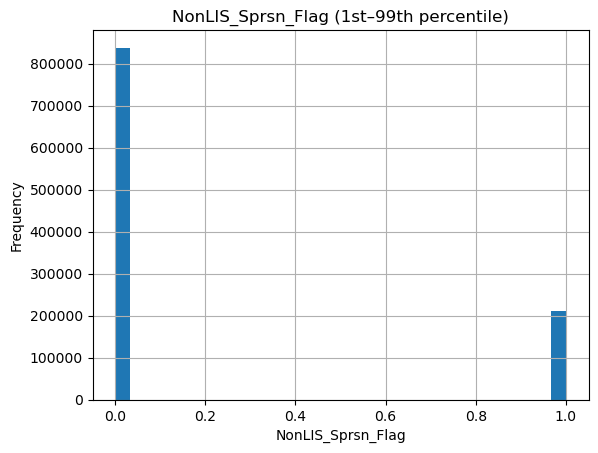

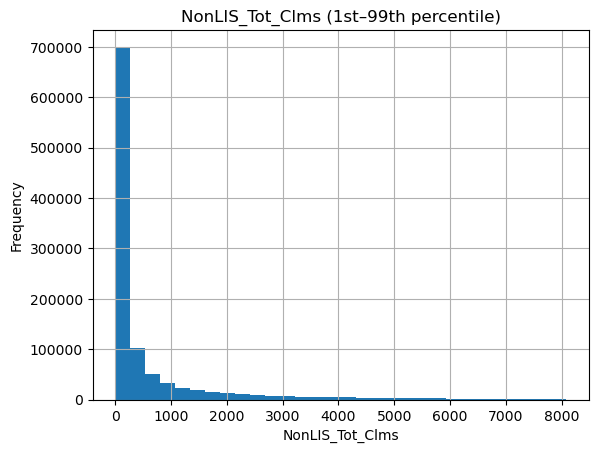

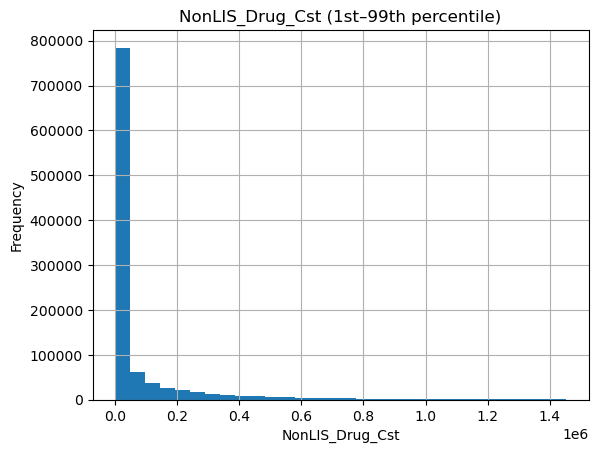

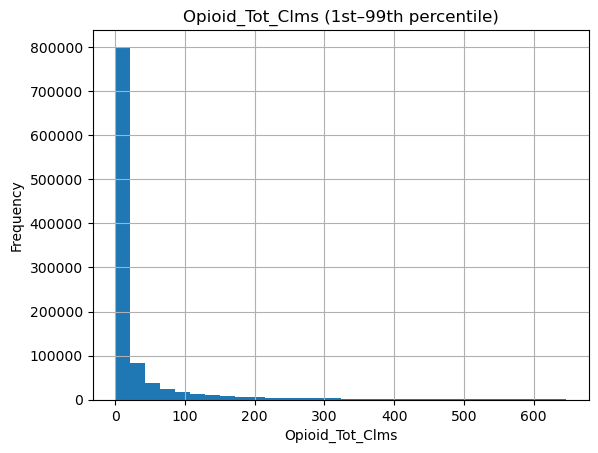

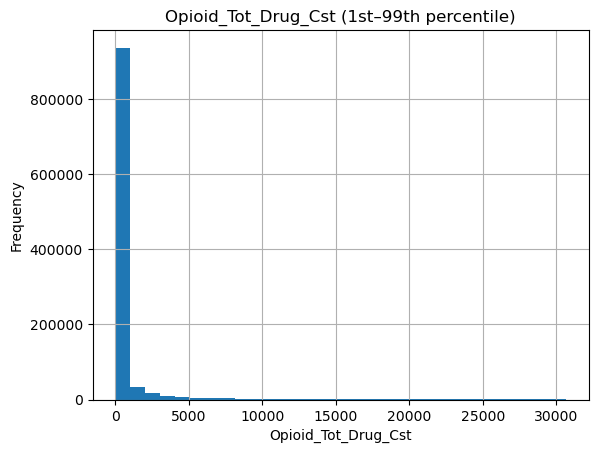

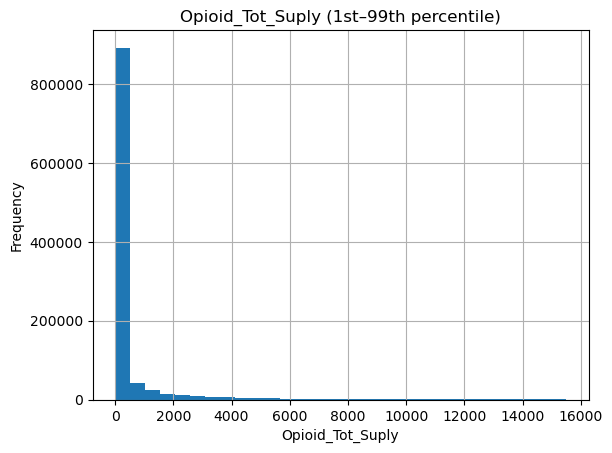

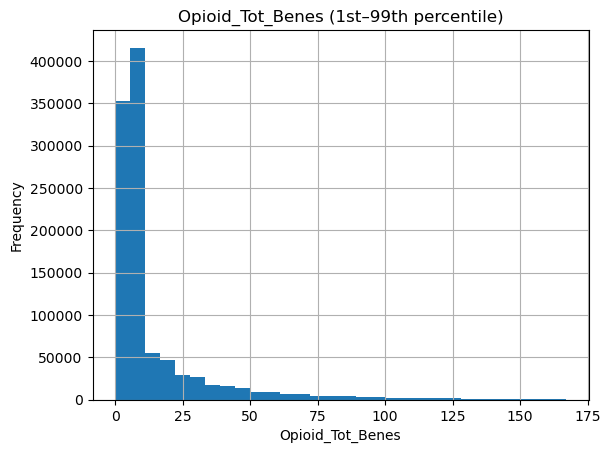

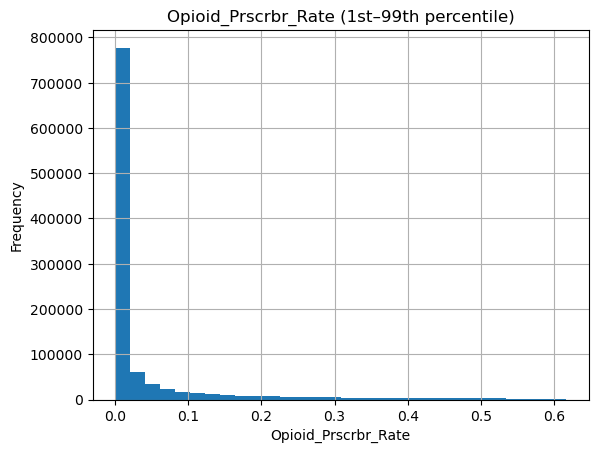

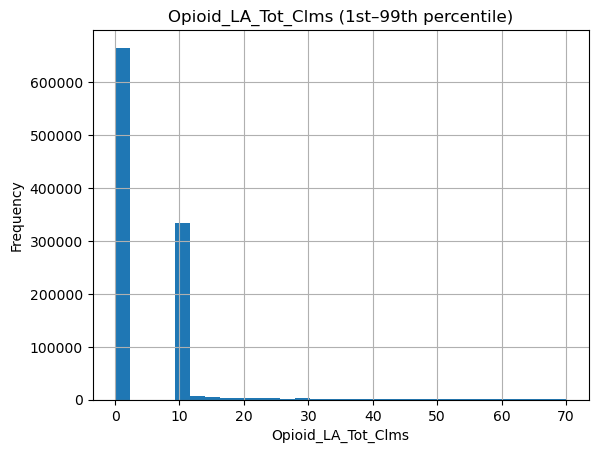

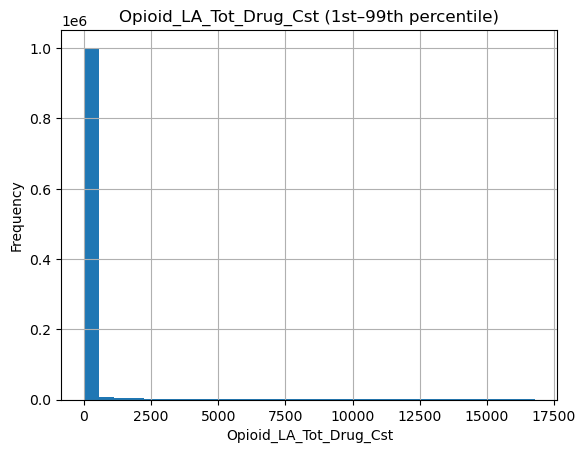

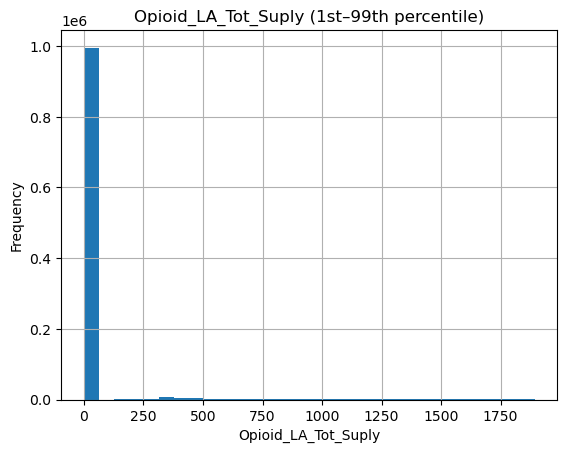

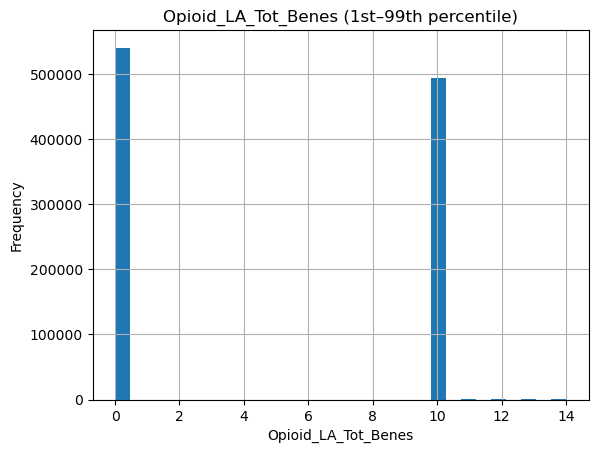

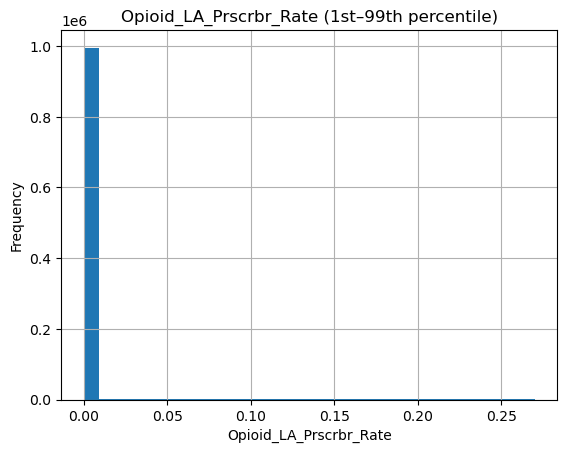

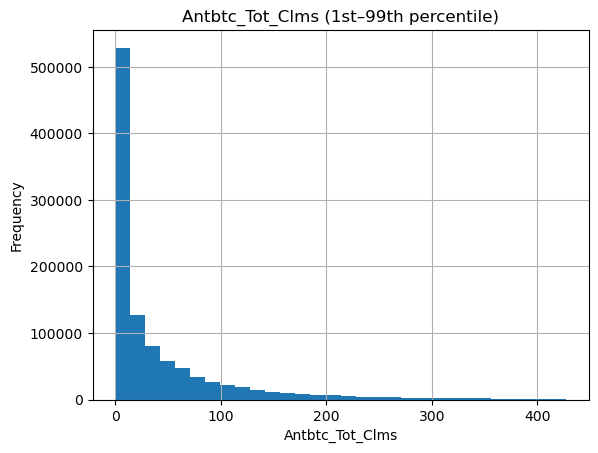

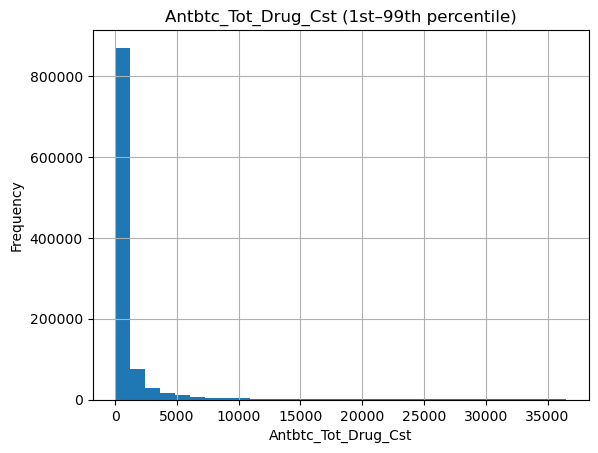

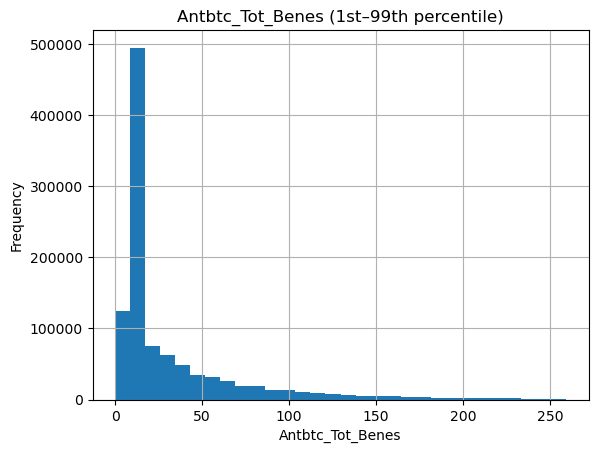

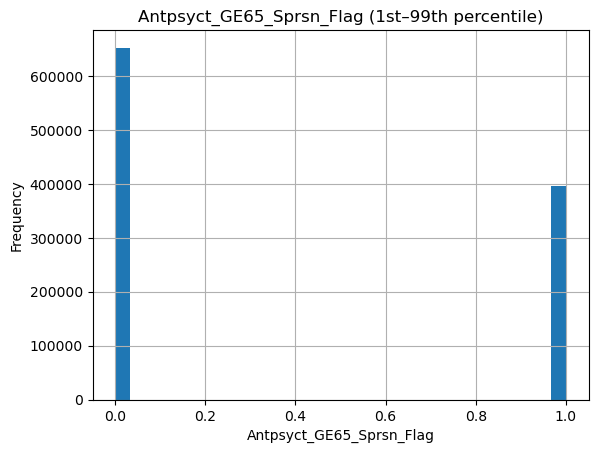

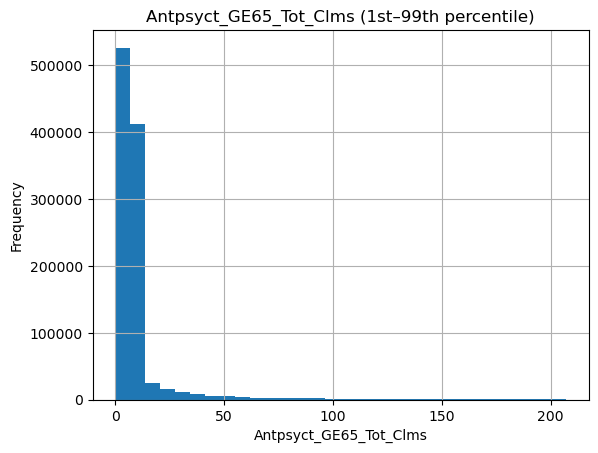

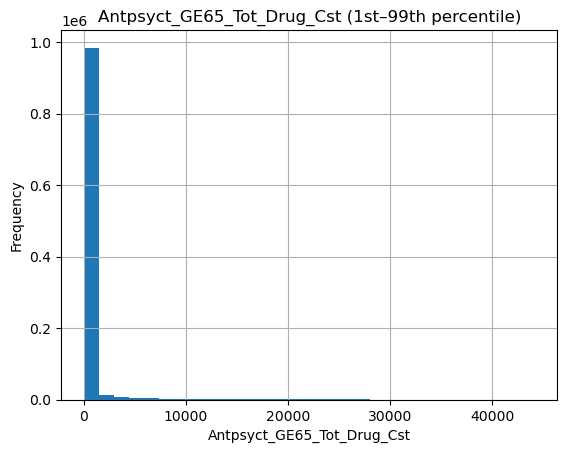

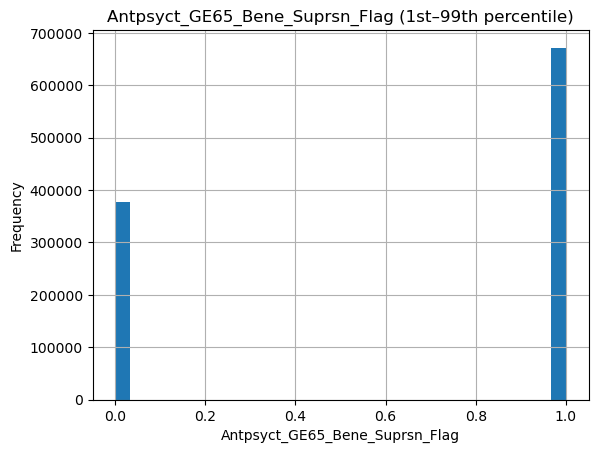

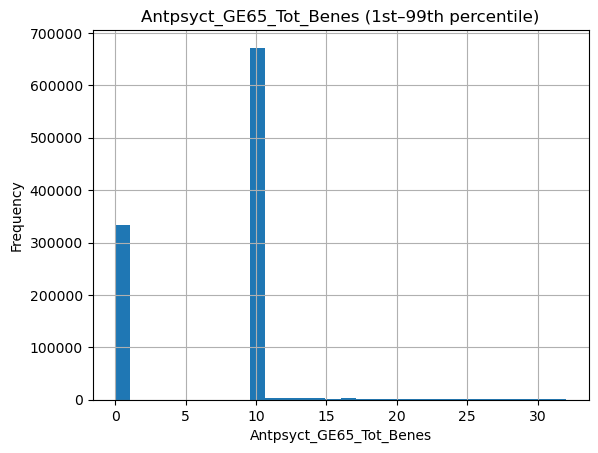

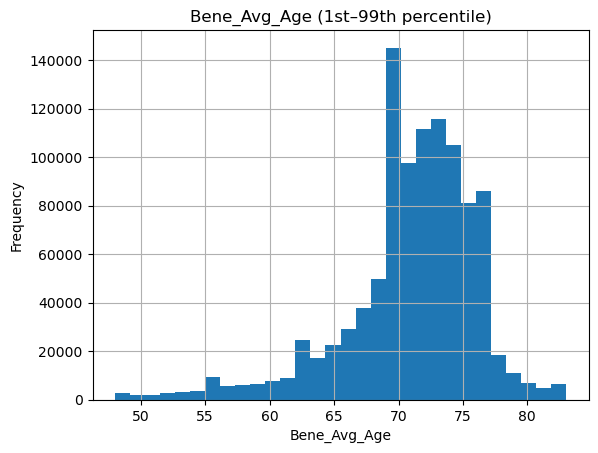

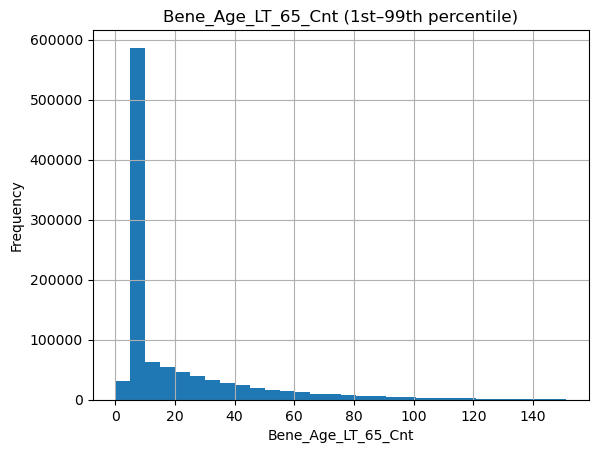

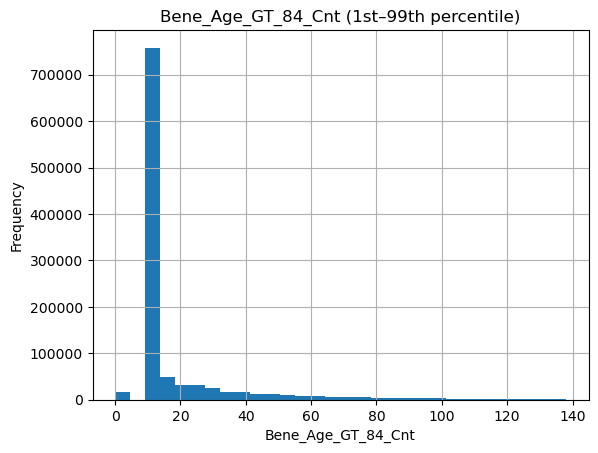

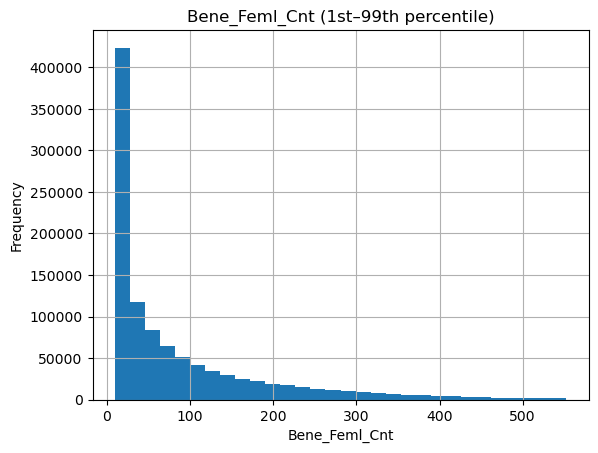

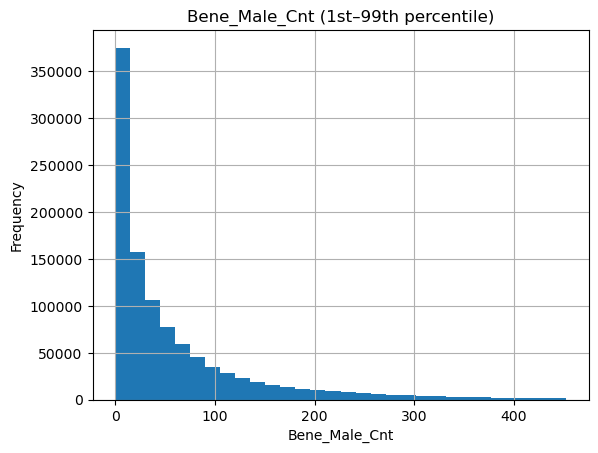

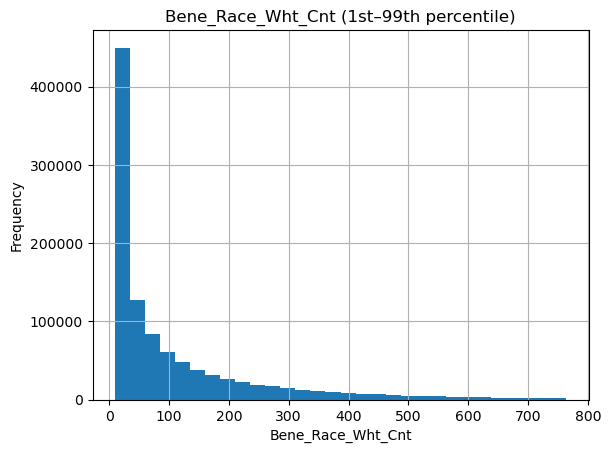

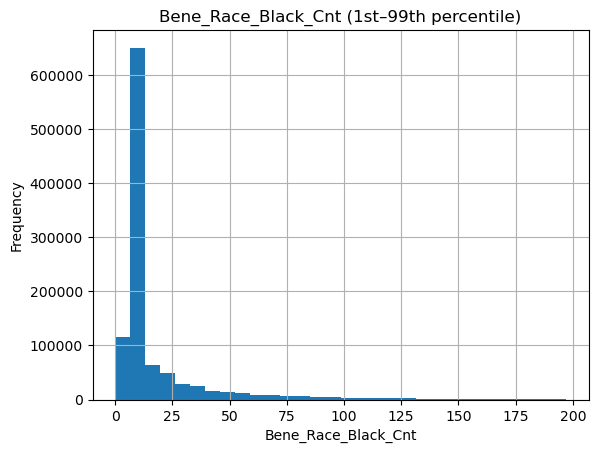

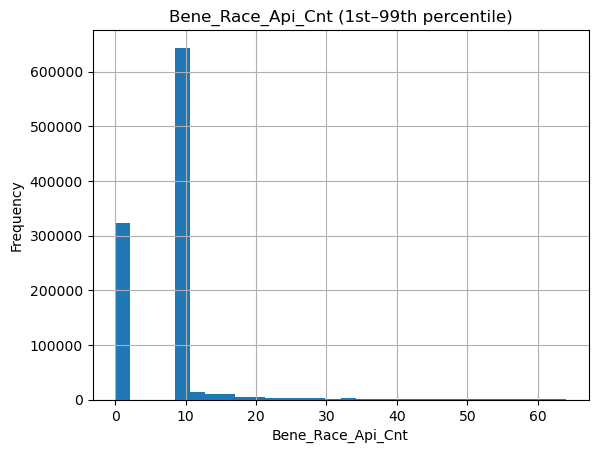

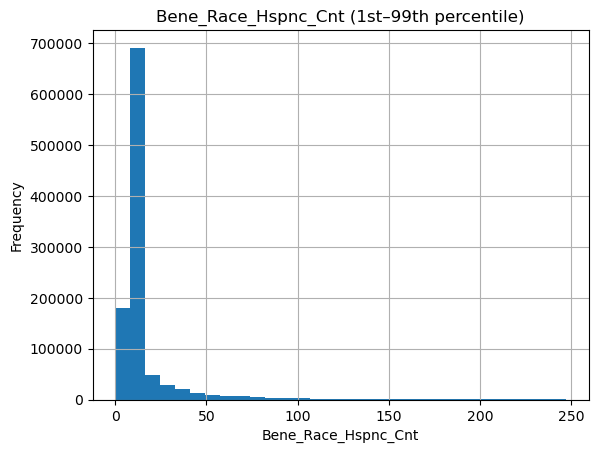

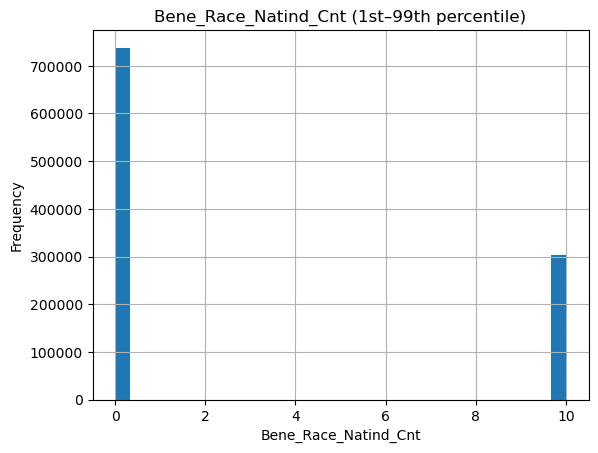

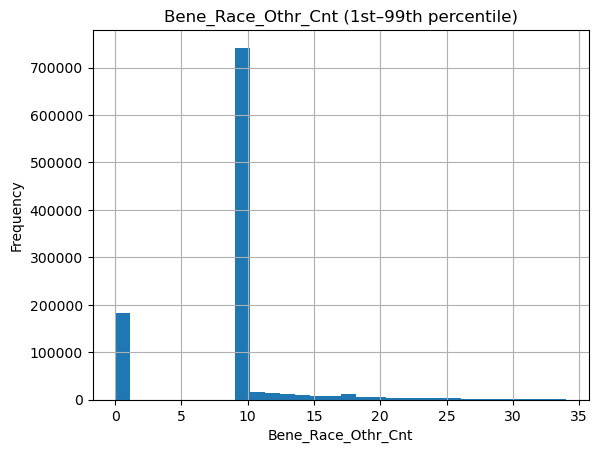

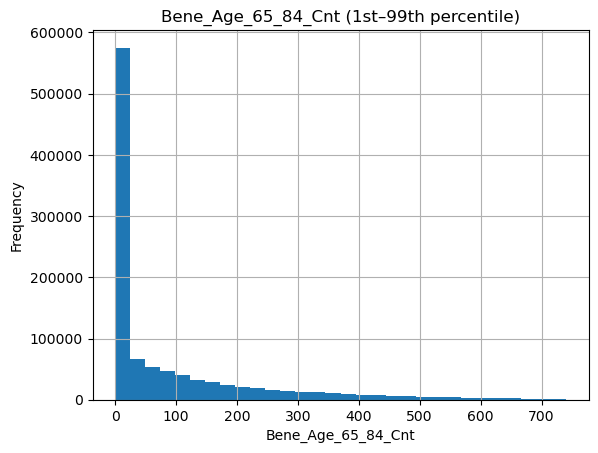

In [28]:
num_cols = df_op.select_dtypes(include='number').columns

for col in num_cols:
    lower = df_op[col].quantile(0.01)
    upper = df_op[col].quantile(0.99)
    
    df_op[col].hist(bins=30, range=(lower, upper))
    plt.title(f"{col} (1st–99th percentile)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

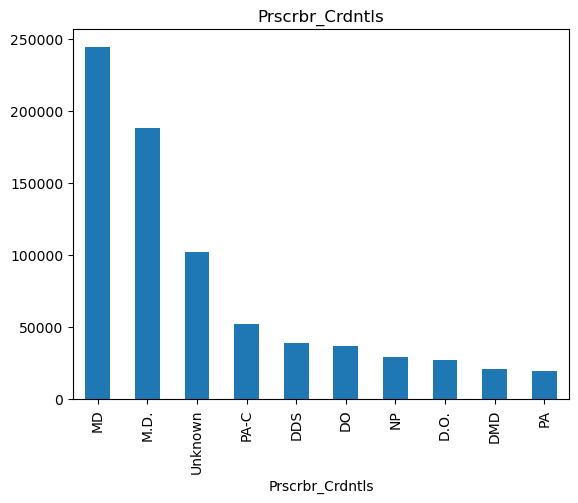

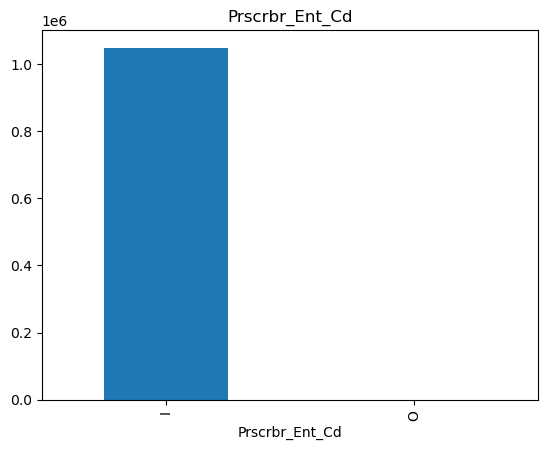

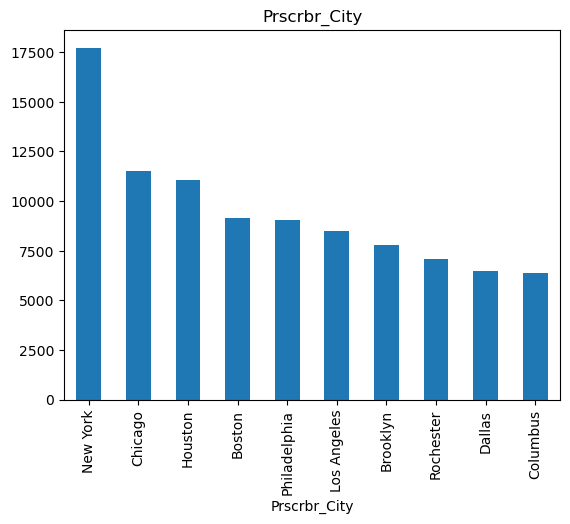

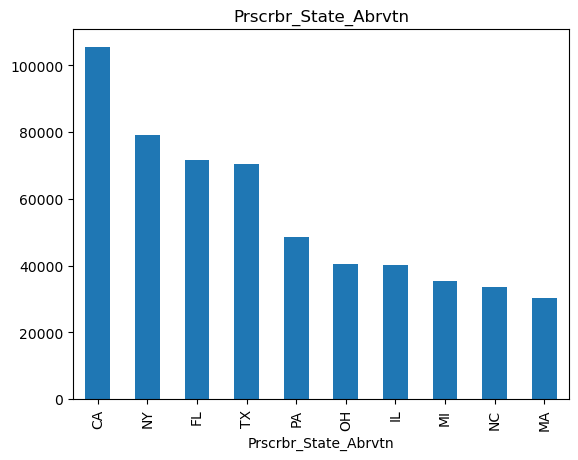

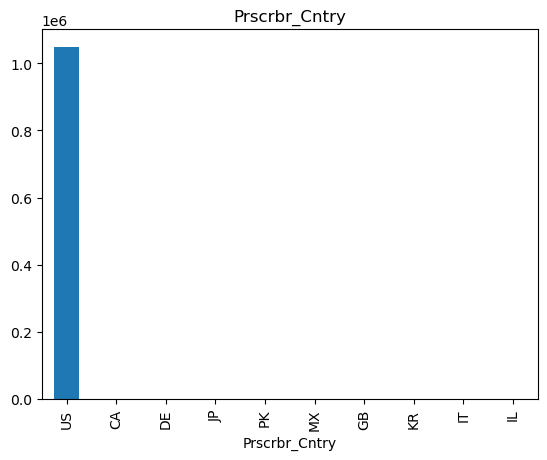

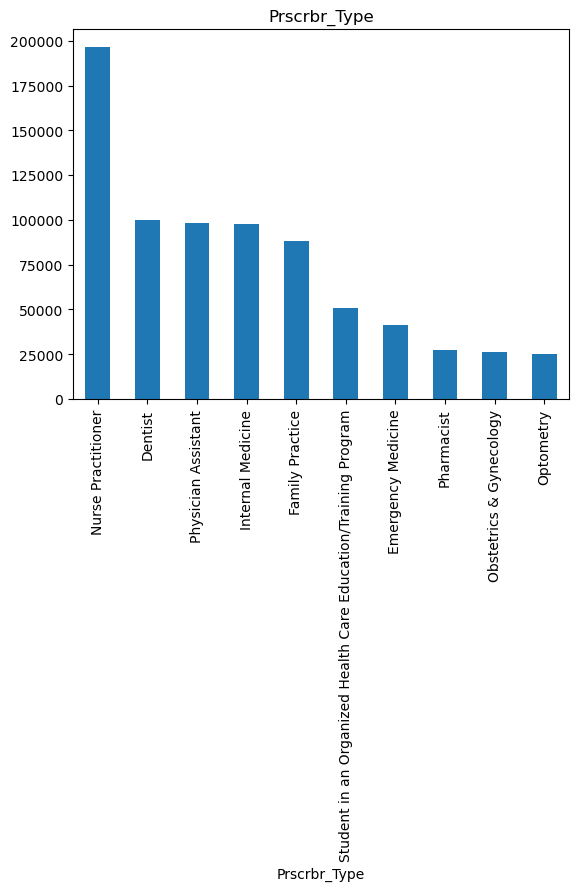

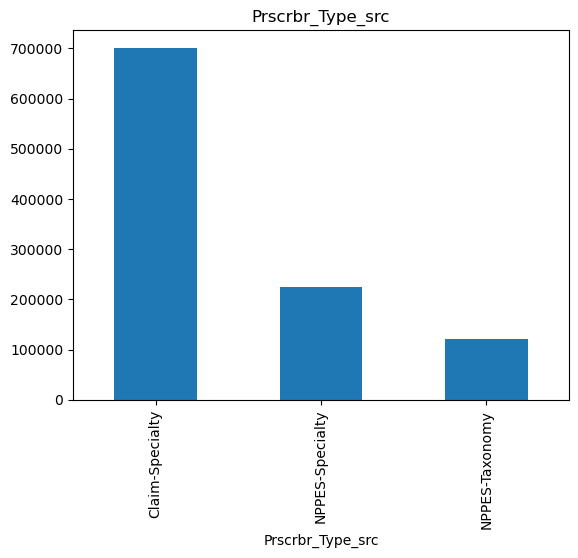

In [29]:
cat_cols = df_op.select_dtypes(include='string').columns

for col in cat_cols:
    df_op[col].value_counts().head(10).plot(kind='bar') #Change head count for more counts
    plt.title(col)
    plt.show()

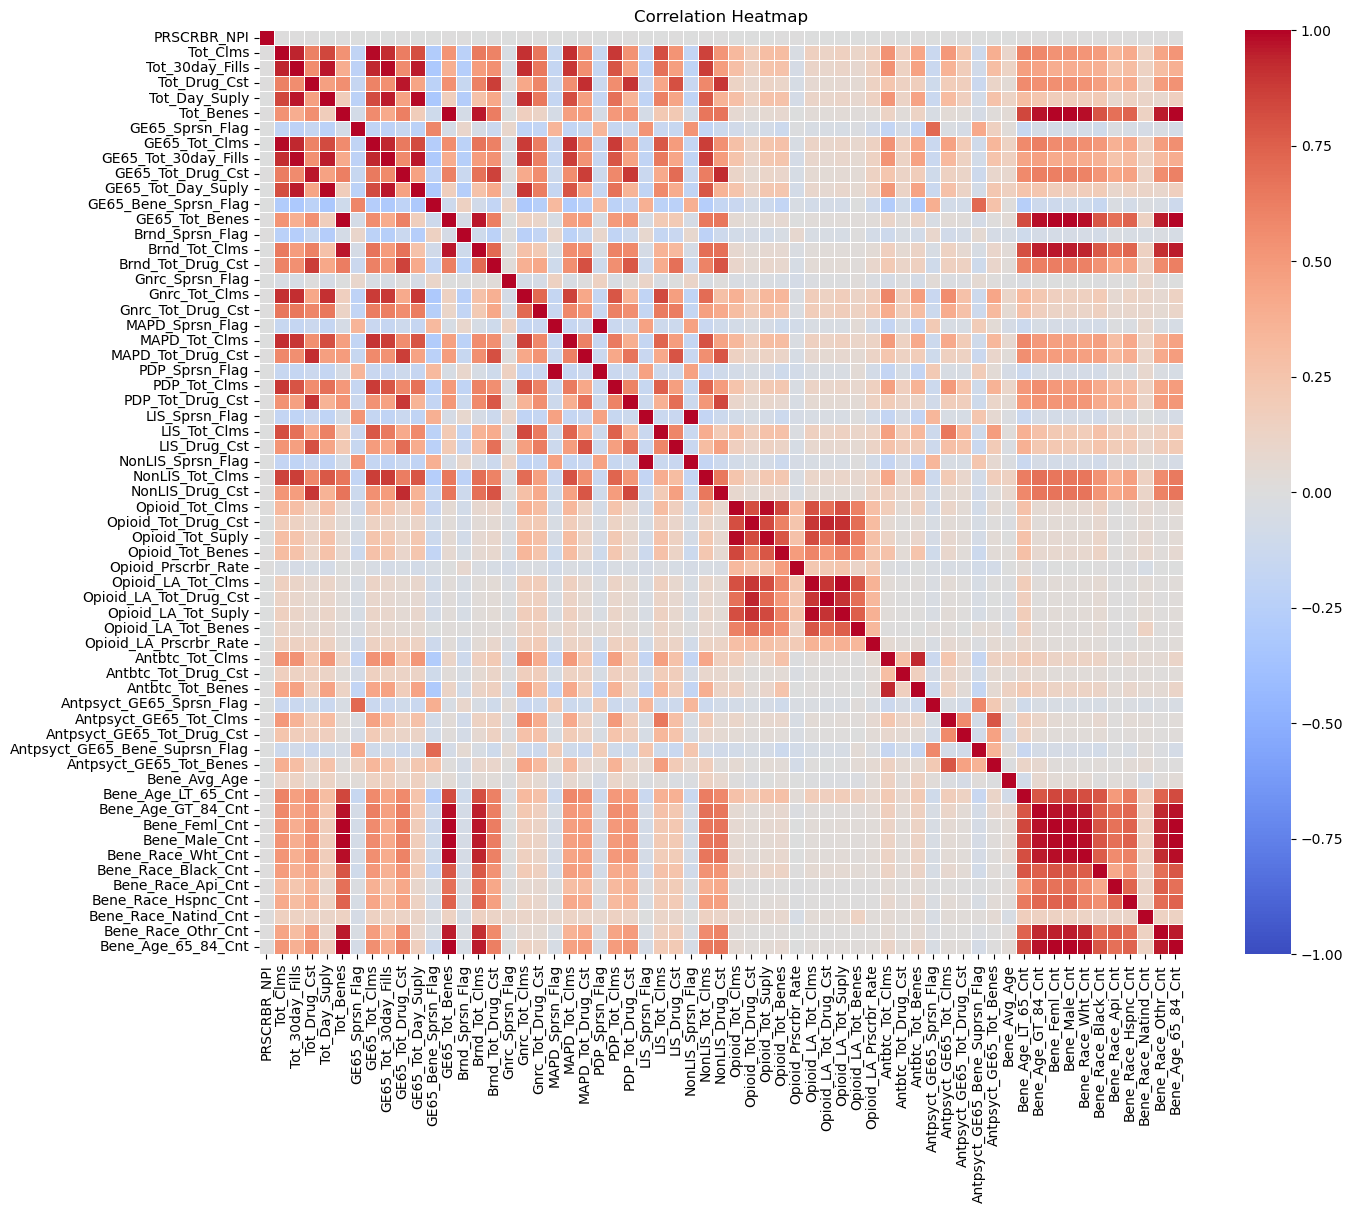

In [30]:
#I am specifying numeric columns with df_op_num.

df_op_num = df_op.select_dtypes(include = 'number')

matrix = df_op_num.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    matrix,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [31]:
#Cost per patient features

df_op['Tot_Cst_Per_Bene'] = df_op['Tot_Drug_Cst'] / df_op['Tot_Benes']

df_op['GE65_Cst_Per_Bene'] = df_op['GE65_Tot_Drug_Cst'] / df_op['GE65_Tot_Benes']

df_op['Opioid_Cst_Per_Bene'] = df_op['Opioid_Tot_Drug_Cst'] / df_op['Opioid_Tot_Benes']

df_op['Opioid_LA_Cst_Per_Bene'] = df_op['Opioid_LA_Tot_Drug_Cst'] / df_op['Opioid_LA_Tot_Benes']

df_op['Antbtc_Cst_Per_Bene'] = df_op['Antbtc_Tot_Drug_Cst'] / df_op['Antbtc_Tot_Benes']

df_op['Antpsyct_GE65_Cst_Per_Bene'] = df_op['Antpsyct_GE65_Tot_Drug_Cst'] / df_op['Antpsyct_GE65_Tot_Benes']

#Fill NA from div/0

df_op['Tot_Cst_Per_Bene'] = df_op['Tot_Cst_Per_Bene'].fillna(0)

df_op['GE65_Cst_Per_Bene'] = df_op['GE65_Cst_Per_Bene'].fillna(0)

df_op['Opioid_Cst_Per_Bene'] = df_op['Opioid_Cst_Per_Bene'].fillna(0)

df_op['Opioid_LA_Cst_Per_Bene'] = df_op['Opioid_LA_Cst_Per_Bene'].fillna(0)

df_op['Antbtc_Cst_Per_Bene'] = df_op['Antbtc_Cst_Per_Bene'].fillna(0)

df_op['Antpsyct_GE65_Cst_Per_Bene'] = df_op['Antpsyct_GE65_Cst_Per_Bene'].fillna(0)

## Data Modeling

KPrototype is the model selected because the K-means modeling is not fit for data sets with categorical features.  
KPrototype is able to integrate both numerical and categorical data.  

A resource by Aprilliant (2021) was used to generate this k-prototypes model.  

Aprilliant, A. (2021, January 17). The k-prototype as clustering algorithm for mixed data type(Categorical and numerical). Towards Data Science. https://towardsdatascience.com/the-k-prototype-as-clustering-algorithm-for-mixed-data-type-categorical-and-numerical-fe7c50538ebb/

In [32]:
from kmodes.kprototypes import KPrototypes

In [33]:
# Creating my own copy of the operational data frame (ML).
df_op_ml = df_op.copy()

In [34]:
# Normalizing the opioid and long=acting opioid numerical data.

opioid_norm = df_op_ml.copy()
opioid_norm.head()

,PRSCRBR_NPI,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_zip5,Prscrbr_RUCA,Prscrbr_Cntry,Prscrbr_Type,Prscrbr_Type_src,...,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Bene_Age_65_84_Cnt,Tot_Cst_Per_Bene,GE65_Cst_Per_Bene,Opioid_Cst_Per_Bene,Opioid_LA_Cst_Per_Bene,Antbtc_Cst_Per_Bene,Antpsyct_GE65_Cst_Per_Bene
0,1003000126,M.D.,I,Bethesda,MD,20817.0,1.0,US,Hospitalist,Claim-Specialty,...,10.0,0.0,10.0,66.0,164.285536,166.644062,3.360000,0.00000,18.763077,0.0
1,1003000142,M.D.,I,Toledo,OH,43623.0,1.0,US,Anesthesiology,Claim-Specialty,...,26.0,10.0,13.0,270.0,131.011297,124.758103,75.078631,507.78375,0.000000,0.0
2,1003000167,DDS,I,Dayton,NV,89403.0,2.0,US,Dentist,NPPES-Specialty,...,0.0,10.0,10.0,0.0,7.740169,41.364000,0.000000,0.00000,5.437755,0.0
3,1003000423,M.D.,I,Cleveland,OH,44106.0,1.0,US,Obstetrics & Gynecology,Claim-Specialty,...,10.0,0.0,10.0,0.0,298.891094,1024.624000,0.000000,0.00000,0.000000,0.0
4,1003000480,MD,I,Aurora,CO,80045.0,1.0,US,General Surgery,Claim-Specialty,...,10.0,0.0,10.0,0.0,49.068846,39.698000,2.353333,0.00000,0.000000,0.0


In [35]:
# Normalizing opioid data to overall total data.

opioid_norm['Opioid_Tot_Clms_norm'] = opioid_norm['Opioid_Tot_Clms']/opioid_norm['Tot_Clms']
opioid_norm['Opioid_Tot_Drug_Cst_norm'] = opioid_norm['Opioid_Tot_Drug_Cst']/opioid_norm['Tot_Drug_Cst']
opioid_norm['Opioid_Tot_Suply_norm'] = opioid_norm['Opioid_Tot_Suply']/opioid_norm['Tot_Day_Suply']
opioid_norm['Opioid_Tot_Benes_norm'] = opioid_norm['Opioid_Tot_Benes']/opioid_norm['Tot_Benes']
opioid_norm['Opioid_Cst_Per_Bene_norm'] = opioid_norm['Opioid_Cst_Per_Bene']/opioid_norm['Tot_Cst_Per_Bene']
opioid_norm['Opioid_LA_Tot_Clms_norm'] = opioid_norm['Opioid_LA_Tot_Clms']/opioid_norm['Tot_Clms']
opioid_norm['Opioid_LA_Tot_Drug_Cst_norm'] = opioid_norm['Opioid_LA_Tot_Drug_Cst']/opioid_norm['Tot_Drug_Cst']
opioid_norm['Opioid_LA_Tot_Suply_norm'] = opioid_norm['Opioid_LA_Tot_Suply']/opioid_norm['Tot_Day_Suply']
opioid_norm['Opioid_LA_Tot_Benes_norm'] = opioid_norm['Opioid_LA_Tot_Benes']/opioid_norm['Tot_Benes']
opioid_norm['Opioid_LA_Cst_Per_Bene_norm'] = opioid_norm['Opioid_LA_Cst_Per_Bene']/opioid_norm['Tot_Cst_Per_Bene']

opioid_norm['GE65_Cst_Per_Bene_norm'] = opioid_norm['GE65_Cst_Per_Bene']/opioid_norm['Tot_Cst_Per_Bene']
opioid_norm['Antbtc_Cst_Per_Bene_norm'] = opioid_norm['Antbtc_Cst_Per_Bene']/opioid_norm['Tot_Cst_Per_Bene']
opioid_norm['Antpsyct_GE65_Cst_Per_Bene_norm'] = opioid_norm['Antpsyct_GE65_Cst_Per_Bene']/opioid_norm['Tot_Cst_Per_Bene']

pd.set_option('display.max_columns', None)
opioid_norm.head()

,PRSCRBR_NPI,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_zip5,Prscrbr_RUCA,Prscrbr_Cntry,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,GE65_Sprsn_Flag,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Bene_Sprsn_Flag,GE65_Tot_Benes,Brnd_Sprsn_Flag,Brnd_Tot_Clms,Brnd_Tot_Drug_Cst,Gnrc_Sprsn_Flag,Gnrc_Tot_Clms,Gnrc_Tot_Drug_Cst,MAPD_Sprsn_Flag,MAPD_Tot_Clms,MAPD_Tot_Drug_Cst,PDP_Sprsn_Flag,PDP_Tot_Clms,PDP_Tot_Drug_Cst,LIS_Sprsn_Flag,LIS_Tot_Clms,LIS_Drug_Cst,NonLIS_Sprsn_Flag,NonLIS_Tot_Clms,NonLIS_Drug_Cst,Opioid_Tot_Clms,Opioid_Tot_Drug_Cst,Opioid_Tot_Suply,Opioid_Tot_Benes,Opioid_Prscrbr_Rate,Opioid_LA_Tot_Clms,Opioid_LA_Tot_Drug_Cst,Opioid_LA_Tot_Suply,Opioid_LA_Tot_Benes,Opioid_LA_Prscrbr_Rate,Antbtc_Tot_Clms,Antbtc_Tot_Drug_Cst,Antbtc_Tot_Benes,Antpsyct_GE65_Sprsn_Flag,Antpsyct_GE65_Tot_Clms,Antpsyct_GE65_Tot_Drug_Cst,Antpsyct_GE65_Bene_Suprsn_Flag,Antpsyct_GE65_Tot_Benes,Bene_Avg_Age,Bene_Age_LT_65_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Bene_Age_65_84_Cnt,Tot_Cst_Per_Bene,GE65_Cst_Per_Bene,Opioid_Cst_Per_Bene,Opioid_LA_Cst_Per_Bene,Antbtc_Cst_Per_Bene,Antpsyct_GE65_Cst_Per_Bene,Opioid_Tot_Clms_norm,Opioid_Tot_Drug_Cst_norm,Opioid_Tot_Suply_norm,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Clms_norm,Opioid_LA_Tot_Drug_Cst_norm,Opioid_LA_Tot_Suply_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,GE65_Cst_Per_Bene_norm,Antbtc_Cst_Per_Bene_norm,Antpsyct_GE65_Cst_Per_Bene_norm
0,1003000126,M.D.,I,Bethesda,MD,20817.0,1.0,US,Hospitalist,Claim-Specialty,222,254.5,18399.98,5475,112.0,0,192.0,220.5,15997.83,4769.0,0,96.0,1,10.0,0.00,0,189.0,3170.22,0,91.0,9238.20,0,131.0,9161.78,0,66.0,7243.45,0,156.0,11156.53,13.0,43.68,77.0,13.0,0.059,0.0,0.00,0.0,0.0,0.000,42.0,731.76,39.0,1,10.0,0.0,1,10.0,76,16.0,30.0,64.0,48.0,73.0,17.0,11.0,10.0,0.0,10.0,66.0,164.285536,166.644062,3.360000,0.00000,18.763077,0.0,0.058559,0.002374,0.014064,0.116071,0.020452,0.000000,0.000000,0.000000,0.000000,0.000000,1.014356,0.114210,0.0
1,1003000142,M.D.,I,Toledo,OH,43623.0,1.0,US,Anesthesiology,Claim-Specialty,1865,1999.5,62623.40,55983,478.0,0,1017.0,1081.0,36179.85,29714.0,0,290.0,0,55.0,19957.16,0,1810.0,42666.24,0,1314.0,44891.82,0,551.0,17731.58,0,1398.0,50702.42,0,467.0,11920.98,850.0,26878.15,23387.0,358.0,0.456,65.0,12186.81,1903.0,24.0,0.076,10.0,0.00,10.0,0,0.0,0.0,0,0.0,67,188.0,20.0,311.0,167.0,226.0,212.0,10.0,26.0,10.0,13.0,270.0,131.011297,124.758103,75.078631,507.78375,0.000000,0.0,0.455764,0.429203,0.417752,0.748954,0.573070,0.034853,0.194605,0.033992,0.050209,3.875878,0.952270,0.000000,0.0
2,1003000167,DDS,I,Dayton,NV,89403.0,2.0,US,Dentist,NPPES-Specialty,118,119.0,456.67,806,59.0,0,105.0,106.0,413.64,703.0,1,10.0,1,10.0,0.00,0,108.0,383.19,0,46.0,156.89,0,72.0,299.78,0,13.0,31.52,0,105.0,425.15,10.0,0.00,0.0,10.0,0.000,10.0,0.00,0.0,10.0,0.000,60.0,266.45,49.0,0,0.0,0.0,1,10.0,72,10.0,10.0,31.0,28.0,54.0,0.0,0.0,0.0,10.0,10.0,0.0,7.740169,41.364000,0.000000,0.00000,5.437755,0.0,0.084746,0.000000,0.000000,0.169492,0.000000,0.084746,0.000000,0.000000,0.169492,0.000000,5.344069,0.702537,0.0
3,1003000423,M.D.,I,Cleveland,OH,44106.0,1.0,US,Obstetrics & Gynecology,Claim-Specialty,162,340.0,19129.03,9260,64.0,0,134.0,274.3,10246.24,7351.0,1,10.0,0,17.0,10459.97,0,145.0,8669.06,0,72.0,12396.49,0,90.0,6732.54,0,31.0,8946.64,0,131.0,10182.39,0.0,0.00,0.0,0.0,0.000,0.0,0.00,0.0,0.0,0.000,10.0,0.00,10.0,0,0.0,0.0,1,10.0,70,10.0,10.0,10.0,10.0,59.0,10.0,10.0,10.0,0.0,10.0,0.0,298.891094,1024.624000,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.428085,0.000000,0.0
4,1003000480,MD,I,Aurora,CO,80045.0,1.0,US,General Surgery,Claim-Specialty,41,47.1,1275.79,851,26.0,0,20.0,25.0,396.98,329.0,1,10.0,0,0.0,0.00,0,41.0,1275.79,0,24.

In [37]:
# Check for null values per column. I got an error when trying to run Kprototypes (ML).
print(df_op_ml.isnull().sum())

PRSCRBR_NPI                       0
Prscrbr_Crdntls                   0
Prscrbr_Ent_Cd                    0
Prscrbr_City                      0
Prscrbr_State_Abrvtn              0
Prscrbr_zip5                      0
Prscrbr_RUCA                      0
Prscrbr_Cntry                     0
Prscrbr_Type                      0
Prscrbr_Type_src                  0
Tot_Clms                          0
Tot_30day_Fills                   0
Tot_Drug_Cst                      0
Tot_Day_Suply                     0
Tot_Benes                         0
GE65_Sprsn_Flag                   0
GE65_Tot_Clms                     0
GE65_Tot_30day_Fills              0
GE65_Tot_Drug_Cst                 0
GE65_Tot_Day_Suply                0
GE65_Bene_Sprsn_Flag              0
GE65_Tot_Benes                    0
Brnd_Sprsn_Flag                   0
Brnd_Tot_Clms                     0
Brnd_Tot_Drug_Cst                 0
Gnrc_Sprsn_Flag                   0
Gnrc_Tot_Clms                     0
Gnrc_Tot_Drug_Cst           

In [38]:
# Check for null values per column. I got an error when trying to run Kprototypes (ML).
print(opioid_norm.isnull().sum())

PRSCRBR_NPI                         0
Prscrbr_Crdntls                     0
Prscrbr_Ent_Cd                      0
Prscrbr_City                        0
Prscrbr_State_Abrvtn                0
Prscrbr_zip5                        0
Prscrbr_RUCA                        0
Prscrbr_Cntry                       0
Prscrbr_Type                        0
Prscrbr_Type_src                    0
Tot_Clms                            0
Tot_30day_Fills                     0
Tot_Drug_Cst                        0
Tot_Day_Suply                       0
Tot_Benes                           0
GE65_Sprsn_Flag                     0
GE65_Tot_Clms                       0
GE65_Tot_30day_Fills                0
GE65_Tot_Drug_Cst                   0
GE65_Tot_Day_Suply                  0
GE65_Bene_Sprsn_Flag                0
GE65_Tot_Benes                      0
Brnd_Sprsn_Flag                     0
Brnd_Tot_Clms                       0
Brnd_Tot_Drug_Cst                   0
Gnrc_Sprsn_Flag                     0
Gnrc_Tot_Clm

In [39]:
# Rows that have at least one NaN (ML).

pd.set_option('display.max_columns', None)
nan_rows = opioid_norm[opioid_norm.isnull().any(axis=1)]
print(nan_rows)

        PRSCRBR_NPI  Prscrbr_Crdntls Prscrbr_Ent_Cd    Prscrbr_City  \
67214    1043870702  MSN, APRN, NP-C              I  Salt Lake City   
72543    1053377127               MD              I         Memphis   
101667   1073519666             M.D.              I       Allentown   
134819   1093815599      ARNP, CWOCN              I       Lake City   
144199   1104402080               MD              I         Atlanta   
158677   1114422334          Unknown              I       Northport   
182055   1134198534             M.D.              I       Salisbury   
223011   1164175030             CRNP              I      Pittsburgh   
231066   1164781282          Unknown              I       Las Vegas   
294236   1215251152             M.D.              I        Woodside   
490722   1356507891             O.D.              I      Trussville   
663771   1477991420             M.D.              I        Richmond   
718070   1518953017               MD              I       Louisburg   
740566

In [40]:
# Replace NaN in prdemo with zero, because, upon inspection, the total, opioid, and long-acting opioid drug costs were all zero (ML).

opioid_norm['Opioid_Tot_Drug_Cst_norm'] = opioid_norm['Opioid_Tot_Drug_Cst_norm'].fillna(0)
opioid_norm['Opioid_LA_Tot_Drug_Cst_norm'] = opioid_norm['Opioid_LA_Tot_Drug_Cst_norm'].fillna(0)
opioid_norm['Opioid_Cst_Per_Bene_norm'] = opioid_norm['Opioid_Cst_Per_Bene_norm'].fillna(0)
opioid_norm['Opioid_LA_Cst_Per_Bene_norm'] = opioid_norm['Opioid_LA_Cst_Per_Bene_norm'].fillna(0)
opioid_norm['GE65_Cst_Per_Bene_norm'] = opioid_norm['GE65_Cst_Per_Bene_norm'].fillna(0)
opioid_norm['Antbtc_Cst_Per_Bene_norm'] = opioid_norm['Antbtc_Cst_Per_Bene_norm'].fillna(0)
opioid_norm['Antpsyct_GE65_Cst_Per_Bene_norm'] = opioid_norm['Antpsyct_GE65_Cst_Per_Bene_norm'].fillna(0)

In [41]:
# Check for null values per column. I got an error when trying to run Kprototypes (ML).
print(opioid_norm.isnull().sum())

PRSCRBR_NPI                        0
Prscrbr_Crdntls                    0
Prscrbr_Ent_Cd                     0
Prscrbr_City                       0
Prscrbr_State_Abrvtn               0
Prscrbr_zip5                       0
Prscrbr_RUCA                       0
Prscrbr_Cntry                      0
Prscrbr_Type                       0
Prscrbr_Type_src                   0
Tot_Clms                           0
Tot_30day_Fills                    0
Tot_Drug_Cst                       0
Tot_Day_Suply                      0
Tot_Benes                          0
GE65_Sprsn_Flag                    0
GE65_Tot_Clms                      0
GE65_Tot_30day_Fills               0
GE65_Tot_Drug_Cst                  0
GE65_Tot_Day_Suply                 0
GE65_Bene_Sprsn_Flag               0
GE65_Tot_Benes                     0
Brnd_Sprsn_Flag                    0
Brnd_Tot_Clms                      0
Brnd_Tot_Drug_Cst                  0
Gnrc_Sprsn_Flag                    0
Gnrc_Tot_Clms                      0
G

In [42]:
# Preparing for a Principal Component Reduction to focus the analysis on fewer opioid-related features.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_opioid = opioid_norm[['Opioid_Prscrbr_Rate', 'Opioid_Tot_Clms_norm', 'Opioid_Tot_Drug_Cst_norm', 'Opioid_Tot_Suply_norm', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm']]
opioid_corr = X_opioid.corr()

opioid_corr

,Opioid_Prscrbr_Rate,Opioid_Tot_Clms_norm,Opioid_Tot_Drug_Cst_norm,Opioid_Tot_Suply_norm,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm
Opioid_Prscrbr_Rate,1.000000,0.680405,0.820201,0.905568,0.332568,0.637364
Opioid_Tot_Clms_norm,0.680405,1.000000,0.571181,0.629080,0.530696,0.412446
Opioid_Tot_Drug_Cst_norm,0.820201,0.571181,1.000000,0.897116,0.280130,0.806715
Opioid_Tot_Suply_norm,0.905568,0.629080,0.897116,1.000000,0.306366,0.663658
Opioid_Tot_Benes_norm,0.332568,0.530696,0.280130,0.306366,1.000000,0.155750
Opioid_Cst_Per_Bene_norm,0.637364,0.412446,0.806715,0.663658,0.155750,1.000000


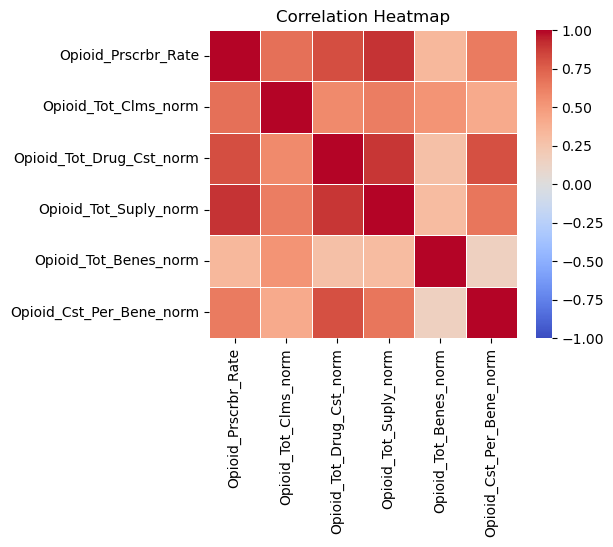

In [43]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    opioid_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [44]:
# Running the Principal Component Reduction on the opioid data.

opioid_pca = PCA(n_components = 6)
opioid_pca_c = opioid_pca.fit_transform(X_opioid)

In [45]:
# Looking at the variability explained by each component in X_opioid.

opioid_pca.explained_variance_ratio_
opioid_ex_vratio = np.cumsum(opioid_pca.explained_variance_ratio_)
opioid_ex_vratio

array([0.62742642, 0.89173021, 0.96136191, 0.98999128, 0.99771446,
       1.        ])

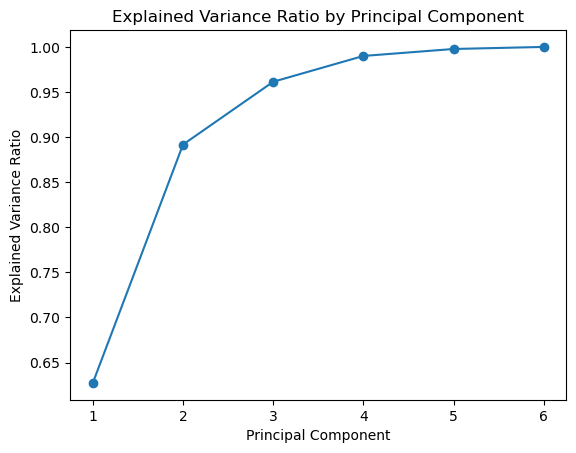

In [46]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(opioid_ex_vratio) + 1)
y = opioid_ex_vratio
# plot
ax.plot(x, y, marker='o')
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [49]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

opioid_comps = opioid_pca.components_

opioid_comps_df = pd.DataFrame(
    opioid_comps,
    columns=X_opioid.columns,
    index=[f'PC{i+1}' for i in range(opioid_comps.shape[0])]
)

print(opioid_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     Opioid_Prscrbr_Rate  Opioid_Tot_Clms_norm  Opioid_Tot_Drug_Cst_norm  \
PC1             0.192891              0.311895                  0.141011   
PC2             0.346490              0.234103                  0.318073   
PC3             0.284839              0.743481                 -0.005106   
PC4             0.589739             -0.540396                  0.281880   
PC5            -0.592330              0.055632                  0.729298   
PC6            -0.250913              0.005591                 -0.517289   

     Opioid_Tot_Suply_norm  Opioid_Tot_Benes_norm  Opioid_Cst_Per_Bene_norm  
PC1               0.121973               0.886281                  0.212743  
PC2               0.238062              -0.410668                  0.706150  
PC3               0.135634              -0.209154                 -0.551303  
PC4               0.399103               0.044997                 -0.345566  
PC5               0.296709              -0.008780                 -0.161437  

In [50]:
# From the ratio plot, the top 2 variables explain 89% of the variance in the data.
# From the table above, Opioid_Tot_Benes_norm (PC1 value = 0.89, 63% of variance) and Opioid_Cst_Per_Bene_norm (PC2 value = 0.71, 89% of variance) will be those two variables.
# Should it become necessary later on in the analysis, these two varaibles can be used to represent the opioid data.

In [51]:
# Preparing for a Principal Component Reduction to focus the analysis on fewer long-acting opioid-related features.

X_opioid_LA = opioid_norm[['Opioid_LA_Prscrbr_Rate', 'Opioid_LA_Tot_Clms_norm', 'Opioid_LA_Tot_Drug_Cst_norm', 'Opioid_LA_Tot_Suply_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
opioid_LA_corr = X_opioid_LA.corr()

opioid_LA_corr

,Opioid_LA_Prscrbr_Rate,Opioid_LA_Tot_Clms_norm,Opioid_LA_Tot_Drug_Cst_norm,Opioid_LA_Tot_Suply_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
Opioid_LA_Prscrbr_Rate,1.000000,0.017376,0.528003,0.600488,-0.030402,0.428736
Opioid_LA_Tot_Clms_norm,0.017376,1.000000,0.071085,0.085049,0.458088,0.020647
Opioid_LA_Tot_Drug_Cst_norm,0.528003,0.071085,1.000000,0.866446,0.015194,0.713949
Opioid_LA_Tot_Suply_norm,0.600488,0.085049,0.866446,1.000000,0.024746,0.488524
Opioid_LA_Tot_Benes_norm,-0.030402,0.458088,0.015194,0.024746,1.000000,-0.026588
Opioid_LA_Cst_Per_Bene_norm,0.428736,0.020647,0.713949,0.488524,-0.026588,1.000000


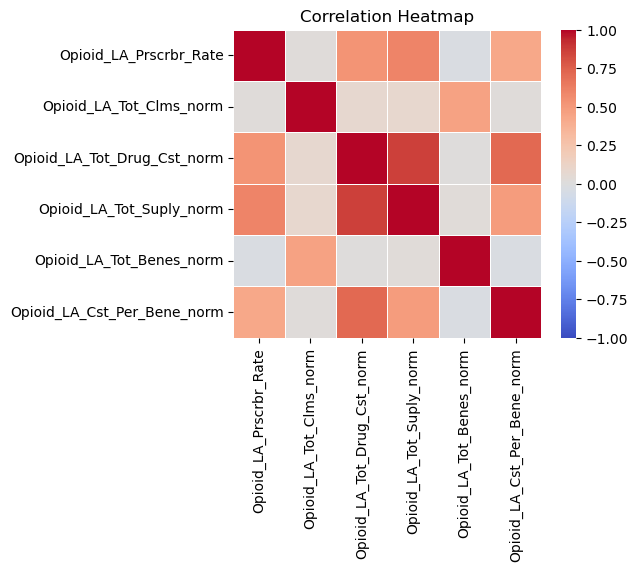

In [52]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    opioid_LA_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [53]:
# Running the Principal Component Reduction on the opioid data.

opioid_LA_pca = PCA(n_components = 6)
opioid_LA_pca_c = opioid_LA_pca.fit_transform(X_opioid_LA)

In [54]:
# Looking at the variability explained by each component in X_opioid.

opioid_LA_pca.explained_variance_ratio_
opioid_LA_ex_vratio = np.cumsum(opioid_LA_pca.explained_variance_ratio_)
opioid_LA_ex_vratio

array([0.53637176, 0.94693645, 0.98788316, 0.99681496, 0.99987432,
       1.        ])

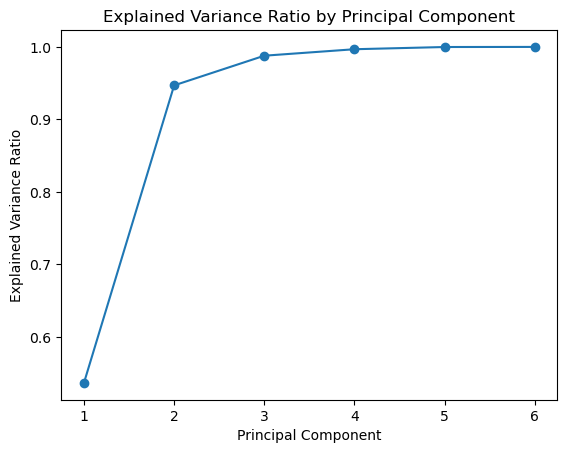

In [55]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(opioid_LA_ex_vratio) + 1)
y = opioid_LA_ex_vratio
# plot
ax.plot(x, y, marker='o')
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [57]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

opioid_LA_comps = opioid_LA_pca.components_

opioid_LA_comps_df = pd.DataFrame(
    opioid_LA_comps,
    columns=X_opioid_LA.columns,
    index=[f'PC{i+1}' for i in range(opioid_LA_comps.shape[0])]
)

print(opioid_LA_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     Opioid_LA_Prscrbr_Rate  Opioid_LA_Tot_Clms_norm  \
PC1                0.059520                -0.005168   
PC2                0.002611                 0.184393   
PC3                0.012953                 0.982471   
PC4                0.919230                -0.021087   
PC5               -0.384886                -0.016560   
PC6               -0.056235                -0.001973   

     Opioid_LA_Tot_Drug_Cst_norm  Opioid_LA_Tot_Suply_norm  \
PC1                     0.083258                  0.018674   
PC2                     0.012499                  0.003512   
PC3                     0.019757                  0.009374   
PC4                     0.345035                  0.167082   
PC5                     0.882594                  0.263493   
PC6                    -0.307408                  0.949845   

     Opioid_LA_Tot_Benes_norm  Opioid_LA_Cst_Per_Bene_norm  
PC1                 -0.090949                     0.990393  
PC2                  0.978674                     

In [58]:
# From the ratio plot, the top 2 variables explain 95% of the variance in the data.
# From the table above, Opioid_LA_Cst_Per_Bene_norm (PC1 value = 0.99, 54% of variance) and Opioid_LA_Tot_Benes_norm (PC2 value = 0.98, 95% of variance) will be those two variables.
# Should it become necessary later on in the analysis, these two varaibles can be used to represent the long-acting opioid data.

### Prescriber Demographic Information

In [65]:
# Creating subset of the data: prescriber demographics + opioid data.

prdemo = opioid_norm[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst', 'Tot_Day_Suply', 'Tot_Benes', 'Tot_Cst_Per_Bene', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm']]
prdemo.head()

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm
0,M.D.,I,Bethesda,MD,1.0,Hospitalist,Claim-Specialty,222,254.5,18399.98,5475,112.0,164.285536,0.116071,0.020452,0.000000,0.000000
1,M.D.,I,Toledo,OH,1.0,Anesthesiology,Claim-Specialty,1865,1999.5,62623.40,55983,478.0,131.011297,0.748954,0.573070,3.875878,0.050209
2,DDS,I,Dayton,NV,2.0,Dentist,NPPES-Specialty,118,119.0,456.67,806,59.0,7.740169,0.169492,0.000000,0.000000,0.169492
3,M.D.,I,Cleveland,OH,1.0,Obstetrics & Gynecology,Claim-Specialty,162,340.0,19129.03,9260,64.0,298.891094,0.000000,0.000000,0.000000,0.000000
4,MD,I,Aurora,CO,1.0,General Surgery,Claim-Specialty,41,47.1,1275.79,851,26.0,49.068846,0.576923,0.047960,0.000000,0.000000


In [66]:
# Checking data types in prdemo.

print(prdemo.dtypes)

Prscrbr_Crdntls                    str
Prscrbr_Ent_Cd                     str
Prscrbr_City                       str
Prscrbr_State_Abrvtn               str
Prscrbr_RUCA                    object
Prscrbr_Type                       str
Prscrbr_Type_src                   str
Tot_Clms                         int64
Tot_30day_Fills                float64
Tot_Drug_Cst                   float64
Tot_Day_Suply                    int64
Tot_Benes                      float64
Tot_Cst_Per_Bene               float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
Opioid_LA_Tot_Benes_norm       float64
dtype: object


In [67]:
# Converting objects to strings.

prdemo['Prscrbr_RUCA'] = prdemo['Prscrbr_RUCA'].apply(str)
print(prdemo.dtypes)

Prscrbr_Crdntls                    str
Prscrbr_Ent_Cd                     str
Prscrbr_City                       str
Prscrbr_State_Abrvtn               str
Prscrbr_RUCA                       str
Prscrbr_Type                       str
Prscrbr_Type_src                   str
Tot_Clms                         int64
Tot_30day_Fills                float64
Tot_Drug_Cst                   float64
Tot_Day_Suply                    int64
Tot_Benes                      float64
Tot_Cst_Per_Bene               float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
Opioid_LA_Tot_Benes_norm       float64
dtype: object


In [68]:
# Standardizing numeric data to zscore.

prdemo_num = prdemo[['Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst', 'Tot_Day_Suply', 'Tot_Benes', 'Tot_Cst_Per_Bene', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
prdemo_numz = pd.DataFrame(stats.zscore(prdemo_num, nan_policy = 'omit'), columns = prdemo_num.columns)
prdemo_numz.head()

,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.308770,-0.362400,-0.278032,-0.378390,-0.051982,-0.213015,-0.380841,-0.229684,-0.541352,-0.120023
1,0.224330,-0.026788,-0.210361,-0.026061,0.334353,-0.221295,1.533079,2.626959,-0.383958,10.427882
2,-0.342514,-0.388461,-0.305489,-0.410960,-0.107927,-0.251968,-0.219292,-0.335408,-0.010036,-0.120023
3,-0.328238,-0.345956,-0.276917,-0.351987,-0.102649,-0.179521,-0.731856,-0.335408,-0.541352,-0.120023
4,-0.367498,-0.402289,-0.304236,-0.410646,-0.142761,-0.241684,1.012835,-0.087489,-0.541352,-0.120023


In [69]:
# Comparing against mean values and standard deviations in each column in prdemo_num.

print(prdemo_num.describe())

           Tot_Clms  Tot_30day_Fills  Tot_Drug_Cst  Tot_Day_Suply  \
count  1.048575e+06     1.048575e+06  1.048575e+06   1.048575e+06   
mean   1.173621e+03     2.138782e+03  2.000960e+05   5.971890e+04   
std    3.081978e+03     5.199451e+03  6.535068e+05   1.433544e+05   
min    1.100000e+01     1.100000e+01  0.000000e+00   1.100000e+01   
25%    5.900000e+01     7.210000e+01  1.849625e+03   1.075000e+03   
50%    2.100000e+02     2.663000e+02  1.341479e+04   5.217000e+03   
75%    9.280000e+02     1.462600e+03  1.390551e+05   3.968400e+04   
max    6.662510e+05     6.673819e+05  1.602919e+08   7.288659e+06   

          Tot_Benes  Tot_Cst_Per_Bene  Opioid_Tot_Benes_norm  \
count  1.048575e+06      1.048575e+06           1.048575e+06   
mean   1.612461e+02      1.020345e+03           2.420054e-01   
std    9.473633e+02      4.018780e+03           3.306737e-01   
min    1.000000e+01      0.000000e+00           0.000000e+00   
25%    2.500000e+01      3.775768e+01           0.000000e+

In [70]:
# Concatenate standardized columns (prdemo_numz) with categorical columns from prdemo.

#prdemo_f = pd.concat([prdemo[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src']], prdemo_numz], axis = 1)
#prdemo_f.head()

In [71]:
# Concatenate standardized columns (prdemo_numz) with categorical columns from prdemo.

prdemo_cat = prdemo[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src']]

prdemo_f = pd.concat([prdemo_cat, prdemo_numz], axis = 1)
prdemo_f.head()

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,M.D.,I,Bethesda,MD,1.0,Hospitalist,Claim-Specialty,-0.308770,-0.362400,-0.278032,-0.378390,-0.051982,-0.213015,-0.380841,-0.229684,-0.541352,-0.120023
1,M.D.,I,Toledo,OH,1.0,Anesthesiology,Claim-Specialty,0.224330,-0.026788,-0.210361,-0.026061,0.334353,-0.221295,1.533079,2.626959,-0.383958,10.427882
2,DDS,I,Dayton,NV,2.0,Dentist,NPPES-Specialty,-0.342514,-0.388461,-0.305489,-0.410960,-0.107927,-0.251968,-0.219292,-0.335408,-0.010036,-0.120023
3,M.D.,I,Cleveland,OH,1.0,Obstetrics & Gynecology,Claim-Specialty,-0.328238,-0.345956,-0.276917,-0.351987,-0.102649,-0.179521,-0.731856,-0.335408,-0.541352,-0.120023
4,MD,I,Aurora,CO,1.0,General Surgery,Claim-Specialty,-0.367498,-0.402289,-0.304236,-0.410646,-0.142761,-0.241684,1.012835,-0.087489,-0.541352,-0.120023


In [72]:
# Need indices for categorical data.

#prdemo_cat_cols = prdemo_f.select_dtypes(include = ['object', 'string', 'category']).columns.tolist()
#print(prdemo_cat_cols)

#prdemo_catidx = [prdemo_f.columns.get_loc(col) for col in prdemo_cat_cols]
#print(prdemo_catidx)

In [73]:
# Need indices for categorical data.

prdemo_cat_col_pos = [prdemo_f.columns.get_loc(col) for col in list(prdemo_f.select_dtypes(include = ['object', 'string', 'category']).columns)]
print('Categorical columns: {}'.format(list(prdemo_f.select_dtypes(include = ['object', 'string', 'category']).columns)))
print('Categorical columns position: {}'.format(prdemo_cat_col_pos))

Categorical columns: ['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src']
Categorical columns position: [0, 1, 2, 3, 4, 5, 6]


In [74]:
# Check for null values per column. I got an error when trying to run the kprototypes model (ML).
print(prdemo_f.isnull().sum())

Prscrbr_Crdntls                0
Prscrbr_Ent_Cd                 0
Prscrbr_City                   0
Prscrbr_State_Abrvtn           0
Prscrbr_RUCA                   0
Prscrbr_Type                   0
Prscrbr_Type_src               0
Tot_Clms                       0
Tot_30day_Fills                0
Tot_Drug_Cst                   0
Tot_Day_Suply                  0
Tot_Benes                      0
Tot_Cst_Per_Bene               0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [75]:
# Create a sample set of prdemo (10% of data) for model optimization purposes.

prdemo_f_10 = prdemo_f.sample(frac = 0.01, random_state = 0)
prdemo_f_10.describe()

,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
count,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000
mean,-0.019493,-0.022637,-0.009786,-0.024798,0.005380,-0.001666,0.013704,0.019750,0.001452,0.024744
std,0.971184,0.953097,1.062067,0.935695,1.309270,0.882515,1.007562,0.986321,1.001079,1.096403
min,-0.377232,-0.409232,-0.306188,-0.416506,-0.159650,-0.253894,-0.731856,-0.335408,-0.541352,-0.120023
25%,-0.361983,-0.397707,-0.303479,-0.409439,-0.143816,-0.244856,-0.731856,-0.335408,-0.541352,-0.120023
50%,-0.315584,-0.361054,-0.286570,-0.380619,-0.092094,-0.191516,-0.459548,-0.335408,-0.541352,-0.120023
75%,-0.098921,-0.155657,-0.104421,-0.165692,0.039852,-0.041869,0.310948,-0.185947,-0.066387,-0.120023
max,56.336701,33.315559,65.514474,11.049911,131.477346,28.853716,2.292274,17.270526,2.593414,26.258354


In [76]:
# Remove opioid data from prdemo_f.

prdemo_fo_10 = prdemo_f_10[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst', 'Tot_Day_Suply', 'Tot_Benes', 'Tot_Cst_Per_Bene']]
prdemo_fo_10.head()

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene
875680,"PA-C, M.H.S.",I,Asheville,NC,1.0,Physician Assistant,NPPES-Specialty,-0.375935,-0.408463,-0.306009,-0.415773,-0.159650,-0.250973
1046906,Unknown,I,Searcy,AR,4.0,Nurse Practitioner,NPPES-Specialty,0.051064,-0.043136,-0.189652,-0.051278,0.036685,-0.157209
646861,DDS,I,Sugar Land,TX,1.0,Dentist,NPPES-Specialty,-0.375286,-0.408078,-0.306077,-0.415403,-0.158594,-0.252247
704385,P.A.,I,Douglas,GA,4.0,Physician Assistant,Claim-Specialty,-0.283137,-0.332012,-0.272915,-0.339780,-0.078371,-0.191703
798051,MD,I,Frisco,TX,1.0,Gastroenterology,Claim-Specialty,-0.164706,-0.161091,-0.129682,-0.165240,0.074685,-0.130178


In [77]:
# Convert the data frame to a matrix.

prdemo_fmat = prdemo_fo_10.to_numpy()

In [78]:
from plotnine import *
import plotnine as p9

Cluster initiation: 1
Cluster initiation: 2
Cluster initiation: 3
Cluster initiation: 4
Cluster initiation: 5
Cluster initiation: 6
Cluster initiation: 7
Cluster initiation: 8
Cluster initiation: 9


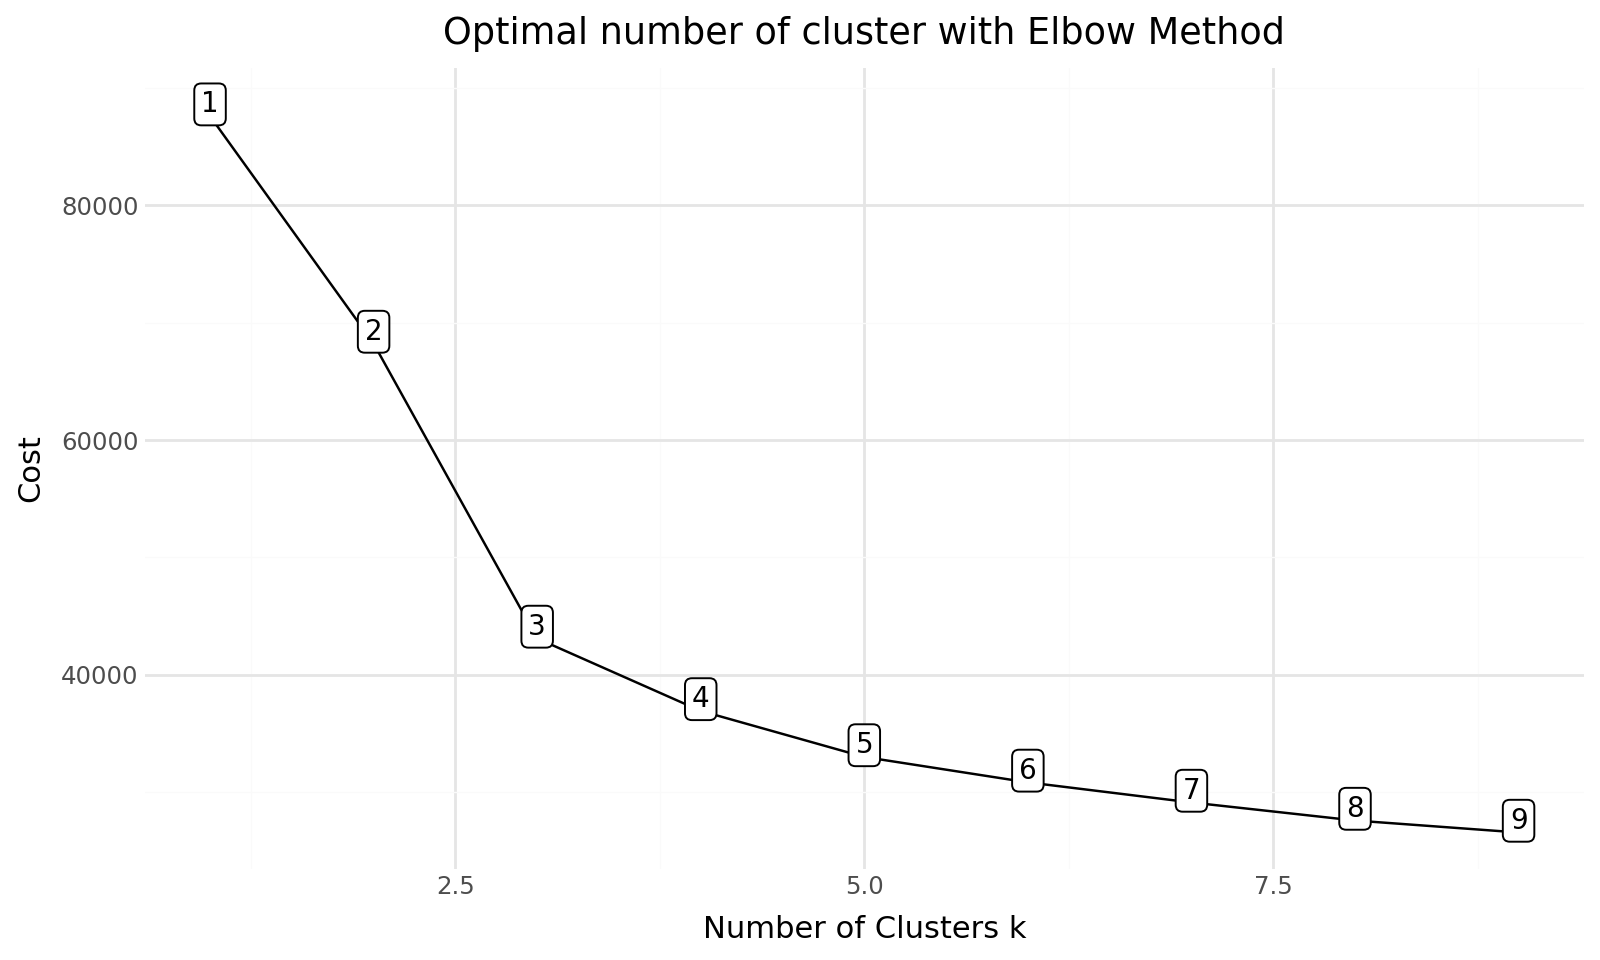

In [79]:
# Use the elbow method to find the optimal number of clusters (k).

cost = []
for cluster in range(1, 10):
    try:
        kprototype_prdemo = KPrototypes(n_jobs = -1, n_clusters = cluster, init = 'Huang', random_state = 0)
        kprototype_prdemo.fit_predict(prdemo_fmat, categorical = prdemo_cat_col_pos)
        cost.append(kprototype_prdemo.cost_)
        print('Cluster initiation: {}'.format(cluster))
    except:
        break
        
# Converting the results into a dataframe and plotting them
prdemo_f_cost = pd.DataFrame({
    'Cluster': range(1, len(cost) + 1),
    'Cost': cost
})

# Data viz
p9.options.figure_size = (8, 4.8)
(
    ggplot(data = prdemo_f_cost)+
    geom_line(aes(x = 'Cluster',
                  y = 'Cost'))+
    geom_point(aes(x = 'Cluster',
                   y = 'Cost'))+
    geom_label(aes(x = 'Cluster',
                   y = 'Cost',
                   label = 'Cluster'),
               size = 10,
               nudge_y = 1000) +
    labs(title = 'Optimal number of cluster with Elbow Method')+
    xlab('Number of Clusters k')+
    ylab('Cost')+
    theme_minimal()
)

In [96]:
#Run Kprototypes using 3 clusters as determined from the elbow plot above.

kprototype_prdemo = KPrototypes(n_jobs = -1, n_clusters = 3, init = 'Huang', random_state = 0)
kprototype_prdemo.fit_predict(prdemo_fmat, categorical = prdemo_cat_col_pos)

array([2, 2, 2, ..., 2, 0, 2], shape=(10486,), dtype=uint16)

In [97]:
# Cluster centorid

kprototype_prdemo.cluster_centroids_

array([['1.9612363968900643', '2.3222754948282476', '1.5613294996546165',
        '2.431539129824851', '0.4531290009027919', '0.6663488869527517',
        'MD', 'I', 'Houston', 'CA', '1.0', 'Family Practice',
        'Claim-Specialty'],
       ['56.33670117031755', '33.31555863475158', '65.51447367837099',
        '1.167764203948866', '131.47734572317756',
        '-0.16807424320688533', 'M.D.', 'I', 'Conway', 'SC', '1.0',
        'Internal Medicine', 'Claim-Specialty'],
       ['-0.2133979708838932', '-0.24870899293834564',
        '-0.16576650719445518', '-0.25808957868481697',
        '-0.05085141639219264', '-0.06505950684349937', 'MD', 'I',
        'New York', 'CA', '1.0', 'Nurse Practitioner', 'Claim-Specialty']],
      dtype='<U32')

In [98]:
# Check the iteration of the clusters created

kprototype_prdemo.n_iter_

10

In [99]:
# Check the cost of the clusters created

kprototype_prdemo.cost_

np.float64(43086.277947270464)

In [100]:
# Add the clusters to the prdemo_f_10 dataframe.

prdemo_f_10['Cluster Labels'] = kprototype_prdemo.labels_
prdemo_f_10['Segment'] = prdemo_f_10['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'})

# Order the cluster
prdemo_f_10['Segment'] = prdemo_f_10['Segment'].astype('category')
prdemo_f_10['Segment'] = prdemo_f_10['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2', 'Cluster 3'])

prdemo_f_10.head(50)

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Total,Segment,Total,Cluster Labels
875680,"PA-C, M.H.S.",I,Asheville,NC,1.0,Physician Assistant,NPPES-Specialty,-0.375935,-0.408463,-0.306009,-0.415773,-0.159650,-0.250973,2.292274,-0.335408,2.593414,-0.120023,2,Cluster 3,0,2
1046906,Unknown,I,Searcy,AR,4.0,Nurse Practitioner,NPPES-Specialty,0.051064,-0.043136,-0.189652,-0.051278,0.036685,-0.157209,-0.330696,0.100450,-0.381415,-0.120023,2,Cluster 3,0,2
646861,DDS,I,Sugar Land,TX,1.0,Dentist,NPPES-Specialty,-0.375286,-0.408078,-0.306077,-0.415403,-0.158594,-0.252247,-0.731856,-0.335408,-0.541352,-0.120023,2,Cluster 3,0,2
704385,P.A.,I,Douglas,GA,4.0,Physician Assistant,Claim-Specialty,-0.283137,-0.332012,-0.272915,-0.339780,-0.078371,-0.191703,-0.731856,-0.335408,-0.541352,-0.120023,2,Cluster 3,0,2
798051,MD,I,Frisco,TX,1.0,Gastroenterology,Claim-Specialty,-0.164706,-0.161091,-0.129682,-0.165240,0.074685,-0.130178,-0.601506,-0.335408,-0.406233,-0.120023,2,Cluster 3,0,2
800217,APRN,I,Indianapolis,IN,1.0,Nurse Practitioner,NPPES-Specialty,-0.345759,-0.365054,-0.294050,-0.371219,-0.158594,-0.074448,-0.731856,-0.335408,-0.541352,-0.120023,2,Cluster 3,0,2
267711,MD,I,Philadelphia,PA,1.0,Internal Medicine,NPPES-Taxonomy,-0.324993,-0.355477,-0.015567,-0.359151,-0.119538,0.730666,-0.731856,-0.335408,-0.541352,-0.120023,2,Cluster 3,0,2
363947,D.O.,I,Kansas City,MO,1.0,Nephrology,Claim-Specialty,-0.179632,-0.259197,-0.084801,-0.281728,-0.000260,-0.030289,-0.243487,-0.271053,-0.346646,-0.120023,2,Cluster 3,0,2
1018796,PA-C,I,Eau Claire,WI,1.0,Physician Assistant,Claim-Specialty,-0.340568,-0.387499,-0.295968,-0.409495,-0.070982,-0.236213,-0.410140,-0.335408,-0.207866,-0.120023,2,Cluster 3,0,2
980271,DMD,I,Bellflower,CA,1.0,Dentist,NPPES-Specialty,-0.354844,-0.395962,-0.305728,-0.411706,-0.127983,-0.252024,0.024177,-0.335408,0.242340,-0.120023,2,Cluster 3,0,2


In [101]:
# Cluster interpretation

prdemo_f_10.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
prdemo_f_10.groupby('Segment').agg(
    {
        'Total': 'count',
        'Prscrbr_Crdntls': lambda x: x.value_counts().index[0],
        'Prscrbr_Ent_Cd': lambda x: x.value_counts().index[0],
        'Prscrbr_City': lambda x: x.value_counts().index[0],
        'Prscrbr_State_Abrvtn': lambda x: x.value_counts().index[0],
        'Prscrbr_RUCA': lambda x: x.value_counts().index[0],
        'Prscrbr_Type': lambda x: x.value_counts().index[0],
        'Prscrbr_Type_src': lambda x: x.value_counts().index[0],
        'Tot_Clms': 'mean',
        'Tot_30day_Fills': 'mean',
        'Tot_Drug_Cst': 'mean',
        'Tot_Day_Suply': 'mean',
        'Tot_Benes': 'mean',
        'Tot_Cst_Per_Bene': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

,Segment,Total,Total,Total,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,909,909,909,MD,I,Houston,CA,1.0,Family Practice,Claim-Specialty,1.961236,2.322275,1.561329,2.431539,0.453129,0.666349,-0.462546,0.050457,-0.477716,0.329070
1,Cluster 2,1,1,1,M.D.,I,Conway,SC,1.0,Internal Medicine,Claim-Specialty,56.336701,33.315559,65.514474,1.167764,131.477346,-0.168074,-0.731080,-0.223254,-0.541101,-0.120023
2,Cluster 3,9576,9576,9576,MD,I,New York,CA,1.0,Nurse Practitioner,Claim-Specialty,-0.213398,-0.248709,-0.165767,-0.258090,-0.050851,-0.065060,0.058989,0.016860,0.046993,-0.004129


In [95]:
# Note: Based on the elbow method, 3 clusters were originally selected for this model.
# However, after looking at the cluster sizes in the summary table, there was a third cluster that had only 1 value in it. Therefore, the model was adjusted for 2 clusters, shown above.

In [102]:
#Run Kprototypes using 3 clusters as determined from the elbow plot above.

kprototype_prdemo2 = KPrototypes(n_jobs = -1, n_clusters = 2, init = 'Huang', random_state = 0)
kprototype_prdemo2.fit_predict(prdemo_fmat, categorical = prdemo_cat_col_pos)

array([0, 0, 0, ..., 0, 1, 0], shape=(10486,), dtype=uint16)

In [103]:
# Cluster centorid

kprototype_prdemo2.cluster_centroids_

array([['-0.20663521742392824', '-0.24080283273732325',
        '-0.15987530592660645', '-0.2498872791481267',
        '-0.049130002571630124', '-0.06205170529470874', 'MD', 'I',
        'New York', 'CA', '1.0', 'Nurse Practitioner', 'Claim-Specialty'],
       ['2.0993324754862215', '2.4474288607287225', '1.6895199630706994',
        '2.5236603552539756', '0.6225452631607943', '0.6820228049095328',
        'MD', 'I', 'Houston', 'CA', '1.0', 'Family Practice',
        'Claim-Specialty']], dtype='<U32')

In [104]:
# Check the iteration of the clusters created

kprototype_prdemo2.n_iter_

12

In [105]:
# Check the cost of the clusters created

kprototype_prdemo2.cost_

np.float64(68228.8024888597)

In [107]:
# Add the clusters to the prdemo_f_10 dataframe.
# Adjust map based on k clusters.
# If this doesn't work, then try into prdemo_fo_10 and then concatenate with the opioid data points.

prdemo_f_102 = prdemo_f_10.copy()

prdemo_f_102['Cluster Labels'] = kprototype_prdemo2.labels_
prdemo_f_102['Segment'] = prdemo_f_102['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2'})

# Order the cluster
prdemo_f_102['Segment'] = prdemo_f_102['Segment'].astype('category')
prdemo_f_102['Segment'] = prdemo_f_102['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2'])

prdemo_f_102.head(50)

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Total,Segment,Total,Total,Cluster Labels
875680,"PA-C, M.H.S.",I,Asheville,NC,1.0,Physician Assistant,NPPES-Specialty,-0.375935,-0.408463,-0.306009,-0.415773,-0.159650,-0.250973,2.292274,-0.335408,2.593414,-0.120023,2,Cluster 1,0,2,0
1046906,Unknown,I,Searcy,AR,4.0,Nurse Practitioner,NPPES-Specialty,0.051064,-0.043136,-0.189652,-0.051278,0.036685,-0.157209,-0.330696,0.100450,-0.381415,-0.120023,2,Cluster 1,0,2,0
646861,DDS,I,Sugar Land,TX,1.0,Dentist,NPPES-Specialty,-0.375286,-0.408078,-0.306077,-0.415403,-0.158594,-0.252247,-0.731856,-0.335408,-0.541352,-0.120023,2,Cluster 1,0,2,0
704385,P.A.,I,Douglas,GA,4.0,Physician Assistant,Claim-Specialty,-0.283137,-0.332012,-0.272915,-0.339780,-0.078371,-0.191703,-0.731856,-0.335408,-0.541352,-0.120023,2,Cluster 1,0,2,0
798051,MD,I,Frisco,TX,1.0,Gastroenterology,Claim-Specialty,-0.164706,-0.161091,-0.129682,-0.165240,0.074685,-0.130178,-0.601506,-0.335408,-0.406233,-0.120023,2,Cluster 1,0,2,0
800217,APRN,I,Indianapolis,IN,1.0,Nurse Practitioner,NPPES-Specialty,-0.345759,-0.365054,-0.294050,-0.371219,-0.158594,-0.074448,-0.731856,-0.335408,-0.541352,-0.120023,2,Cluster 1,0,2,0
267711,MD,I,Philadelphia,PA,1.0,Internal Medicine,NPPES-Taxonomy,-0.324993,-0.355477,-0.015567,-0.359151,-0.119538,0.730666,-0.731856,-0.335408,-0.541352,-0.120023,2,Cluster 1,0,2,0
363947,D.O.,I,Kansas City,MO,1.0,Nephrology,Claim-Specialty,-0.179632,-0.259197,-0.084801,-0.281728,-0.000260,-0.030289,-0.243487,-0.271053,-0.346646,-0.120023,2,Cluster 1,0,2,0
1018796,PA-C,I,Eau Claire,WI,1.0,Physician Assistant,Claim-Specialty,-0.340568,-0.387499,-0.295968,-0.409495,-0.070982,-0.236213,-0.410140,-0.335408,-0.207866,-0.120023,2,Cluster 1,0,2,0
980271,DMD,I,Bellflower,CA,1.0,Dentist,NPPES-Specialty,-0.354844,-0.395962,-0.305728,-0.411706,-0.127983,-0.252024,0.024177,-0.335408,0.242340,-0.120023,2,Cluster 1,0,2,0


In [108]:
# Cluster interpretation

prdemo_f_102.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
prdemo_f_102.groupby('Segment').agg(
    {
        'Total': 'count',
        'Prscrbr_Crdntls': lambda x: x.value_counts().index[0],
        'Prscrbr_Ent_Cd': lambda x: x.value_counts().index[0],
        'Prscrbr_City': lambda x: x.value_counts().index[0],
        'Prscrbr_State_Abrvtn': lambda x: x.value_counts().index[0],
        'Prscrbr_RUCA': lambda x: x.value_counts().index[0],
        'Prscrbr_Type': lambda x: x.value_counts().index[0],
        'Prscrbr_Type_src': lambda x: x.value_counts().index[0],
        'Tot_Clms': 'mean',
        'Tot_30day_Fills': 'mean',
        'Tot_Drug_Cst': 'mean',
        'Tot_Day_Suply': 'mean',
        'Tot_Benes': 'mean',
        'Tot_Cst_Per_Bene': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

,Segment,Total,Total,Total,Total,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,9635,9635,9635,9635,MD,I,New York,CA,1.0,Nurse Practitioner,Claim-Specialty,-0.206635,-0.240803,-0.159875,-0.249887,-0.049130,-0.062052,0.055391,0.016972,0.043846,-0.002860
1,Cluster 2,851,851,851,851,MD,I,Houston,CA,1.0,Family Practice,Claim-Specialty,2.099332,2.447429,1.689520,2.523660,0.622545,0.682023,-0.458280,0.051200,-0.478533,0.337282


### Beneficiaries Age 65+

In [109]:
# Creating subset of the data: beneficiaries aged 65+ + opioid data.

ge65 = opioid_norm[['GE65_Tot_Clms', 'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply', 'GE65_Tot_Benes', 'GE65_Cst_Per_Bene', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
ge65.head()

,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Tot_Benes,GE65_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,192.0,220.5,15997.83,4769.0,96.0,166.644062,0.116071,0.020452,0.000000,0.000000
1,1017.0,1081.0,36179.85,29714.0,290.0,124.758103,0.748954,0.573070,0.050209,3.875878
2,105.0,106.0,413.64,703.0,10.0,41.364000,0.169492,0.000000,0.169492,0.000000
3,134.0,274.3,10246.24,7351.0,10.0,1024.624000,0.000000,0.000000,0.000000,0.000000
4,20.0,25.0,396.98,329.0,10.0,39.698000,0.576923,0.047960,0.000000,0.000000


In [110]:
# Checking data types in ge65.

print(ge65.dtypes)

GE65_Tot_Clms                  float64
GE65_Tot_30day_Fills           float64
GE65_Tot_Drug_Cst              float64
GE65_Tot_Day_Suply             float64
GE65_Tot_Benes                 float64
GE65_Cst_Per_Bene              float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Tot_Benes_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
dtype: object


In [111]:
# Check for null values per column (ML).
print(ge65.isnull().sum())

GE65_Tot_Clms                  0
GE65_Tot_30day_Fills           0
GE65_Tot_Drug_Cst              0
GE65_Tot_Day_Suply             0
GE65_Tot_Benes                 0
GE65_Cst_Per_Bene              0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [113]:
# Preparing for a Principal Component Reduction.

X_ge65 = ge65.drop(columns = ['Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm'])
ge65_corr = X_ge65.corr()

ge65_corr

,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Tot_Benes,GE65_Cst_Per_Bene
GE65_Tot_Clms,1.000000,0.935718,0.644299,0.825779,0.560405,0.072013
GE65_Tot_30day_Fills,0.935718,1.000000,0.574964,0.963246,0.402030,0.072241
GE65_Tot_Drug_Cst,0.644299,0.574964,1.000000,0.458074,0.613406,0.332803
GE65_Tot_Day_Suply,0.825779,0.963246,0.458074,1.000000,0.170349,0.075723
GE65_Tot_Benes,0.560405,0.402030,0.613406,0.170349,1.000000,-0.008075
GE65_Cst_Per_Bene,0.072013,0.072241,0.332803,0.075723,-0.008075,1.000000


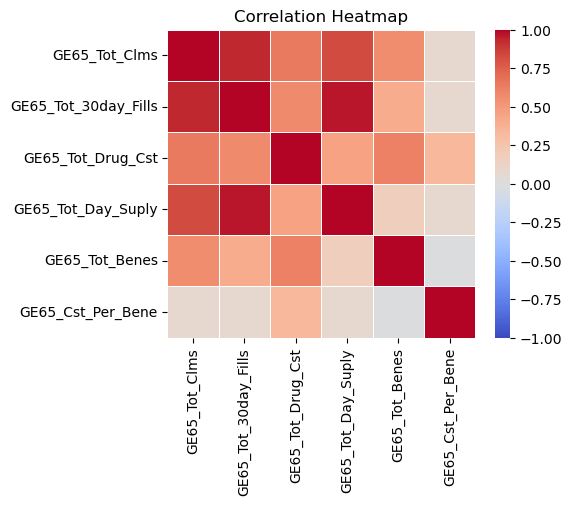

In [114]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    ge65_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [115]:
# Running the Principal Component Reduction.

ge65_pca = PCA(n_components = 6)
ge65_pca_c = ge65_pca.fit_transform(X_ge65)

In [116]:
# Looking at the variability explained by each component in ge65.

ge65_pca.explained_variance_ratio_
ge65_ex_vratio = np.cumsum(ge65_pca.explained_variance_ratio_)
ge65_ex_vratio

array([0.95776136, 0.99929248, 0.99999017, 0.99999894, 0.99999986,
       1.        ])

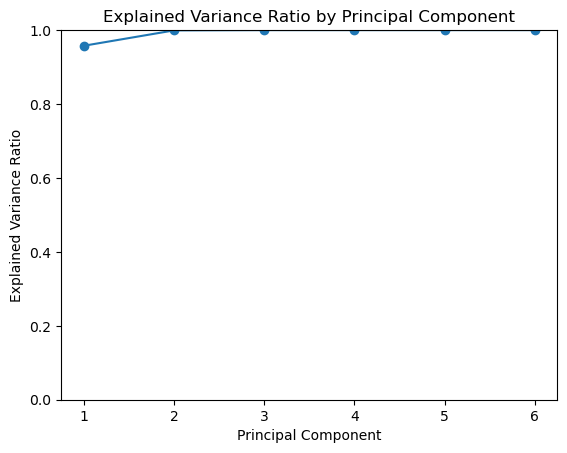

In [170]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(ge65_ex_vratio) + 1)
y = ge65_ex_vratio
# plot
ax.plot(x, y, marker='o')
ax.set_ylim(0, 1)
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [119]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

ge65_comps = ge65_pca.components_

ge65_comps_df = pd.DataFrame(
    ge65_comps,
    columns=X_ge65.columns,
    index=[f'PC{i+1}' for i in range(ge65_comps.shape[0])]
)

print(ge65_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     GE65_Tot_Clms  GE65_Tot_30day_Fills  GE65_Tot_Drug_Cst  \
PC1       0.003257              0.005074           0.993552   
PC2       0.013826              0.031770          -0.112821   
PC3      -0.017836             -0.017071          -0.010864   
PC4       0.739590              0.591801          -0.002769   
PC5      -0.581497              0.325751          -0.000408   
PC6      -0.338154              0.736431           0.000175   

     GE65_Tot_Day_Suply  GE65_Tot_Benes  GE65_Cst_Per_Bene  
PC1            0.112813        0.001010           0.009508  
PC2            0.992922       -0.001099          -0.013228  
PC3            0.012858       -0.014702           0.999445  
PC4           -0.028820        0.318021           0.028325  
PC5           -0.001465        0.745458           0.006167  
PC6           -0.019507       -0.585608          -0.001818  


In [ ]:
# From the ratio plot, the top variable explains 99% of the variance in the data.
# From the table above, GE65_Tot_Drug_Cst (PC1 value = 0.99) will be that variable.

In [120]:
# Standardizing numeric data to zscore.

ge65_num = ge65[['GE65_Tot_Drug_Cst', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
ge65_numz = pd.DataFrame(stats.zscore(ge65_num, nan_policy = 'omit'), columns = ge65_num.columns)
ge65_numz.head()

,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.246901,-0.380841,-0.229684,-0.541352,-0.120023
1,-0.209714,1.533079,2.626959,-0.383958,10.427882
2,-0.275617,-0.219292,-0.335408,-0.010036,-0.120023
3,-0.257499,-0.731856,-0.335408,-0.541352,-0.120023
4,-0.275648,1.012835,-0.087489,-0.541352,-0.120023


In [121]:
# Comparing against mean values and standard deviations in each column in ge65_num.

print(ge65_num.describe())

       GE65_Tot_Drug_Cst  Opioid_Tot_Benes_norm  Opioid_Cst_Per_Bene_norm  \
count       1.048575e+06           1.048575e+06              1.048575e+06   
mean        1.499935e+05           2.420054e-01              6.488462e-02   
std         5.427098e+05           3.306737e-01              1.934501e-01   
min         0.000000e+00           0.000000e+00              0.000000e+00   
25%         7.987000e+01           0.000000e+00              0.000000e+00   
50%         5.955380e+03           8.695652e-02              0.000000e+00   
75%         9.034540e+04           3.333333e-01              2.710425e-02   
max         1.546347e+08           1.000000e+00              1.246573e+01   

       Opioid_LA_Tot_Benes_norm  Opioid_LA_Cst_Per_Bene_norm  
count              1.048575e+06                 1.048575e+06  
mean               1.726929e-01                 4.410286e-02  
std                3.190032e-01                 3.674549e-01  
min                0.000000e+00                 0.0000

In [123]:
# The ge65-num data frame serves as the final data set because this subset does not include categorical data.

ge65_f = ge65_numz.copy()
ge65_f.head()

,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.246901,-0.380841,-0.229684,-0.541352,-0.120023
1,-0.209714,1.533079,2.626959,-0.383958,10.427882
2,-0.275617,-0.219292,-0.335408,-0.010036,-0.120023
3,-0.257499,-0.731856,-0.335408,-0.541352,-0.120023
4,-0.275648,1.012835,-0.087489,-0.541352,-0.120023


In [124]:
# Check for null values per column.
print(ge65_f.isnull().sum())

GE65_Tot_Drug_Cst              0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [125]:
# Create a sample set of prdemo (10% of data) for model optimization purposes.

ge65_f_10 = ge65_f.sample(frac = 0.01, random_state = 0)
ge65_f_10.describe()

,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
count,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000
mean,-0.010973,0.013704,0.019750,0.001452,0.024744
std,1.085079,1.007562,0.986321,1.001079,1.096403
min,-0.276379,-0.731856,-0.335408,-0.541352,-0.120023
25%,-0.276299,-0.731856,-0.335408,-0.541352,-0.120023
50%,-0.265803,-0.459548,-0.335408,-0.541352,-0.120023
75%,-0.125648,0.310948,-0.185947,-0.066387,-0.120023
max,74.363520,2.292274,17.270526,2.593414,26.258354


In [126]:
# Remove opioid data from prdemo_f.

ge65_fo_10 = ge65_f_10[['GE65_Tot_Drug_Cst']]
ge65_fo_10.head()

,GE65_Tot_Drug_Cst
875680,-0.276379
1046906,-0.165761
646861,-0.276245
704385,-0.265188
798051,-0.070682


In [127]:
# Convert the data frame to a matrix.

ge65_fmat = ge65_fo_10.to_numpy()

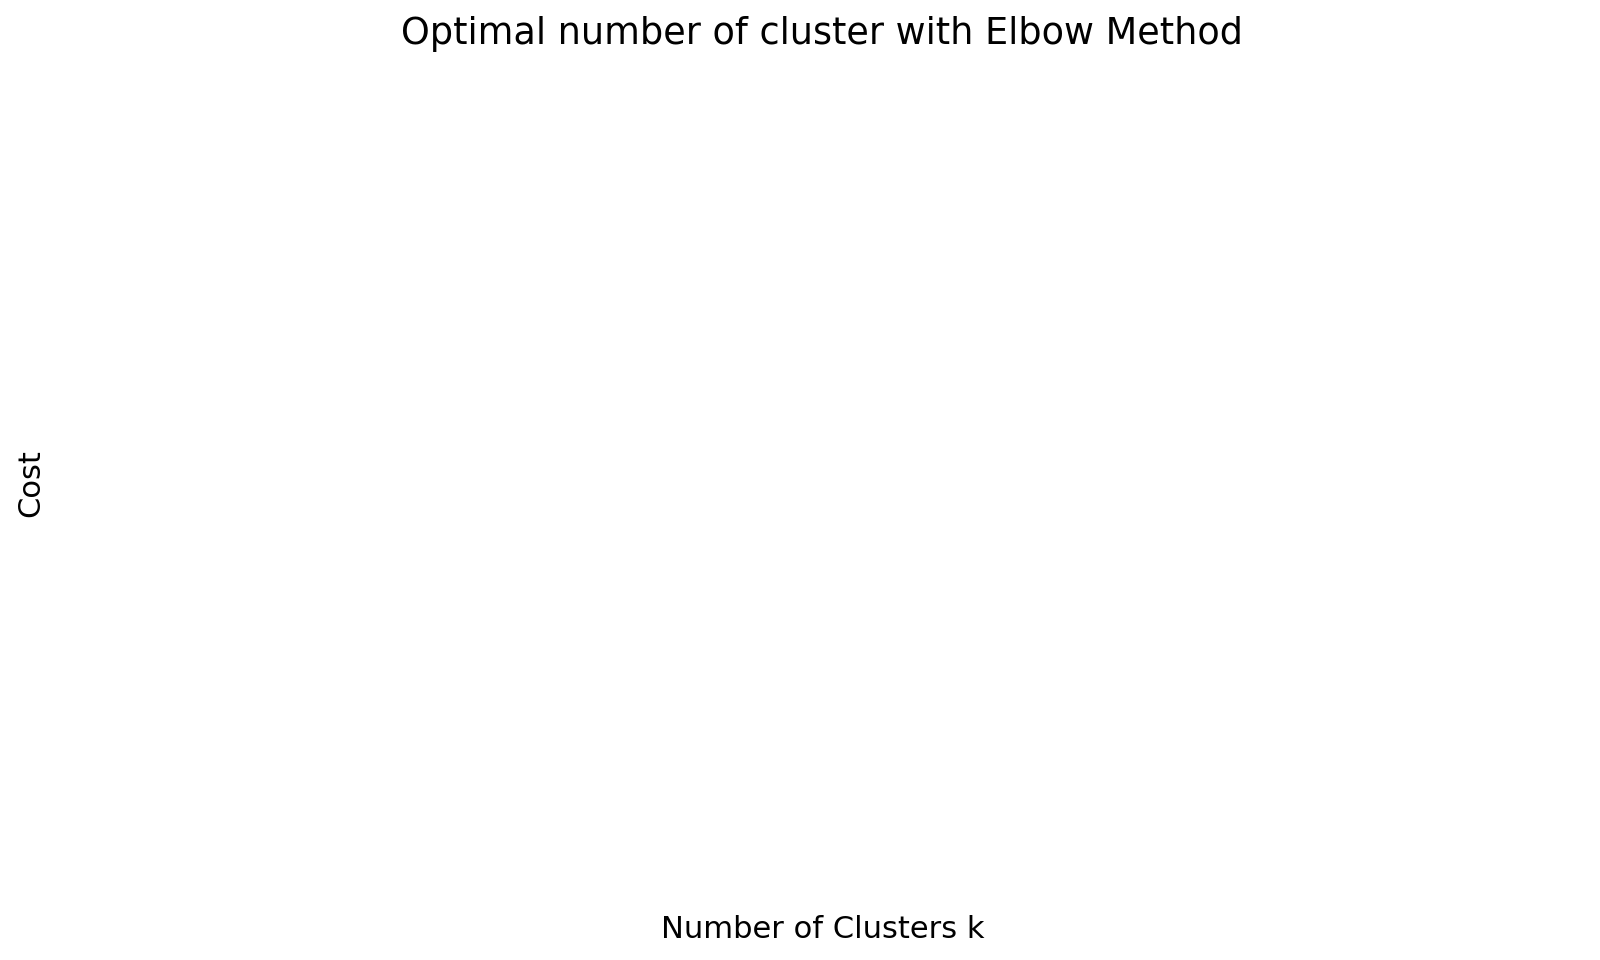

In [128]:
# Use the elbow method to find the optimal number of clusters (k).

cost = []
for cluster in range(1, 10):
    try:
        kprototype_ge65 = KPrototypes(n_jobs = -1, n_clusters = cluster, init = 'Huang', random_state = 0)
        kprototype_ge65.fit_predict(ge65_fmat)
        cost.append(kprototype_ge65.cost_)
        print('Cluster initiation: {}'.format(cluster))
    except:
        break
        
# Converting the results into a dataframe and plotting them
ge65_f_cost = pd.DataFrame({
    'Cluster': range(1, len(cost) + 1),
    'Cost': cost
})

# Data viz
p9.options.figure_size = (8, 4.8)
(
    ggplot(data = ge65_f_cost)+
    geom_line(aes(x = 'Cluster',
                  y = 'Cost'))+
    geom_point(aes(x = 'Cluster',
                   y = 'Cost'))+
    geom_label(aes(x = 'Cluster',
                   y = 'Cost',
                   label = 'Cluster'),
               size = 10,
               nudge_y = 1000) +
    labs(title = 'Optimal number of cluster with Elbow Method')+
    xlab('Number of Clusters k')+
    ylab('Cost')+
    theme_minimal()
)

In [129]:
# Without a graph above, I turned to ChatGPT to help me graph it differently.

costs = []

K = range(1, 10)

for k in K:
    kprototype_ge65 = KPrototypes(n_clusters=k, init='Cao', random_state=42)
    clusters = kprototype_ge65.fit_predict(ge65_fmat)
    costs.append(kprototype_ge65.cost_)

# Plot
plt.plot(K, costs, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('Cost')
plt.title('Elbow Method')
plt.show()

NotImplementedError: No categorical data selected, effectively doing k-means. Present a list of categorical columns, or use scikit-learn's KMeans instead.

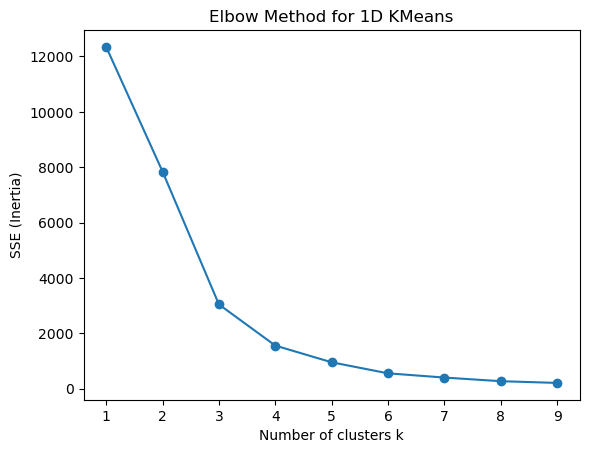

In [239]:
# Using a k-means model to determine number of clusters. Originally tried using kprotoype, but it returned an error because the matrix did not contain categorical data.
# The error suggested using k-means instead.

from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

distortions = []
inertias = []

K = range(1, 10)

for k in K:
    kmeans_ge65 = KMeans(n_clusters=k, random_state=42).fit(ge65_fmat)
    
    distortions.append(sum(np.min(cdist(ge65_fmat, kmeans_ge65.cluster_centers_, 'euclidean'), axis=1)**2) / ge65_fmat.shape[0])
    
    inertias.append(kmeans_ge65.inertia_)

# Plot
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

#Elbow Method for optimal value of k in KMeans. (2019, June 6). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

In [131]:
#Run Kprototypes using 3 clusters as determined from the elbow plot above.

kprototype_ge65 = KPrototypes(n_jobs = -1, n_clusters = 3, init = 'Huang', random_state = 0)
kprototype_ge65.fit_predict(ge65_fmat)

NotImplementedError: No categorical data selected, effectively doing k-means. Present a list of categorical columns, or use scikit-learn's KMeans instead.

In [147]:
#Run k-means using 3 clusters as determined from the elbow plot above.

kmeans_ge65 = KMeans(n_clusters=3, random_state=42).fit(ge65_fmat)

In [148]:
# Cluster centorid

kmeans_ge65.cluster_centers_

array([[ 3.82531594],
       [-0.11155983],
       [74.36352007]])

In [149]:
# Check the iteration of the clusters created

kmeans_ge65.n_iter_

9

In [150]:
# Check the cost of the clusters created

kmeans_ge65.inertia_

3045.288948024138

In [151]:
# Add the clusters to the ge65_f_10 dataframe.
# Adjust map based on k clusters.
# If this doesn't work, then try into prdemo_fo_10 and then concatenate with the opioid data points.

ge65_f_10['Cluster Labels'] = kmeans_ge65.labels_
ge65_f_10['Segment'] = ge65_f_10['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'})

# Order the cluster
ge65_f_10['Segment'] = ge65_f_10['Segment'].astype('category')
ge65_f_10['Segment'] = ge65_f_10['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2', 'Cluster 3'])

ge65_f_10.head(10)

,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Total,Segment,Cluster Labels
875680,-0.276379,2.292274,-0.335408,2.593414,-0.120023,1,Cluster 2,1
1046906,-0.165761,-0.330696,0.100450,-0.381415,-0.120023,1,Cluster 2,1
646861,-0.276245,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1
704385,-0.265188,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1
798051,-0.070682,-0.601506,-0.335408,-0.406233,-0.120023,1,Cluster 2,1
800217,-0.268846,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1
267711,-0.065954,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1
363947,-0.065819,-0.243487,-0.271053,-0.346646,-0.120023,1,Cluster 2,1
1018796,-0.265803,-0.410140,-0.335408,-0.207866,-0.120023,1,Cluster 2,1
980271,-0.276379,0.024177,-0.335408,0.242340,-0.120023,1,Cluster 2,1


In [152]:
# Cluster interpretation

ge65_f_10.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
ge65_f_10.groupby('Segment').agg(
    {
        'Total': 'count',
        'GE65_Tot_Drug_Cst': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

,Segment,Total,Total,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,250,250,3.817454,-0.515110,-0.224671,-0.468675,0.040008
1,Cluster 2,10235,10235,-0.111752,0.026693,0.025744,0.012988,0.024385
2,Cluster 3,1,1,74.363520,-0.731080,-0.223254,-0.541101,-0.120023


In [ ]:
# Note: Based on the elbow method, 3 clusters were originally selected for this model.
# However, after looking at the cluster sizes in the summary table, there was a third cluster that had only 1 value in it. Therefore, the model was adjusted for 2 clusters, shown above.

In [155]:
#Run k-means using 2 clusters as determined from the elbow plot above.

kmeans_ge652 = KMeans(n_clusters=2, random_state=42).fit(ge65_fmat)

In [156]:
# Cluster centorid

kmeans_ge652.cluster_centers_

array([[ 6.95409757],
       [-0.0726223 ]])

In [157]:
# Check the iteration of the clusters created

kmeans_ge652.n_iter_

19

In [158]:
# Check the cost of the clusters created

kmeans_ge652.inertia_

7842.375784160504

In [159]:
# Add the clusters to the ge65_f_10 dataframe.

ge65_f_102 = ge65_f_10.copy()

ge65_f_102['Cluster Labels'] = kmeans_ge652.labels_
ge65_f_102['Segment'] = ge65_f_102['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2'})

# Order the cluster
ge65_f_102['Segment'] = ge65_f_102['Segment'].astype('category')
ge65_f_102['Segment'] = ge65_f_102['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2'])

ge65_f_102.head(10)

,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Total,Segment,Total,Cluster Labels
875680,-0.276379,2.292274,-0.335408,2.593414,-0.120023,1,Cluster 2,1,1
1046906,-0.165761,-0.330696,0.100450,-0.381415,-0.120023,1,Cluster 2,1,1
646861,-0.276245,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1,1
704385,-0.265188,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1,1
798051,-0.070682,-0.601506,-0.335408,-0.406233,-0.120023,1,Cluster 2,1,1
800217,-0.268846,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1,1
267711,-0.065954,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1,1
363947,-0.065819,-0.243487,-0.271053,-0.346646,-0.120023,1,Cluster 2,1,1
1018796,-0.265803,-0.410140,-0.335408,-0.207866,-0.120023,1,Cluster 2,1,1
980271,-0.276379,0.024177,-0.335408,0.242340,-0.120023,1,Cluster 2,1,1


In [160]:
# Cluster interpretation

ge65_f_102.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
ge65_f_102.groupby('Segment').agg(
    {
        'Total': 'count',
        'GE65_Tot_Drug_Cst': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

,Segment,Total,Total,Total,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,92,92,92,6.954098,-0.454073,-0.249942,-0.452128,-0.026133
1,Cluster 2,10394,10394,10394,-0.072622,0.017844,0.022137,0.005466,0.025195


### Generic vs. Brand Name and Insurance Plans

In [161]:
# Creating subset of the data: generic/brand name drugs + insurance plan + opioid data.

gbip = opioid_norm[['Brnd_Tot_Clms', 'Brnd_Tot_Drug_Cst', 'Gnrc_Tot_Clms', 'Gnrc_Tot_Drug_Cst', 'MAPD_Tot_Clms', 'MAPD_Tot_Drug_Cst', 'PDP_Tot_Clms', 'PDP_Tot_Drug_Cst', 'LIS_Tot_Clms', 'LIS_Drug_Cst', 'NonLIS_Tot_Clms', 'NonLIS_Drug_Cst', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
gbip.head()

,Brnd_Tot_Clms,Brnd_Tot_Drug_Cst,Gnrc_Tot_Clms,Gnrc_Tot_Drug_Cst,MAPD_Tot_Clms,MAPD_Tot_Drug_Cst,PDP_Tot_Clms,PDP_Tot_Drug_Cst,LIS_Tot_Clms,LIS_Drug_Cst,NonLIS_Tot_Clms,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,10.0,0.00,189.0,3170.22,91.0,9238.20,131.0,9161.78,66.0,7243.45,156.0,11156.53,0.116071,0.020452,0.000000,0.000000
1,55.0,19957.16,1810.0,42666.24,1314.0,44891.82,551.0,17731.58,1398.0,50702.42,467.0,11920.98,0.748954,0.573070,0.050209,3.875878
2,10.0,0.00,108.0,383.19,46.0,156.89,72.0,299.78,13.0,31.52,105.0,425.15,0.169492,0.000000,0.169492,0.000000
3,17.0,10459.97,145.0,8669.06,72.0,12396.49,90.0,6732.54,31.0,8946.64,131.0,10182.39,0.000000,0.000000,0.000000,0.000000
4,0.0,0.00,41.0,1275.79,24.0,560.95,17.0,714.84,24.0,1212.00,17.0,63.79,0.576923,0.047960,0.000000,0.000000


In [162]:
# Checking data types in gbip.

print(gbip.dtypes)

Brnd_Tot_Clms                  float64
Brnd_Tot_Drug_Cst              float64
Gnrc_Tot_Clms                  float64
Gnrc_Tot_Drug_Cst              float64
MAPD_Tot_Clms                  float64
MAPD_Tot_Drug_Cst              float64
PDP_Tot_Clms                   float64
PDP_Tot_Drug_Cst               float64
LIS_Tot_Clms                   float64
LIS_Drug_Cst                   float64
NonLIS_Tot_Clms                float64
NonLIS_Drug_Cst                float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Tot_Benes_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
dtype: object


In [163]:
# Check for null values per column (ML).

print(gbip.isnull().sum())

Brnd_Tot_Clms                  0
Brnd_Tot_Drug_Cst              0
Gnrc_Tot_Clms                  0
Gnrc_Tot_Drug_Cst              0
MAPD_Tot_Clms                  0
MAPD_Tot_Drug_Cst              0
PDP_Tot_Clms                   0
PDP_Tot_Drug_Cst               0
LIS_Tot_Clms                   0
LIS_Drug_Cst                   0
NonLIS_Tot_Clms                0
NonLIS_Drug_Cst                0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [164]:
# Preparing for a Principal Component Reduction.

X_gbip = gbip.drop(columns = ['Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm'])
gbip_corr = X_gbip.corr()

gbip_corr

,Brnd_Tot_Clms,Brnd_Tot_Drug_Cst,Gnrc_Tot_Clms,Gnrc_Tot_Drug_Cst,MAPD_Tot_Clms,MAPD_Tot_Drug_Cst,PDP_Tot_Clms,PDP_Tot_Drug_Cst,LIS_Tot_Clms,LIS_Drug_Cst,NonLIS_Tot_Clms,NonLIS_Drug_Cst
Brnd_Tot_Clms,1.000000,0.714433,0.269407,0.209284,0.561569,0.550647,0.602980,0.573831,0.364334,0.323581,0.689039,0.681582
Brnd_Tot_Drug_Cst,0.714433,1.000000,0.380471,0.423803,0.550449,0.806519,0.554353,0.781056,0.406020,0.682239,0.601722,0.795805
Gnrc_Tot_Clms,0.269407,0.380471,1.000000,0.712027,0.852355,0.425528,0.785538,0.352293,0.828214,0.476258,0.698577,0.280857
Gnrc_Tot_Drug_Cst,0.209284,0.423803,0.712027,1.000000,0.583184,0.527513,0.611428,0.547982,0.639687,0.628486,0.467920,0.412124
MAPD_Tot_Clms,0.561569,0.550449,0.852355,0.583184,1.000000,0.615030,0.638259,0.384325,0.731542,0.484049,0.799749,0.460671
MAPD_Tot_Drug_Cst,0.550647,0.806519,0.425528,0.527513,0.615030,1.000000,0.429113,0.670855,0.415209,0.791645,0.552134,0.782334
PDP_Tot_Clms,0.602980,0.554353,0.785538,0.611428,0.638259,0.429113,1.000000,0.606371,0.748438,0.470101,0.727390,0.486794
PDP_Tot_Drug_Cst,0.573831,0.781056,0.352293,0.547982,0.384325,0.670855,0.606371,1.000000,0.373913,0.688852,0.510748,0.837363
LIS_Tot_Clms,0.364334,0.406020,0.828214,0.639687,0.731542,0.415209,0.748438,0.373913,1.000000,0.590904,0.393800,0.199737
LIS_Drug_Cst,0.323581,0.682239,0.476258,0.628486,0.484049,0.791645,0.470101,0.688852,0.590904,1.000000,0.304207,0.462233


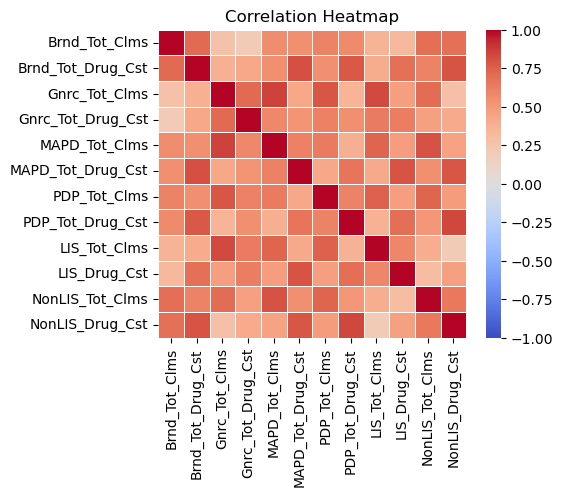

In [165]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    gbip_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()


In [166]:
# Running the Principal Component Reduction.

gbip_pca = PCA(n_components = 6)
gbip_pca_c = gbip_pca.fit_transform(X_gbip)

In [167]:
# Looking at the variability explained by each component in gbip.

gbip_pca.explained_variance_ratio_
gbip_ex_vratio = np.cumsum(gbip_pca.explained_variance_ratio_)
gbip_ex_vratio

array([0.80438096, 0.89601584, 0.94935598, 0.99441775, 0.99865676,
       0.99998917])

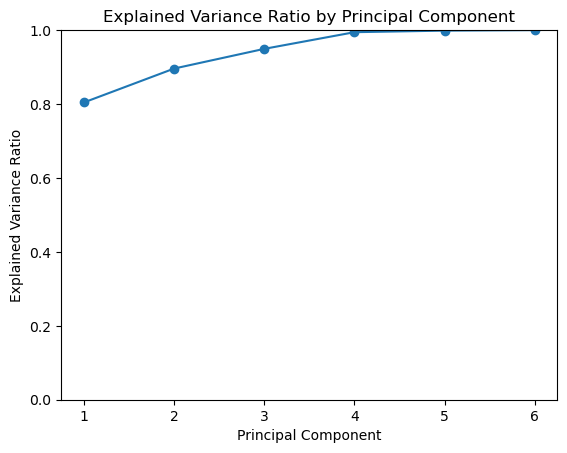

In [169]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(gbip_ex_vratio) + 1)
y = gbip_ex_vratio
# plot
ax.plot(x, y, marker='o')
ax.set_ylim(0, 1)
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [171]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

gbip_comps = gbip_pca.components_

gbip_comps_df = pd.DataFrame(
    gbip_comps,
    columns=X_gbip.columns,
    index=[f'PC{i+1}' for i in range(gbip_comps.shape[0])]
)

print(gbip_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     Brnd_Tot_Clms  Brnd_Tot_Drug_Cst  Gnrc_Tot_Clms  Gnrc_Tot_Drug_Cst  \
PC1       0.001086           0.623167       0.001221           0.052545   
PC2      -0.001219           0.008829       0.002206           0.078463   
PC3       0.001332           0.766682      -0.000802          -0.121568   
PC4       0.000127          -0.144397      -0.000176          -0.044294   
PC5      -0.000499           0.053806       0.022034           0.984946   
PC6      -0.001788          -0.004963      -0.003086          -0.057150   

     MAPD_Tot_Clms  MAPD_Tot_Drug_Cst  PDP_Tot_Clms  PDP_Tot_Drug_Cst  \
PC1       0.001278           0.406814      0.001074          0.363278   
PC2       0.001001           0.264078      0.000058         -0.141430   
PC3       0.000489          -0.202965     -0.000208         -0.411119   
PC4       0.002069           0.686804     -0.002062         -0.650248   
PC5       0.011842          -0.065854      0.009331         -0.116676   
PC6      -0.003894          -0.49751

In [ ]:
# From the ratio plot, the top variable explains 80% of the variance in the data.
# From the table above, Brnd_Tot_Drug_Cst (PC1 value = 0.62) would be that variable.
# However, given that this analysis chunk is made up of essentially 6 variables (brand name drugs, generic-brand drugs, MAPD plan, PDP plan, low-income status, and no low-income status) from 2 different groups (drug brand, insurance plan), I do not feel comfortable clustering only on one variable.
# Therefore, I will move forward with the Cst-related columns of each variable.

In [172]:
# Standardizing numeric data to zscore.

gbip_num = gbip[['Brnd_Tot_Drug_Cst', 'Gnrc_Tot_Drug_Cst', 'MAPD_Tot_Drug_Cst', 'PDP_Tot_Drug_Cst', 'LIS_Drug_Cst', 'NonLIS_Drug_Cst', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
gbip_numz = pd.DataFrame(stats.zscore(gbip_num, nan_policy = 'omit'), columns = gbip_num.columns)
gbip_numz.head()

,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.248995,-0.313289,-0.269222,-0.232405,-0.263182,-0.214637,-0.380841,-0.229684,-0.541352,-0.120023
1,-0.212086,0.172953,-0.173428,-0.207214,-0.132366,-0.212857,1.533079,2.626959,-0.383958,10.427882
2,-0.248995,-0.347601,-0.293621,-0.258456,-0.284891,-0.239613,-0.219292,-0.335408,-0.010036,-0.120023
3,-0.229650,-0.245592,-0.260736,-0.239546,-0.258055,-0.216904,-0.731856,-0.335408,-0.541352,-0.120023
4,-0.248995,-0.336612,-0.292536,-0.257235,-0.281338,-0.240454,1.012835,-0.087489,-0.541352,-0.120023


In [173]:
# Comparing against mean values and standard deviations in each column in gbip_num.

print(gbip_num.describe())

       Brnd_Tot_Drug_Cst  Gnrc_Tot_Drug_Cst  MAPD_Tot_Drug_Cst  \
count       1.048575e+06       1.048575e+06       1.048575e+06   
mean        1.346341e+05       2.861778e+04       1.094402e+05   
std         5.407095e+05       8.122709e+04       3.721915e+05   
min         0.000000e+00       0.000000e+00       0.000000e+00   
25%         0.000000e+00       6.332000e+02       2.733350e+02   
50%         0.000000e+00       3.322130e+03       5.215970e+03   
75%         5.681756e+04       2.344246e+04       6.507210e+04   
max         1.601750e+08       1.832377e+07       7.876053e+07   

       PDP_Tot_Drug_Cst  LIS_Drug_Cst  NonLIS_Drug_Cst  Opioid_Tot_Benes_norm  \
count      1.048575e+06  1.048575e+06     1.048575e+06           1.048575e+06   
mean       8.822355e+04  9.467644e+04     1.033781e+05           2.420054e-01   
std        3.401892e+05  3.322148e+05     4.296638e+05           3.306737e-01   
min        0.000000e+00  0.000000e+00     0.000000e+00           0.000000e+00   


In [174]:
# The gbip-num data frame serves as the final data set because this subset does not include categorical data.

gbip_f = gbip_numz.copy()
gbip_f.head()

,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.248995,-0.313289,-0.269222,-0.232405,-0.263182,-0.214637,-0.380841,-0.229684,-0.541352,-0.120023
1,-0.212086,0.172953,-0.173428,-0.207214,-0.132366,-0.212857,1.533079,2.626959,-0.383958,10.427882
2,-0.248995,-0.347601,-0.293621,-0.258456,-0.284891,-0.239613,-0.219292,-0.335408,-0.010036,-0.120023
3,-0.229650,-0.245592,-0.260736,-0.239546,-0.258055,-0.216904,-0.731856,-0.335408,-0.541352,-0.120023
4,-0.248995,-0.336612,-0.292536,-0.257235,-0.281338,-0.240454,1.012835,-0.087489,-0.541352,-0.120023


In [175]:
# Check for null values per column.

print(gbip_f.isnull().sum())

Brnd_Tot_Drug_Cst              0
Gnrc_Tot_Drug_Cst              0
MAPD_Tot_Drug_Cst              0
PDP_Tot_Drug_Cst               0
LIS_Drug_Cst                   0
NonLIS_Drug_Cst                0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [177]:
# Create a sample set of prdemo (10% of data) for model optimization purposes.

gbip_f_10 = gbip_f.sample(frac = 0.01, random_state = 0)
gbip_f_10.describe()

# Remove opioid data from prdemo_f.

gbip_fo_10 = gbip_f_10[['Brnd_Tot_Drug_Cst', 'Gnrc_Tot_Drug_Cst', 'MAPD_Tot_Drug_Cst', 'PDP_Tot_Drug_Cst', 'LIS_Drug_Cst', 'NonLIS_Drug_Cst']]
gbip_fo_10.head()

,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst
875680,-0.248995,-0.350873,-0.294043,-0.259337,-0.284986,-0.240602
1046906,-0.248995,-0.094030,-0.157825,-0.184501,-0.216046,-0.116658
646861,-0.248995,-0.351422,-0.294043,-0.259337,-0.284986,-0.240602
704385,-0.221459,-0.267925,-0.239769,-0.254798,-0.228751,-0.233475
798051,-0.081435,-0.047659,-0.231475,0.011279,-0.222843,-0.020190


In [178]:
# Convert the data frame to a matrix.

gbip_fmat = gbip_fo_10.to_numpy()

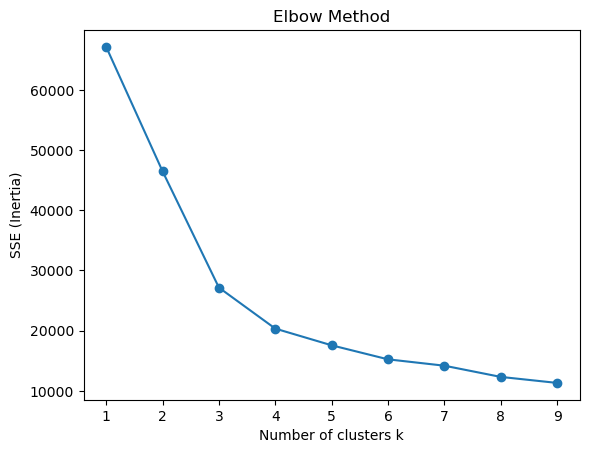

In [240]:
# Using a k-means model to determine number of clusters. Originally tried using kprotoype, but it returned an error because the matrix did not contain categorical data.
# The error suggested using k-means instead.

distortions = []
inertias = []

K = range(1, 10)

for k in K:
    kmeans_gbip = KMeans(n_clusters=k, random_state=42).fit(gbip_fmat)
    
    distortions.append(sum(np.min(cdist(gbip_fmat, kmeans_gbip.cluster_centers_, 'euclidean'), axis=1)**2) / gbip_fmat.shape[0])
    
    inertias.append(kmeans_gbip.inertia_)

# Plot
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

#Elbow Method for optimal value of k in KMeans. (2019, June 6). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

In [203]:
#Run k-means using 3 clusters as determined from the elbow plot above.

kmeans_gbip = KMeans(n_clusters=3, random_state=42).fit(gbip_fmat)

In [204]:
# Cluster centorid

kmeans_gbip.cluster_centers_

array([[ 2.80393701,  2.68377675,  3.2815369 ,  2.78444803,  3.27975104,
         2.54483296],
       [-0.11259816, -0.10901851, -0.1295118 , -0.11421074, -0.13198286,
        -0.10153796],
       [79.15935658,  0.59067638, 64.42120178, 55.37966702, 18.56123586,
        85.29897787]])

In [205]:
# Check the iteration of the clusters created

kmeans_gbip.n_iter_

14

In [206]:
# Check the cost of the clusters created

kmeans_gbip.inertia_

27150.568004716224

In [207]:
# Add the clusters to the gbip_f_10 dataframe.

gbip_f_10['Cluster Labels'] = kmeans_gbip.labels_
gbip_f_10['Segment'] = gbip_f_10['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'})

# Order the cluster
gbip_f_10['Segment'] = gbip_f_10['Segment'].astype('category')
gbip_f_10['Segment'] = gbip_f_10['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2', 'Cluster 3'])

gbip_f_10.head(10)

,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Total,Segment,Total,Cluster Labels
875680,-0.248995,-0.350873,-0.294043,-0.259337,-0.284986,-0.240602,2.292274,-0.335408,2.593414,-0.120023,1,Cluster 2,1,1
1046906,-0.248995,-0.094030,-0.157825,-0.184501,-0.216046,-0.116658,-0.330696,0.100450,-0.381415,-0.120023,1,Cluster 2,1,1
646861,-0.248995,-0.351422,-0.294043,-0.259337,-0.284986,-0.240602,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1,1
704385,-0.221459,-0.267925,-0.239769,-0.254798,-0.228751,-0.233475,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1,1
798051,-0.081435,-0.047659,-0.231475,0.011279,-0.222843,-0.020190,-0.601506,-0.335408,-0.406233,-0.120023,1,Cluster 2,1,1
800217,-0.236366,-0.338725,-0.294043,-0.259337,-0.272907,-0.231479,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1,1
267711,-0.248995,-0.271159,-0.056410,0.038963,0.078509,-0.079628,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1,1
363947,-0.011300,-0.153450,-0.043077,-0.108626,0.038283,-0.153829,-0.243487,-0.271053,-0.346646,-0.120023,1,Cluster 2,1,1
1018796,-0.248995,-0.334204,-0.290747,-0.243309,-0.281227,-0.227963,-0.410140,-0.335408,-0.207866,-0.120023,1,Cluster 2,1,1
980271,-0.248995,-0.348868,-0.294043,-0.259337,-0.284986,-0.240602,0.024177,-0.335408,0.242340,-0.120023,1,Cluster 2,1,1


In [208]:
# Cluster interpretation

gbip_f_10.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
gbip_f_10.groupby('Segment').agg(
    {
        'Total': 'count',
        'Brnd_Tot_Drug_Cst': 'mean',
        'Gnrc_Tot_Drug_Cst': 'mean',
        'MAPD_Tot_Drug_Cst': 'mean',
        'PDP_Tot_Drug_Cst': 'mean',
        'LIS_Drug_Cst': 'mean',
        'NonLIS_Drug_Cst': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

,Segment,Total,Total,Total,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,355,355,355,2.803937,2.683777,3.281537,2.784448,3.279751,2.544833,-0.451625,-0.130871,-0.450809,0.157665
1,Cluster 2,10130,10130,10130,-0.112598,-0.109019,-0.129512,-0.114211,-0.131983,-0.101538,0.030084,0.025052,0.017354,0.020100
2,Cluster 3,1,1,1,79.159357,0.590676,64.421202,55.379667,18.561236,85.298978,-0.731080,-0.223254,-0.541101,-0.120023


In [209]:
#Run k-means using 2 clusters as determined from the elbow plot above.

kmeans_gbip2 = KMeans(n_clusters=2, random_state=42).fit(ge65_fmat)

In [210]:
# Cluster centorid

kmeans_gbip2.cluster_centers_

array([[ 6.95409757],
       [-0.0726223 ]])

In [211]:
# Check the iteration of the clusters created

kmeans_gbip2.n_iter_

19

In [212]:
# Check the cost of the clusters created

kmeans_gbip2.inertia_

7842.375784160504

In [242]:
# Add the clusters to the gbip_f_10 dataframe.

gbip_f_102 = gbip_f_10.copy()

gbip_f_102['Cluster Labels'] = kmeans_gbip2.labels_
gbip_f_102['Segment'] = gbip_f_102['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2'})

# Order the cluster
gbip_f_102['Segment'] = gbip_f_102['Segment'].astype('category')
gbip_f_102['Segment'] = gbip_f_102['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2'])

gbip_f_102.head(10)

,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Total,Segment,Total,Total,Cluster Labels
875680,-0.248995,-0.350873,-0.294043,-0.259337,-0.284986,-0.240602,2.292274,-0.335408,2.593414,-0.120023,1,Cluster 2,1,1,1
1046906,-0.248995,-0.094030,-0.157825,-0.184501,-0.216046,-0.116658,-0.330696,0.100450,-0.381415,-0.120023,1,Cluster 2,1,1,1
646861,-0.248995,-0.351422,-0.294043,-0.259337,-0.284986,-0.240602,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1,1,1
704385,-0.221459,-0.267925,-0.239769,-0.254798,-0.228751,-0.233475,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1,1,1
798051,-0.081435,-0.047659,-0.231475,0.011279,-0.222843,-0.020190,-0.601506,-0.335408,-0.406233,-0.120023,1,Cluster 2,1,1,1
800217,-0.236366,-0.338725,-0.294043,-0.259337,-0.272907,-0.231479,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1,1,1
267711,-0.248995,-0.271159,-0.056410,0.038963,0.078509,-0.079628,-0.731856,-0.335408,-0.541352,-0.120023,1,Cluster 2,1,1,1
363947,-0.011300,-0.153450,-0.043077,-0.108626,0.038283,-0.153829,-0.243487,-0.271053,-0.346646,-0.120023,1,Cluster 2,1,1,1
1018796,-0.248995,-0.334204,-0.290747,-0.243309,-0.281227,-0.227963,-0.410140,-0.335408,-0.207866,-0.120023,1,Cluster 2,1,1,1
980271,-0.248995,-0.348868,-0.294043,-0.259337,-0.284986,-0.240602,0.024177,-0.335408,0.242340,-0.120023,1,Cluster 2,1,1,1


In [215]:
# Cluster interpretation

gbip_f_102.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
gbip_f_102.groupby('Segment').agg(
    {
        'Total': 'count',
        'Brnd_Tot_Drug_Cst': 'mean',
        'Gnrc_Tot_Drug_Cst': 'mean',
        'MAPD_Tot_Drug_Cst': 'mean',
        'PDP_Tot_Drug_Cst': 'mean',
        'LIS_Drug_Cst': 'mean',
        'NonLIS_Drug_Cst': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

,Segment,Total,Total,Total,Total,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,355,355,355,355,2.803937,2.683777,3.281537,2.784448,3.279751,2.544833,-0.451625,-0.130871,-0.450809,0.157665
1,Cluster 2,10130,10130,10130,10130,-0.112598,-0.109019,-0.129512,-0.114211,-0.131983,-0.101538,0.030084,0.025052,0.017354,0.020100


### Additional Medications Prescribed

In [218]:
# Creating subset of the data: additional medications prescribed + opioid data.

meds = opioid_norm[['Antbtc_Tot_Clms', 'Antbtc_Tot_Drug_Cst', 'Antbtc_Tot_Benes', 'Antbtc_Cst_Per_Bene', 'Antpsyct_GE65_Tot_Clms', 'Antpsyct_GE65_Tot_Drug_Cst', 'Antpsyct_GE65_Tot_Benes', 'Antpsyct_GE65_Cst_Per_Bene', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
meds.head()

,Antbtc_Tot_Clms,Antbtc_Tot_Drug_Cst,Antbtc_Tot_Benes,Antbtc_Cst_Per_Bene,Antpsyct_GE65_Tot_Clms,Antpsyct_GE65_Tot_Drug_Cst,Antpsyct_GE65_Tot_Benes,Antpsyct_GE65_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,42.0,731.76,39.0,18.763077,10.0,0.0,10.0,0.0,0.116071,0.020452,0.000000,0.000000
1,10.0,0.00,10.0,0.000000,0.0,0.0,0.0,0.0,0.748954,0.573070,0.050209,3.875878
2,60.0,266.45,49.0,5.437755,0.0,0.0,10.0,0.0,0.169492,0.000000,0.169492,0.000000
3,10.0,0.00,10.0,0.000000,0.0,0.0,10.0,0.0,0.000000,0.000000,0.000000,0.000000
4,10.0,0.00,10.0,0.000000,0.0,0.0,10.0,0.0,0.576923,0.047960,0.000000,0.000000


In [219]:
# Checking data types in meds.

print(meds.dtypes)

Antbtc_Tot_Clms                float64
Antbtc_Tot_Drug_Cst            float64
Antbtc_Tot_Benes               float64
Antbtc_Cst_Per_Bene            float64
Antpsyct_GE65_Tot_Clms         float64
Antpsyct_GE65_Tot_Drug_Cst     float64
Antpsyct_GE65_Tot_Benes        float64
Antpsyct_GE65_Cst_Per_Bene     float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Tot_Benes_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
dtype: object


In [220]:
# Check for null values per column (ML).

print(meds.isnull().sum())

Antbtc_Tot_Clms                0
Antbtc_Tot_Drug_Cst            0
Antbtc_Tot_Benes               0
Antbtc_Cst_Per_Bene            0
Antpsyct_GE65_Tot_Clms         0
Antpsyct_GE65_Tot_Drug_Cst     0
Antpsyct_GE65_Tot_Benes        0
Antpsyct_GE65_Cst_Per_Bene     0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [221]:
# Preparing for a Principal Component Reduction.

X_meds = meds.drop(columns = ['Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm'])
meds_corr = X_meds.corr()

meds_corr

,Antbtc_Tot_Clms,Antbtc_Tot_Drug_Cst,Antbtc_Tot_Benes,Antbtc_Cst_Per_Bene,Antpsyct_GE65_Tot_Clms,Antpsyct_GE65_Tot_Drug_Cst,Antpsyct_GE65_Tot_Benes,Antpsyct_GE65_Cst_Per_Bene
Antbtc_Tot_Clms,1.000000,0.290210,0.932756,0.055011,0.238260,0.084232,0.143895,0.036185
Antbtc_Tot_Drug_Cst,0.290210,1.000000,0.162327,0.683212,0.112106,0.049936,0.062025,0.017118
Antbtc_Tot_Benes,0.932756,0.162327,1.000000,0.004815,0.138656,0.037110,0.054977,0.010588
Antbtc_Cst_Per_Bene,0.055011,0.683212,0.004815,1.000000,0.004437,0.000449,-0.031043,-0.002637
Antpsyct_GE65_Tot_Clms,0.238260,0.112106,0.138656,0.004437,1.000000,0.575493,0.784278,0.283865
Antpsyct_GE65_Tot_Drug_Cst,0.084232,0.049936,0.037110,0.000449,0.575493,1.000000,0.457794,0.723842
Antpsyct_GE65_Tot_Benes,0.143895,0.062025,0.054977,-0.031043,0.784278,0.457794,1.000000,0.194749
Antpsyct_GE65_Cst_Per_Bene,0.036185,0.017118,0.010588,-0.002637,0.283865,0.723842,0.194749,1.000000


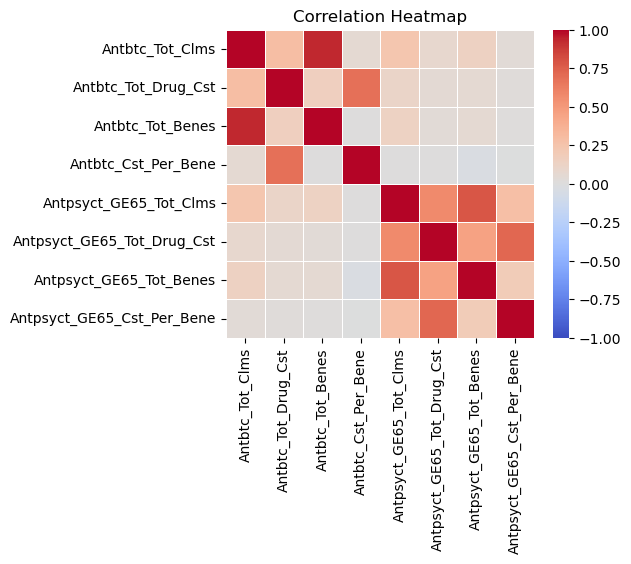

In [222]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    meds_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()


In [223]:
# Running the Principal Component Reduction.

meds_pca = PCA(n_components = 6)
meds_pca_c = meds_pca.fit_transform(X_meds)

In [224]:
# Looking at the variability explained by each component in meds.

meds_pca.explained_variance_ratio_
meds_ex_vratio = np.cumsum(meds_pca.explained_variance_ratio_)
meds_ex_vratio

array([0.55831174, 0.9993591 , 0.99974764, 0.99997319, 0.99999418,
       0.99999944])

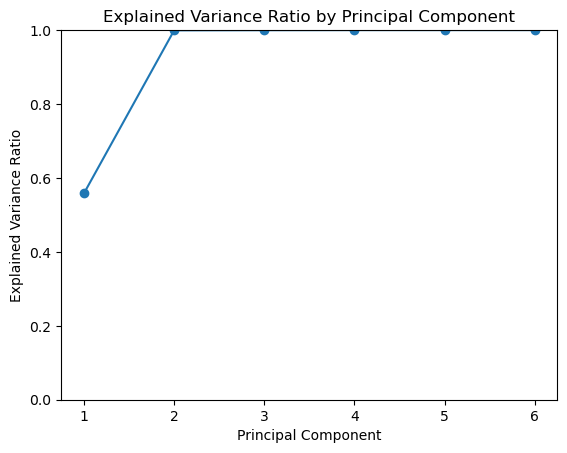

In [227]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(meds_ex_vratio) + 1)
y = meds_ex_vratio
# plot
ax.plot(x, y, marker='o')
ax.set_ylim(0, 1)
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [228]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

meds_comps = meds_pca.components_

meds_comps_df = pd.DataFrame(
    meds_comps,
    columns=X_meds.columns,
    index=[f'PC{i+1}' for i in range(meds_comps.shape[0])]
)

print(meds_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     Antbtc_Tot_Clms  Antbtc_Tot_Drug_Cst  Antbtc_Tot_Benes  \
PC1         0.000776             0.216512          0.000226   
PC2         0.001673             0.976050          0.000567   
PC3        -0.007696             0.000053         -0.003246   
PC4        -0.058842            -0.020928         -0.026968   
PC5         0.848362            -0.003262          0.511202   
PC6        -0.062979            -0.000302         -0.129958   

     Antbtc_Cst_Per_Bene  Antpsyct_GE65_Tot_Clms  Antpsyct_GE65_Tot_Drug_Cst  \
PC1             0.003654                0.002295                    0.975896   
PC2             0.020787               -0.000131                   -0.216436   
PC3             0.037444               -0.029286                   -0.027731   
PC4             0.996857               -0.013302                    0.002055   
PC5             0.065816                0.120216                   -0.000857   
PC6             0.007170                0.983474                   -0.002995  

In [230]:
# From the ratio plot, the top 2 variables explain >99% of the variance in the data.
# From the table above, Antpsyct_GE65_Tot_Drug_Cst (PC1 value = 0.98, 56% of variance) and Antbtc_Tot_Drug_Cst (PC2 value = 0.98, >99% of variance) would be those variables.
# With such high variance (>99%) explained by two variables, overfitting is a concern, but including both variables seems necessary.
# Each variable represents a different medication: antibiotics and antipsychotics.

In [231]:
# Standardizing numeric data to zscore.

meds_num = meds[['Antbtc_Tot_Drug_Cst', 'Antpsyct_GE65_Tot_Drug_Cst', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
meds_numz = pd.DataFrame(stats.zscore(meds_num, nan_policy = 'omit'), columns = meds_num.columns)
meds_numz.head()

,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.082312,-0.103444,-0.380841,-0.229684,-0.541352,-0.120023
1,-0.131887,-0.103444,1.533079,2.626959,-0.383958,10.427882
2,-0.113836,-0.103444,-0.219292,-0.335408,-0.010036,-0.120023
3,-0.131887,-0.103444,-0.731856,-0.335408,-0.541352,-0.120023
4,-0.131887,-0.103444,1.012835,-0.087489,-0.541352,-0.120023


In [232]:
# Comparing against mean values and standard deviations in each column in meds_num.

print(meds_num.describe())

       Antbtc_Tot_Drug_Cst  Antpsyct_GE65_Tot_Drug_Cst  Opioid_Tot_Benes_norm  \
count         1.048575e+06                1.048575e+06           1.048575e+06   
mean          1.946720e+03                1.698598e+03           2.420054e-01   
std           1.476050e+04                1.642044e+04           3.306737e-01   
min           0.000000e+00                0.000000e+00           0.000000e+00   
25%           0.000000e+00                0.000000e+00           0.000000e+00   
50%           1.085600e+02                0.000000e+00           8.695652e-02   
75%           6.855500e+02                0.000000e+00           3.333333e-01   
max           2.222074e+06                3.245600e+06           1.000000e+00   

       Opioid_Cst_Per_Bene_norm  Opioid_LA_Tot_Benes_norm  \
count              1.048575e+06              1.048575e+06   
mean               6.488462e-02              1.726929e-01   
std                1.934501e-01              3.190032e-01   
min                0.00000

In [233]:
# The meds-num data frame serves as the final data set because this subset does not include categorical data.

meds_f = meds_numz.copy()
meds_f.head()

,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.082312,-0.103444,-0.380841,-0.229684,-0.541352,-0.120023
1,-0.131887,-0.103444,1.533079,2.626959,-0.383958,10.427882
2,-0.113836,-0.103444,-0.219292,-0.335408,-0.010036,-0.120023
3,-0.131887,-0.103444,-0.731856,-0.335408,-0.541352,-0.120023
4,-0.131887,-0.103444,1.012835,-0.087489,-0.541352,-0.120023


In [234]:
# Check for null values per column.

print(meds_f.isnull().sum())

Antbtc_Tot_Drug_Cst            0
Antpsyct_GE65_Tot_Drug_Cst     0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [235]:
# Create a sample set of prdemo (10% of data) for model optimization purposes.

meds_f_10 = meds_f.sample(frac = 0.01, random_state = 0)
meds_f_10.describe()

,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
count,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000
mean,0.002762,-0.011527,0.013704,0.019750,0.001452,0.024744
std,1.251153,0.983662,1.007562,0.986321,1.001079,1.096403
min,-0.131887,-0.103444,-0.731856,-0.335408,-0.541352,-0.120023
25%,-0.131887,-0.103444,-0.731856,-0.335408,-0.541352,-0.120023
50%,-0.125177,-0.103444,-0.459548,-0.335408,-0.541352,-0.120023
75%,-0.086937,-0.103444,0.310948,-0.185947,-0.066387,-0.120023
max,77.801008,52.112540,2.292274,17.270526,2.593414,26.258354


In [236]:
# Remove opioid data from meds_f.

meds_fo_10 = meds_f_10[['Antbtc_Tot_Drug_Cst', 'Antpsyct_GE65_Tot_Drug_Cst']]
meds_fo_10.head()


,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst
875680,-0.125141,-0.103444
1046906,-0.076027,-0.103444
646861,-0.128904,-0.103444
704385,-0.108541,-0.103444
798051,0.060547,-0.103444


In [237]:
# Convert the data frame to a matrix.

meds_fmat = meds_fo_10.to_numpy()

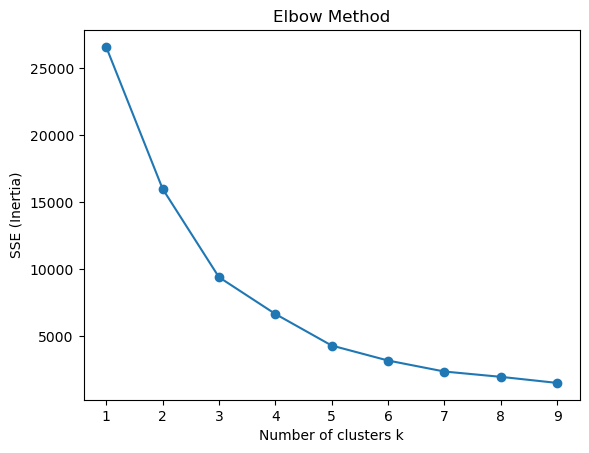

In [241]:
# Using a k-means model to determine number of clusters. Originally tried using kprotoype, but it returned an error because the matrix did not contain categorical data.
# The error suggested using k-means instead.

distortions = []
inertias = []

K = range(1, 10)

for k in K:
    kmeans_meds = KMeans(n_clusters=k, random_state=42).fit(meds_fmat)
    
    distortions.append(sum(np.min(cdist(meds_fmat, kmeans_meds.cluster_centers_, 'euclidean'), axis=1)**2) / meds_fmat.shape[0])
    
    inertias.append(kmeans_meds.inertia_)

# Plot
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

#Elbow Method for optimal value of k in KMeans. (2019, June 6). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

In [249]:
#Run k-means using k clusters as determined from the elbow plot above.

kmeans_meds = KMeans(n_clusters=2, random_state=42).fit(meds_fmat)

In [250]:
# Cluster centorid

kmeans_meds.cluster_centers_

array([[-1.91605913e-02, -1.14833336e-02],
       [ 4.59578816e+01, -1.03444174e-01]])

In [251]:
# Check the iteration of the clusters created

kmeans_meds.n_iter_

2

In [252]:
# Check the cost of the clusters created

kmeans_meds.inertia_

15993.789550625152

In [247]:
# Add the clusters to the meds_f_10 dataframe.

meds_f_10['Cluster Labels'] = kmeans_meds.labels_
meds_f_10['Segment'] = meds_f_10['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'})

# Order the cluster
meds_f_10['Segment'] = meds_f_10['Segment'].astype('category')
meds_f_10['Segment'] = meds_f_10['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2', 'Cluster 3'])

meds_f_10.head(10)

,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
875680,-0.125141,-0.103444,2.292274,-0.335408,2.593414,-0.120023,0,Cluster 1
1046906,-0.076027,-0.103444,-0.330696,0.100450,-0.381415,-0.120023,0,Cluster 1
646861,-0.128904,-0.103444,-0.731856,-0.335408,-0.541352,-0.120023,0,Cluster 1
704385,-0.108541,-0.103444,-0.731856,-0.335408,-0.541352,-0.120023,0,Cluster 1
798051,0.060547,-0.103444,-0.601506,-0.335408,-0.406233,-0.120023,0,Cluster 1
800217,-0.131887,-0.103444,-0.731856,-0.335408,-0.541352,-0.120023,0,Cluster 1
267711,-0.014484,-0.103444,-0.731856,-0.335408,-0.541352,-0.120023,0,Cluster 1
363947,0.252765,-0.103444,-0.243487,-0.271053,-0.346646,-0.120023,0,Cluster 1
1018796,0.218243,-0.103444,-0.410140,-0.335408,-0.207866,-0.120023,0,Cluster 1
980271,-0.122106,-0.103444,0.024177,-0.335408,0.242340,-0.120023,0,Cluster 1


In [253]:
# Add the clusters to the meds_f_10 dataframe.

meds_f_10['Cluster Labels'] = kmeans_meds.labels_
meds_f_10['Segment'] = meds_f_10['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2'})

# Order the cluster
meds_f_10['Segment'] = meds_f_10['Segment'].astype('category')
meds_f_10['Segment'] = meds_f_10['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2'])

meds_f_10.head(10)

,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Total,Segment,Cluster Labels
875680,-0.125141,-0.103444,2.292274,-0.335408,2.593414,-0.120023,0,Cluster 1,0
1046906,-0.076027,-0.103444,-0.330696,0.100450,-0.381415,-0.120023,0,Cluster 1,0
646861,-0.128904,-0.103444,-0.731856,-0.335408,-0.541352,-0.120023,0,Cluster 1,0
704385,-0.108541,-0.103444,-0.731856,-0.335408,-0.541352,-0.120023,0,Cluster 1,0
798051,0.060547,-0.103444,-0.601506,-0.335408,-0.406233,-0.120023,0,Cluster 1,0
800217,-0.131887,-0.103444,-0.731856,-0.335408,-0.541352,-0.120023,0,Cluster 1,0
267711,-0.014484,-0.103444,-0.731856,-0.335408,-0.541352,-0.120023,0,Cluster 1,0
363947,0.252765,-0.103444,-0.243487,-0.271053,-0.346646,-0.120023,0,Cluster 1,0
1018796,0.218243,-0.103444,-0.410140,-0.335408,-0.207866,-0.120023,0,Cluster 1,0
980271,-0.122106,-0.103444,0.024177,-0.335408,0.242340,-0.120023,0,Cluster 1,0


In [254]:
# Cluster interpretation

meds_f_10.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
meds_f_10.groupby('Segment').agg(
    {
        'Total': 'count',
        'Antbtc_Tot_Drug_Cst': 'mean',
        'Antpsyct_GE65_Tot_Drug_Cst': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

,Segment,Total,Total,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,10481,10481,-0.019161,-0.011483,0.014035,0.019919,0.001685,0.024813
1,Cluster 2,5,5,45.957882,-0.103444,-0.681120,-0.335408,-0.488759,-0.120023


### Beneficiary Demographics

In [259]:
# Creating subset of the data: patient demographics + opioid data.

bene = opioid_norm[['Bene_Avg_Age', 'Bene_Age_LT_65_Cnt', 'Bene_Age_65_84_Cnt', 'Bene_Age_GT_84_Cnt', 'Bene_Feml_Cnt', 'Bene_Male_Cnt', 'Bene_Race_Wht_Cnt', 'Bene_Race_Black_Cnt', 'Bene_Race_Api_Cnt', 'Bene_Race_Hspnc_Cnt', 'Bene_Race_Natind_Cnt', 'Bene_Race_Othr_Cnt', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
bene.head()

,Bene_Avg_Age,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,76,16.0,66.0,30.0,64.0,48.0,73.0,17.0,11.0,10.0,0.0,10.0,0.116071,0.020452,0.000000,0.000000
1,67,188.0,270.0,20.0,311.0,167.0,226.0,212.0,10.0,26.0,10.0,13.0,0.748954,0.573070,0.050209,3.875878
2,72,10.0,0.0,10.0,31.0,28.0,54.0,0.0,0.0,0.0,10.0,10.0,0.169492,0.000000,0.169492,0.000000
3,70,10.0,0.0,10.0,10.0,10.0,59.0,10.0,10.0,10.0,0.0,10.0,0.000000,0.000000,0.000000,0.000000
4,64,10.0,0.0,10.0,15.0,11.0,19.0,10.0,0.0,10.0,0.0,10.0,0.576923,0.047960,0.000000,0.000000


In [260]:
# Checking data types in bene.

print(bene.dtypes)

Bene_Avg_Age                     int64
Bene_Age_LT_65_Cnt             float64
Bene_Age_65_84_Cnt             float64
Bene_Age_GT_84_Cnt             float64
Bene_Feml_Cnt                  float64
Bene_Male_Cnt                  float64
Bene_Race_Wht_Cnt              float64
Bene_Race_Black_Cnt            float64
Bene_Race_Api_Cnt              float64
Bene_Race_Hspnc_Cnt            float64
Bene_Race_Natind_Cnt           float64
Bene_Race_Othr_Cnt             float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Tot_Benes_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
dtype: object


In [261]:
# Check for null values per column (ML).

print(bene.isnull().sum())

Bene_Avg_Age                   0
Bene_Age_LT_65_Cnt             0
Bene_Age_65_84_Cnt             0
Bene_Age_GT_84_Cnt             0
Bene_Feml_Cnt                  0
Bene_Male_Cnt                  0
Bene_Race_Wht_Cnt              0
Bene_Race_Black_Cnt            0
Bene_Race_Api_Cnt              0
Bene_Race_Hspnc_Cnt            0
Bene_Race_Natind_Cnt           0
Bene_Race_Othr_Cnt             0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [262]:
# Preparing for a Principal Component Reduction.

X_bene = bene.drop(columns = ['Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm'])
bene_corr = X_bene.corr()

bene_corr

,Bene_Avg_Age,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt
Bene_Avg_Age,1.000000,-0.084889,0.036051,0.075269,0.043368,0.045542,0.049526,0.001183,0.023880,0.023071,-0.039940,0.021082
Bene_Age_LT_65_Cnt,-0.084889,1.000000,0.826923,0.788341,0.841819,0.831810,0.818056,0.782057,0.496128,0.644368,0.165672,0.740395
Bene_Age_65_84_Cnt,0.036051,0.826923,1.000000,0.972751,0.996224,0.995256,0.979752,0.787362,0.680339,0.740689,0.138170,0.954339
Bene_Age_GT_84_Cnt,0.075269,0.788341,0.972751,1.000000,0.971458,0.973395,0.956530,0.752520,0.680507,0.719552,0.142385,0.936080
Bene_Feml_Cnt,0.043368,0.841819,0.996224,0.971458,1.000000,0.991592,0.980706,0.795606,0.674561,0.738406,0.138437,0.949689
Bene_Male_Cnt,0.045542,0.831810,0.995256,0.973395,0.991592,1.000000,0.978201,0.783285,0.684931,0.742768,0.139173,0.953841
Bene_Race_Wht_Cnt,0.049526,0.818056,0.979752,0.956530,0.980706,0.978201,1.000000,0.762964,0.568272,0.615926,0.128586,0.927885
Bene_Race_Black_Cnt,0.001183,0.782057,0.787362,0.752520,0.795606,0.783285,0.762964,1.000000,0.419368,0.552011,0.100377,0.693194
Bene_Race_Api_Cnt,0.023880,0.496128,0.680339,0.680507,0.674561,0.684931,0.568272,0.419368,1.000000,0.728563,0.116931,0.755554
Bene_Race_Hspnc_Cnt,0.023071,0.644368,0.740689,0.719552,0.738406,0.742768,0.615926,0.552011,0.728563,1.000000,0.113974,0.699138


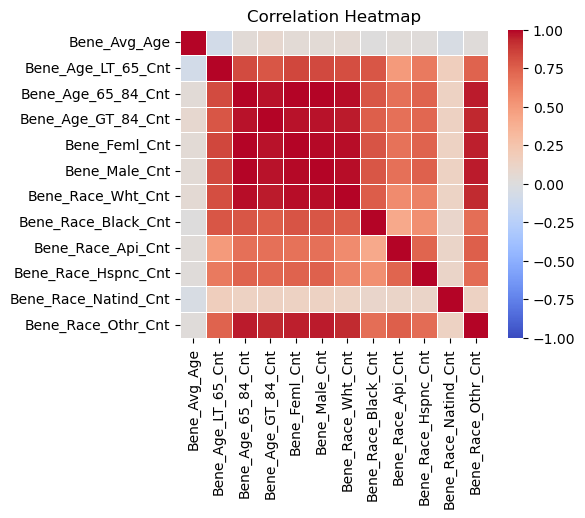

In [263]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    bene_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [264]:
# Running the Principal Component Reduction.

bene_pca = PCA(n_components = 6)
bene_pca_c = bene_pca.fit_transform(X_bene)

In [265]:
# Looking at the variability explained by each component in bene.

bene_pca.explained_variance_ratio_
bene_ex_vratio = np.cumsum(bene_pca.explained_variance_ratio_)
bene_ex_vratio

array([0.98014311, 0.99414174, 0.99600039, 0.99746714, 0.99850863,
       0.99935699])

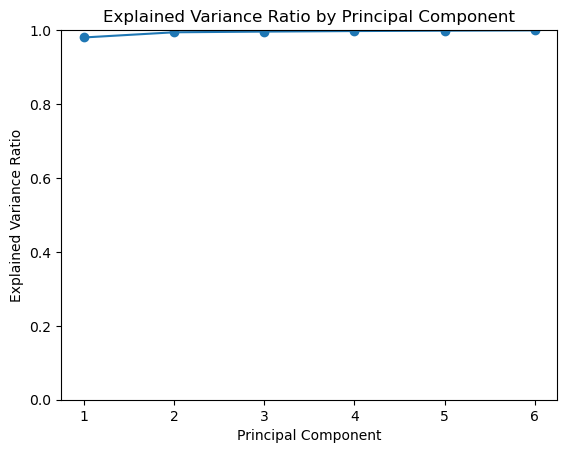

In [266]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(bene_ex_vratio) + 1)
y = bene_ex_vratio
# plot
ax.plot(x, y, marker='o')
ax.set_ylim(0, 1)
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [267]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

bene_comps = bene_pca.components_

bene_comps_df = pd.DataFrame(
    bene_comps,
    columns=X_bene.columns,
    index=[f'PC{i+1}' for i in range(bene_comps.shape[0])]
)

print(bene_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     Bene_Avg_Age  Bene_Age_LT_65_Cnt  Bene_Age_65_84_Cnt  Bene_Age_GT_84_Cnt  \
PC1      0.000209            0.034379            0.641165            0.063054   
PC2      0.001463           -0.015139           -0.283947           -0.025485   
PC3      0.004913           -0.275212            0.135689            0.068285   
PC4     -0.011272            0.074952            0.212529           -0.016634   
PC5      0.006859            0.089068           -0.329860            0.004301   
PC6      0.007400            0.338566           -0.530608            0.067099   

     Bene_Feml_Cnt  Bene_Male_Cnt  Bene_Race_Wht_Cnt  Bene_Race_Black_Cnt  \
PC1       0.419291       0.319079           0.543503             0.044221   
PC2      -0.150678      -0.137768           0.649074            -0.019529   
PC3      -0.233797       0.143210          -0.020161            -0.496900   
PC4       0.195982      -0.148309          -0.306005             0.634207   
PC5       0.710562      -0.465100           0.0

In [268]:
# From the ratio plot, the top variable explains 98% of the variance in the data.
# From the table above, Bene_Age_65_84_Cnt (PC1 value = 0.64) would be that variable.
# However, given that this analysis chunk is made up of essentially mostly non-overlapping variables (except for Bene_Avg_Age).
# Therefore, all variables, except for Bene_Avg_Age, will be used in the cluster.

In [276]:
# Standardizing numeric data to zscore.

bene_num = bene[['Bene_Age_LT_65_Cnt', 'Bene_Age_65_84_Cnt', 'Bene_Age_GT_84_Cnt', 'Bene_Feml_Cnt', 'Bene_Male_Cnt', 'Bene_Race_Wht_Cnt', 'Bene_Race_Black_Cnt', 'Bene_Race_Api_Cnt', 'Bene_Race_Hspnc_Cnt', 'Bene_Race_Natind_Cnt', 'Bene_Race_Othr_Cnt', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
bene_numz = pd.DataFrame(stats.zscore(bene_num, nan_policy = 'omit'), columns = bene_num.columns)
bene_numz.head()

,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.152576,-0.041363,0.121047,-0.055931,-0.047622,-0.063351,-0.059389,0.015443,-0.074061,-0.511540,0.009702,-0.380841,-0.229684,-0.541352,-0.120023
1,3.099445,0.206571,0.000557,0.402664,0.242206,0.154184,2.645732,0.002945,0.038303,1.119321,0.085718,1.533079,2.626959,-0.383958,10.427882
2,-0.266018,-0.121577,-0.119933,-0.117201,-0.096333,-0.090365,-0.295220,-0.122042,-0.144289,1.119321,0.009702,-0.219292,-0.335408,-0.010036,-0.120023
3,-0.266018,-0.121577,-0.119933,-0.156191,-0.140172,-0.083256,-0.156496,0.002945,-0.074061,-0.511540,0.009702,-0.731856,-0.335408,-0.541352,-0.120023
4,-0.266018,-0.121577,-0.119933,-0.146908,-0.137737,-0.140128,-0.156496,-0.122042,-0.074061,-0.511540,0.009702,1.012835,-0.087489,-0.541352,-0.120023


In [277]:
# Comparing against mean values and standard deviations in each column in bene_num.

print(bene_num.describe())

       Bene_Age_LT_65_Cnt  Bene_Age_65_84_Cnt  Bene_Age_GT_84_Cnt  \
count        1.048575e+06        1.048575e+06        1.048575e+06   
mean         2.406977e+01        1.000338e+02        1.995376e+01   
std          5.289022e+01        8.227991e+02        8.299472e+01   
min          0.000000e+00        0.000000e+00        0.000000e+00   
25%          1.000000e+01        0.000000e+00        1.000000e+01   
50%          1.000000e+01        1.100000e+01        1.000000e+01   
75%          2.600000e+01        1.270000e+02        1.500000e+01   
max          2.158900e+04        4.286940e+05        4.399300e+04   

       Bene_Feml_Cnt  Bene_Male_Cnt  Bene_Race_Wht_Cnt  Bene_Race_Black_Cnt  \
count   1.048575e+06   1.048575e+06       1.048575e+06         1.048575e+06   
mean    9.412475e+01   6.755301e+01       1.175572e+02         2.128110e+01   
std     5.386015e+02   4.105886e+02       7.033364e+02         7.208553e+01   
min     0.000000e+00   0.000000e+00       0.000000e+00        

In [278]:
# The bene-num data frame serves as the final data set because this subset does not include categorical data.

bene_f = bene_numz.copy()
bene_f.head()

,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.152576,-0.041363,0.121047,-0.055931,-0.047622,-0.063351,-0.059389,0.015443,-0.074061,-0.511540,0.009702,-0.380841,-0.229684,-0.541352,-0.120023
1,3.099445,0.206571,0.000557,0.402664,0.242206,0.154184,2.645732,0.002945,0.038303,1.119321,0.085718,1.533079,2.626959,-0.383958,10.427882
2,-0.266018,-0.121577,-0.119933,-0.117201,-0.096333,-0.090365,-0.295220,-0.122042,-0.144289,1.119321,0.009702,-0.219292,-0.335408,-0.010036,-0.120023
3,-0.266018,-0.121577,-0.119933,-0.156191,-0.140172,-0.083256,-0.156496,0.002945,-0.074061,-0.511540,0.009702,-0.731856,-0.335408,-0.541352,-0.120023
4,-0.266018,-0.121577,-0.119933,-0.146908,-0.137737,-0.140128,-0.156496,-0.122042,-0.074061,-0.511540,0.009702,1.012835,-0.087489,-0.541352,-0.120023


In [279]:
# Check for null values per column.

print(bene_f.isnull().sum())

Bene_Age_LT_65_Cnt             0
Bene_Age_65_84_Cnt             0
Bene_Age_GT_84_Cnt             0
Bene_Feml_Cnt                  0
Bene_Male_Cnt                  0
Bene_Race_Wht_Cnt              0
Bene_Race_Black_Cnt            0
Bene_Race_Api_Cnt              0
Bene_Race_Hspnc_Cnt            0
Bene_Race_Natind_Cnt           0
Bene_Race_Othr_Cnt             0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [280]:
# Create a sample set of prdemo (10% of data) for model optimization purposes.

bene_f_10 = bene_f.sample(frac = 0.01, random_state = 0)
bene_f_10.describe()

,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
count,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000,10486.000000
mean,0.006896,0.005339,0.000805,0.005796,0.004722,0.006352,0.015247,0.002448,-0.004530,-0.006822,0.001718,0.013704,0.019750,0.001452,0.024744
std,1.643413,1.302025,1.063469,1.342435,1.262896,1.493145,1.884856,0.529268,0.447809,1.003754,0.796729,1.007562,0.986321,1.001079,1.096403
min,-0.455089,-0.121577,-0.240422,-0.174758,-0.164527,-0.167142,-0.295220,-0.122042,-0.144289,-0.511540,-0.243684,-0.731856,-0.335408,-0.541352,-0.120023
25%,-0.266018,-0.121577,-0.119933,-0.156191,-0.140172,-0.147237,-0.156496,-0.122042,-0.074061,-0.511540,0.009702,-0.731856,-0.335408,-0.541352,-0.120023
50%,-0.266018,-0.121577,-0.119933,-0.096778,-0.093897,-0.101740,-0.156496,0.002945,-0.074061,-0.511540,0.009702,-0.459548,-0.335408,-0.541352,-0.120023
75%,0.017588,0.026697,-0.071737,0.044328,0.020573,0.026222,-0.087134,0.002945,-0.074061,1.119321,0.009702,0.310948,-0.185947,-0.066387,-0.120023
max,156.643984,130.948150,102.958964,134.860196,126.453773,150.091036,182.806801,39.248734,13.950418,34.225795,78.990269,2.292274,17.270526,2.593414,26.258354


In [281]:
# Remove opioid data from bene_f.

bene_fo_10 = bene_f_10[['Bene_Age_LT_65_Cnt', 'Bene_Age_65_84_Cnt', 'Bene_Age_GT_84_Cnt', 'Bene_Feml_Cnt', 'Bene_Male_Cnt', 'Bene_Race_Wht_Cnt', 'Bene_Race_Black_Cnt', 'Bene_Race_Api_Cnt', 'Bene_Race_Hspnc_Cnt', 'Bene_Race_Natind_Cnt', 'Bene_Race_Othr_Cnt']]
bene_fo_10.head()

,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt
875680,-0.266018,-0.121577,-0.119933,-0.156191,-0.140172,-0.152924,-0.156496,0.002945,-0.074061,1.119321,0.009702
1046906,-0.266018,0.074096,-0.119933,0.048042,0.020573,0.104421,-0.156496,-0.122042,-0.074061,-0.511540,-0.243684
646861,-0.455089,-0.121577,-0.240422,-0.156191,-0.140172,-0.152924,-0.295220,0.002945,-0.074061,-0.511540,0.009702
704385,0.452451,-0.083901,-0.119933,-0.013228,-0.164527,-0.093209,0.120952,-0.122042,-0.074061,-0.511540,0.009702
798051,-0.266018,0.126357,-0.119933,0.150158,-0.025702,0.075985,-0.031644,0.102934,-0.031925,1.119321,0.009702


In [282]:
# Convert the data frame to a matrix.

bene_fmat = bene_fo_10.to_numpy()

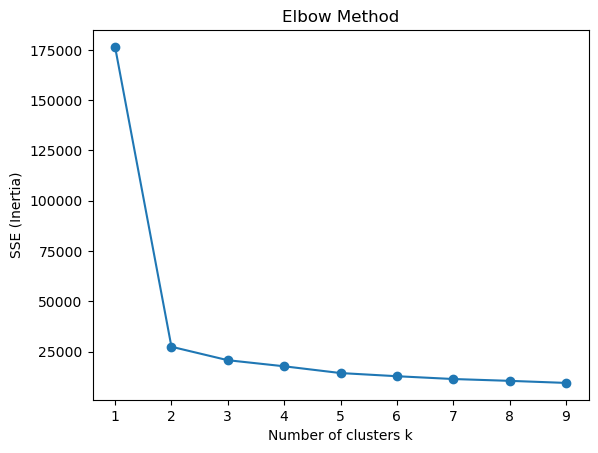

In [285]:
# Using a k-means model to determine number of clusters. Originally tried using kprotoype, but it returned an error because the matrix did not contain categorical data.
# The error suggested using k-means instead.

distortions = []
inertias = []
K = range(1, 10)

for k in K:
    kmeans_bene = KMeans(n_clusters=k, random_state=42).fit(bene_fmat)
    
    distortions.append(sum(np.min(cdist(bene_fmat, kmeans_bene.cluster_centers_, 'euclidean'), axis=1)**2) / bene_fmat.shape[0])
    
    inertias.append(kmeans_bene.inertia_)

# Plot
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

#Elbow Method for optimal value of k in KMeans. (2019, June 6). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

In [293]:
#Run k-means using 1 cluster as determined from the elbow plot above.

kmeans_bene = KMeans(n_clusters=1, random_state=42).fit(bene_fmat)

In [297]:
# Cluster centorid

kmeans_bene.cluster_centers_

array([[ 0.00689578,  0.00533863,  0.00080534,  0.00579554,  0.00472244,
         0.00635221,  0.01524741,  0.00244762, -0.00453021, -0.00682243,
         0.00171812]])

In [298]:
# Check the iteration of the clusters created

kmeans_bene.n_iter_

2

In [299]:
# Check the cost of the clusters created

kmeans_bene.inertia_

176454.16136276073

In [302]:
# Add the clusters to the prdemo_f_10 dataframe.

bene_f_10['Cluster Labels'] = kmeans_bene.labels_
bene_f_10['Segment'] = bene_f_10['Cluster Labels'].map({0: 'Cluster 1'})

# Order the cluster
bene_f_10['Segment'] = bene_f_10['Segment'].astype('category')
bene_f_10['Segment'] = bene_f_10['Segment'].cat.reorder_categories(['Cluster 1'])

bene_f_10.head(10)

,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Total,Segment,Total,Cluster Labels
875680,-0.266018,-0.121577,-0.119933,-0.156191,-0.140172,-0.152924,-0.156496,0.002945,-0.074061,1.119321,0.009702,2.292274,-0.335408,2.593414,-0.120023,0,Cluster 1,0,0
1046906,-0.266018,0.074096,-0.119933,0.048042,0.020573,0.104421,-0.156496,-0.122042,-0.074061,-0.511540,-0.243684,-0.330696,0.100450,-0.381415,-0.120023,0,Cluster 1,0,0
646861,-0.455089,-0.121577,-0.240422,-0.156191,-0.140172,-0.152924,-0.295220,0.002945,-0.074061,-0.511540,0.009702,-0.731856,-0.335408,-0.541352,-0.120023,0,Cluster 1,0,0
704385,0.452451,-0.083901,-0.119933,-0.013228,-0.164527,-0.093209,0.120952,-0.122042,-0.074061,-0.511540,0.009702,-0.731856,-0.335408,-0.541352,-0.120023,0,Cluster 1,0,0
798051,-0.266018,0.126357,-0.119933,0.150158,-0.025702,0.075985,-0.031644,0.102934,-0.031925,1.119321,0.009702,-0.601506,-0.335408,-0.406233,-0.120023,0,Cluster 1,0,0
800217,-0.266018,-0.121577,-0.119933,-0.156191,-0.140172,-0.151502,-0.295220,-0.122042,-0.144289,-0.511540,-0.243684,-0.731856,-0.335408,-0.541352,-0.120023,0,Cluster 1,0,0
267711,-0.152576,-0.104562,-0.119933,-0.137625,-0.096333,-0.133019,-0.059389,0.002945,-0.074061,-0.511540,0.009702,-0.731856,-0.335408,-0.541352,-0.120023,0,Cluster 1,0,0
363947,-0.001319,0.020620,0.000557,-0.003945,0.003524,0.019113,-0.073262,0.002945,-0.074061,1.119321,0.009702,-0.243487,-0.271053,-0.346646,-0.120023,0,Cluster 1,0,0
1018796,-0.266018,-0.049871,-0.119933,-0.070785,-0.071977,-0.042024,-0.156496,-0.122042,-0.144289,-0.511540,0.009702,-0.410140,-0.335408,-0.207866,-0.120023,0,Cluster 1,0,0
980271,-0.266018,-0.121577,-0.119933,-0.139481,-0.113381,-0.152924,-0.295220,0.340408,-0.074061,-0.511540,-0.243684,0.024177,-0.335408,0.242340,-0.120023,0,Cluster 1,0,0


In [303]:
# Cluster interpretation

bene_f_10.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
bene_f_10.groupby('Segment').agg(
    {
        'Total': 'count',
        'Bene_Age_LT_65_Cnt': 'mean',
        'Bene_Age_65_84_Cnt': 'mean',
        'Bene_Age_GT_84_Cnt': 'mean',
        'Bene_Feml_Cnt': 'mean',
        'Bene_Male_Cnt': 'mean',
        'Bene_Race_Wht_Cnt': 'mean',
        'Bene_Race_Black_Cnt': 'mean',
        'Bene_Race_Api_Cnt': 'mean',
        'Bene_Race_Hspnc_Cnt': 'mean',
        'Bene_Race_Natind_Cnt': 'mean',
        'Bene_Race_Othr_Cnt': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

,Segment,Total,Total,Total,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,10486,10486,10486,0.006896,0.005339,0.000805,0.005796,0.004722,0.006352,0.015247,0.002448,-0.00453,-0.006822,0.001718,0.013704,0.01975,0.001452,0.024744


In [ ]:
# These large disparaties in the cluster sizes may be due to an imbalance in the classes.
# Therefore, future improvements would be a deeper dive into the data distributions to make sure that each class is evenly represented.